# test-resample-paper.ipynb

Validation notebook for the J-STARS paper:

**healpix-resample: a PSF-Aware HEALPix Resampling for Earth Observation Imagery**

This notebook extends `test-resample_with_esri_sampler.ipynb` by adding **classical resampling baselines** (nearest-neighbor, bilinear, bicubic) for direct comparison with the PSF-aware method in:
- **Table I** – Synthetic detector experiment (HEALPix-domain metrics)
- **Table II** – Real Sentinel-2 round-trip metrics (UTM → HEALPix → UTM)


In [1]:
# PAPER_DATA_OFFLINE_GUARD
# Cache-first: with OFFLINE = False (the default) the acquisition cells
# fetch ONLY the missing Esri-derived stores, from the pinned immutable
# Wayback release (paper_data_guard.WAYBACK_RELEASE) -- the one network
# step of a fresh install; nothing is fetched again once the caches match.
# Everything else comes from the frozen Zenodo bundle
# (run load_data_in_zenodo.ipynb once). Set OFFLINE = False to enforce
# strictly network-free reruns after the first pass.
OFFLINE = True
try:
    from paper_data_guard import require_paper_data, zarr_v2_kwargs, open_zarr_group_w_v2
except ModuleNotFoundError:
    from notebooks.paper_data_guard import require_paper_data, zarr_v2_kwargs, open_zarr_group_w_v2

REPO_ROOT = require_paper_data("test-resample-paper.ipynb")


[offline data] test-resample-paper.ipynb: 3 Esri-derived input(s) absent -- expected on a fresh install, since they are not redistributed (Esri terms). This notebook's acquisition cells will regenerate them from the pinned World Imagery Wayback release 26334 (2026-08-05): with the default OFFLINE = False, simply run the notebook top to bottom (network required once; the fetch is cache-first and touches only missing stores). Set OFFLINE = True afterwards to enforce strictly network-free reruns.
  - notebooks/data/esri_latent/water__z17_n256_os4.zarr
  - notebooks/data/esri_latent/forest__z17_n256_os4.zarr
  - notebooks/data/esri_latent/agriculture__z17_n256_os4.zarr
[offline data] test-resample-paper.ipynb: required frozen inputs are available


## 0. Installation notes

Run only if packages are missing.

In [2]:
# Optional installation cell
#!pip install -U numpy pandas scipy scikit-image matplotlib xarray zarr pyproj pystac-client xarray-eopf healpix-resample healpix-geo


## 1. Imports and configuration

In [3]:
from pathlib import Path
import os
import time
import json
import warnings
import shutil
import zarr

# Strict publication mode: never contact STAC, mirrors, or Esri.
OFFLINE = True

import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import xarray as xr
import pyproj
import pystac_client

from scipy import ndimage
from scipy.ndimage import gaussian_filter
from scipy.interpolate import RegularGridInterpolator, griddata
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from skimage.metrics import structural_similarity as ssim
from skimage import exposure

try:
    from healpix_resample import PSFResampler
except Exception as exc:
    PSFResampler = None
    warnings.warn(f"Could not import PSFResampler: {exc}")

try:
    # fwhm_to_scale()/recommend_npt() fix the two bugs found in the paper review
    # (see planning notes / Thomas Davison's review + effective_kernel_geometry.ipynb):
    #   (1) sigma_m was being fed an intended FWHM directly, with no conversion to
    #       the scale `s` the kernel w(d)=exp(-2 d^2/s^2) actually expects
    #       (s = FWHM / sqrt(2 ln 2), NOT FWHM itself -- see psf_geometry.py).
    #   (2) Npt was fixed at 9 regardless of kernel width, which silently
    #       truncates any kernel much wider than about one cell. At the old
    #       (buggy) scale=12.6 this kept only 75% of the kernel's mass at
    #       Npt=9; the +50% mismatch arm kept under 50%.
    from healpix_resample import fwhm_to_scale, scale_to_fwhm, recommend_npt
except Exception as exc:
    fwhm_to_scale = scale_to_fwhm = recommend_npt = None
    warnings.warn(f"Could not import fwhm_to_scale/recommend_npt: {exc}")

from paper_data_guard import sph_ang2pix, sph_pix2ang  # healpy removed: healpix-geo shims, bit-identical (sphere convention)

DATA_DIR   = Path("data")
# Patches for the paper's scenes, mirrored so they stay addressable.
# Virtual-hosted-style URL: OVH rejects path-style for anonymous requests, and
# bucket listing is not public, so read specific objects over plain HTTPS using
# the consolidated metadata. No credentials required.
MIRROR_BASE = ("https://grid4earth.s3.gra.io.cloud.ovh.net"
               "/public/eopf-mirror/sentinel-2-l2a/patches")
FIG_DIR    = Path("figures")
TABLE_DIR  = Path("tables")
for d in [DATA_DIR, FIG_DIR, TABLE_DIR]:
    d.mkdir(exist_ok=True)

RANDOM_SEED  = 1234
np.random.seed(RANDOM_SEED)

# ── Paper default parameters ─────────────────────────────────────────────────
HEALPIX_LEVEL = 20
PATCH_SIZE    = 256
CENTRAL_SIZE  = PATCH_SIZE
BAND          = "b04"      # Sentinel-2 red band
LAMBDA        = 0.001
MAX_ITER      = 14
THRESHOLD     = 0.1
FWHM          = 12.5       # metres -- revised target (was 12.6; see review notes:
                           # the FWHM this is meant to represent was always ~12.5 m,
                           # but a factor-of-2-type bug in the FWHM<->scale
                           # conversion made it read back as 5.31 m in the
                           # manuscript text). This is the physical FWHM of the
                           # assumed response -- it is NOT what gets passed
                           # straight to PSFResampler any more; see
                           # npt_for_fwhm()/fwhm_to_scale() below.
DEVICE        = 'cuda:0' if torch.cuda.is_available() else 'cpu'   # fall back so the notebook runs without a GPU
# Classical resampling methods to benchmark
CLASSICAL_METHODS = ["nearest", "linear", "cubic"]


def npt_for_fwhm(fwhm_m, level=HEALPIX_LEVEL, target_mass=0.99):
    """Scale + neighbour-count to actually use for a PSFResampler call meant
    to deliver a given intended FWHM (metres).

    Returns (scale_m, npt): pass `scale_m` as `sigma_m=` and `npt` as `Npt=`
    to PSFResampler. Both matter -- passing the right scale but leaving
    Npt=9 still truncates any kernel wider than about one cell width (see
    the module-level comment above, and
    healpix_resample.diagnostics.kernel_geometry for the lattice-exact
    version of this same calculation, worth cross-checking once you can
    run it).
    """
    scale_m = fwhm_to_scale(fwhm_m)
    npt = recommend_npt(scale_m, level, target_mass=target_mass)["npt"]
    return scale_m, npt


# ── PSF-mismatch sensitivity test (paper Table I, extra columns) ────────────
# Operator PSF deliberately mis-specified relative to the true generation FWHM,
# to test robustness when the assumed spatial response does not exactly match
# reality.
FWHM_PSF_AWARE_WIDE     = FWHM * 1.5
FWHM_PSF_AWARE_NARROW   = FWHM * 0.5
# Table I uses one common damping value for the matched and both PSF-width
# mismatch arms. This keeps the sensitivity comparison attributable to the
# assumed response width rather than to arm-specific regularization.
LAMBDA_PSF_AWARE_NARROW = 0.001
LAMBDA_PSF_AWARE_WIDE   = 0.001
RICHARDSON_LUCY_ITER    = 100
# RL previously resampled its deconvolved UTM image to HEALPix cell centres
# with a single bilinear point sample -- a different (and smoother) estimand
# than every other method in Table I, which are all effectively cell averages
# (see 17.5, compare_point_vs_cell_average_estimand, and the review discussion
# of point vs. cell-average estimands). RL now instead upsamples the
# deconvolved image to an ~RL_REBIN_GSD_M grid (bicubic) and averages the
# HEALPix children falling in each cell, exactly like
# build_synthetic_detector_products does for the ESRI ground truth -- so RL
# is scored on the same footing as everything else. See cell 42.
RL_REBIN_GSD_M          = 5.0   # metres; assumes ~10 m Sentinel-2 GSD -> 2x2 children/cell

try:
    from skimage.restoration import richardson_lucy
except Exception as exc:
    richardson_lucy = None
    warnings.warn(f"Could not import richardson_lucy: {exc}")


def _crs_of(obj):
    """CRS of an EOPF product or a cached patch.

    `obj.crs_code` is not provided by xarray-eopf 0.3.0, and the metadata key
    is `horizontal_CRS_code` (capital CRS), not `horizontal_crs_code`. The CF
    grid-mapping coordinate is the stable place to look, so prefer it.
    """
    try:
        return pyproj.CRS.from_wkt(obj.spatial_ref.attrs["crs_wkt"])
    except Exception:
        try:
            meta = getattr(obj, "attrs", {}).get("other_metadata", {})
            return pyproj.CRS.from_user_input(meta["horizontal_CRS_code"])
        except Exception:
            meta = getattr(obj, "attrs", {}).get("other_metadata", {})
            return pyproj.CRS.from_user_input(meta["horizontal_crs_code"])


## 2. Benchmark scenes

## Where the Sentinel-2 data comes from

The four scenes are read from patches mirrored in the GRID4EARTH bucket, pinned
by product id, and served publicly over HTTPS:

    https://grid4earth.s3.gra.io.cloud.ovh.net/public/eopf-mirror/sentinel-2-l2a/patches/

| scene | product | cloud |
|---|---|---|
| urban (Paris) | `S2B_MSIL2A_20260527T105619_N0512_R094_T31UDQ_20260527T133135` | 0.003% |
| water (Lake Geneva) | `S2C_MSIL2A_20260622T102601_N0512_R108_T31TGM_20260622T154112` | 2.27% |
| forest (Black Forest) | `S2A_MSIL2A_20260704T102701_N0512_R108_T32UMU_20260704T170718` | 0.008% |
| agriculture (Beauce) | `S2B_MSIL2A_20260623T104619_N0512_R051_T31UCP_20260623T132606` | 0.80% |

All four are Sentinel-2 **L2A**, produced by **EOPF-CPM 2.7.0** at **ESA**,
processing baseline **05.12**, systematic lineage, MSI at 10 m ground sampling
distance. Each mirrored store repeats this in its attributes
(`processing_software`, `processing_version`, `processing_facility`,
`processing_level`, `source_item_id`), so a patch remains self-describing if it
is copied elsewhere.

**Why a mirror rather than a live catalogue search.** The notebook used to search
the EOPF STAC by bounding box, date range and cloud threshold, then take the
first result. That is not reproducible: several products typically match, the
catalogue's holdings change, and items are marked deprecated over time. Three of
these four scenes stopped resolving on that endpoint entirely. Pinning by product
id against a mirrored copy makes the inputs fixed.

Each patch contains only what this notebook uses: the `b04` band at 10 m, cropped
to 256x256 around the scene coordinates, plus latitude/longitude and the CRS --
roughly 1 MB per scene. It is not a full product mirror.

To recreate or extend the mirror, see `notebooks/mirror_patches.py` (needs write
access to the bucket). Setting a scene's `product_id` to `None` falls back to the
live STAC search, which reports whichever product it selected.


In [4]:
benchmark_coordinates = {
    "urban": {
        "location": "Paris, France",
        "wgs84": {"lat": 48.8566, "lon": 2.3522},
        "recommended_date": "2026-05-01/2026-05-30",
        # Pinned: this exact product is mirrored in the GRID4EARTH
        # bucket, so the scene cannot drift when the catalogue changes.
        "product_id": "S2B_MSIL2A_20260527T105619_N0512_R094_T31UDQ_20260527T133135",
        "cloud": 20,
    },
    "water": {
        "location": "Lake Geneva, Switzerland",
        "wgs84": {"lat": 46.4983, "lon": 6.6327},
        "recommended_date": "2026-06-01/2026-06-24",
        # Pinned: this exact product is mirrored in the GRID4EARTH
        # bucket, so the scene cannot drift when the catalogue changes.
        "product_id": "S2A_MSIL2A_20260624T103041_N0512_R108_T32TLS_20260624T182910",
        "cloud": 20,
    },
    "forest": {
        "location": "Black Forest, Germany",
        "wgs84": {"lat": 48.265, "lon": 8.016},
        "recommended_date": "2026-07-01/2026-07-31",
        # Pinned: this exact product is mirrored in the GRID4EARTH
        # bucket, so the scene cannot drift when the catalogue changes.
        "product_id": "S2A_MSIL2A_20260704T102701_N0512_R108_T32UMU_20260704T170718",
        "cloud": 20,
    },
    "agriculture": {
        "location": "Beauce plains, France",
        "wgs84": {"lat": 48.258, "lon": 1.499},
        "recommended_date": "2026-06-01/2026-06-30",
        # Pinned: this exact product is mirrored in the GRID4EARTH
        # bucket, so the scene cannot drift when the catalogue changes.
        "product_id": "S2B_MSIL2A_20260623T104619_N0512_R051_T31UCP_20260623T132606",
        "cloud": 20,
    },
}


## 3. Sentinel-2 extraction utilities

In [5]:


def _add_latlon(ds, transformer):
    xx, yy = np.meshgrid(ds.x.values, ds.y.values)
    lon, lat = transformer.transform(xx, yy)
    ds = ds.assign_coords(longitude=(["y", "x"], lon), latitude=(["y", "x"], lat))
    return ds

def extract_bench_data(scene, patch_size=PATCH_SIZE, force=False, coords=None,band=None):
    """
    `coords` defaults to benchmark_coordinates[scene]. Pass it explicitly to
    fetch a one-off location that isn't part of the main 4-scene benchmark
    suite without
    registering it in benchmark_coordinates -- keeps it out of Table I and
    every other cell that loops over benchmark_coordinates.
    """
    if band is None:
        band=BAND
        
    xr.set_options(keep_attrs=True, display_expand_attrs=False)
    path = DATA_DIR / f"{scene}_data.zarr"
    # OFFLINE takes precedence over force: an existing frozen input is never refreshed.
    if path.exists() and (OFFLINE or not force):
        # Report which product this cache came from, so a run that reuses the
        # cache still says what data it is using.
        try:
            import zarr as _zarr
            _a = _zarr.open_group(str(path), mode="r").attrs.asdict()
            if _a.get("source_item_id"):
                print(f"[{scene}] cached  <- {_a['source_item_id']}"
                      f"  ({_a.get('source_datetime', '?')},"
                      f" cloud {_a.get('source_cloud_cover', '?')}%)")
            else:
                print(f"[{scene}] cached  <- provenance not recorded "
                      f"(cache predates source_item_id; delete it to refresh)")
        except Exception as _exc:
            print(f"[{scene}] cached  <- could not read provenance: {_exc}")
        return
    if OFFLINE:
        raise FileNotFoundError(
            f"Missing frozen Sentinel-2 input: {path}. Download the DOI data "
            "archive and place its data/ directory under notebooks/."
        )
    catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")
    coords = benchmark_coordinates[scene] if coords is None else coords
    lat0, lon0 = coords["wgs84"]["lat"], coords["wgs84"]["lon"]

    # Prefer the patch mirrored in the GRID4EARTH bucket. The EOPF STAC is a
    # curated view whose holdings change -- three of these four scenes stopped
    # resolving there entirely -- so a pinned, mirrored copy is what makes this
    # notebook reproducible. Falls back to the live search when unpinned.
    pinned = coords.get("product_id")
    if pinned:
        try:
            import fsspec
            _ds = xr.open_zarr(
                fsspec.get_mapper(f"{MIRROR_BASE}/{pinned}.zarr"), consolidated=True
            )
            _ds.to_zarr(path, mode="w", **zarr_v2_kwargs())
            print(f"[{scene}] mirror  <- {pinned}"
                  f"  (cloud {_ds.attrs.get('source_cloud_cover', '?')}%)")
            return
        except Exception as exc:
            print(f"[{scene}] mirror unavailable ({type(exc).__name__}), "
                  f"falling back to the STAC search: {str(exc)[:70]}")

    items = list(catalog.search(
        collections=["sentinel-2-l2a"],
        bbox=[lon0 - 0.05, lat0 - 0.05, lon0 + 0.05, lat0 + 0.05],
        datetime=coords["recommended_date"],
        query={"eo:cloud_cover": {"lt": coords["cloud"]}},
    ).get_all_items())
    if not items:
        raise RuntimeError(f"No items for {scene}")
    item = items[0]
    
    # The search is by bbox + date range + cloud threshold, so several products
    # can match and items[0] depends on catalogue ordering. Record which one was
    # actually used -- otherwise the identity of the scene behind every number
    # in this notebook exists only in whoever's data/ directory produced it.
    _props = item.properties
    print(f"[{scene}] {len(items)} product(s) matched; using {item.id}"
          f"  ({_props.get('datetime', '?')},"
          f" cloud {_props.get('eo:cloud_cover', '?')}%)")
    if len(items) > 1:
        print(f"[{scene}]   others: {', '.join(i.id for i in items[1:4])}"
              f"{' ...' if len(items) > 4 else ''}")
    # item.assets[BAND] (BAND="b04") doesn't exist in this catalog -- assets
    # are keyed like "B04_10m", and *that* href points straight at a single
    # band's leaf Zarr array (.../measurements/reflectance/r10m/b04), which
    # the eopf-zarr backend can't open with engine="eopf-zarr" (it walks
    # root.groups(), expects a *group*, not a leaf array -- "'Array' object
    # has no attribute 'groups'"). "SR_10m" is the group one level up
    # (.../measurements/reflectance/r10m), containing b02/b03/b04/b08 as
    # siblings -- a real navigable group, so this opens cleanly. The extra
    # bands beyond BAND ("b04") just ride along into the cached local zarr
    # unused; load_scene_patch() already selects dt[BAND] on read.
    ds = xr.open_dataset(
        item.assets["product"].href,
        engine="eopf-zarr",
        resolution=10,
        variables=[band],
        chunks={},
    )
    
    # The CRS lives in the CF grid-mapping coordinate. `ds.crs_code` does not
    # exist, and the old fallback looked up 'horizontal_crs_code' where the key
    # is actually 'horizontal_CRS_code' -- so both branches raised and the bare
    # `except:` hid why, leaving every scene unfetchable.
    try:
        src_crs = pyproj.CRS.from_wkt(ds.spatial_ref.attrs["crs_wkt"])
    except Exception:
        try:
            src_crs = pyproj.CRS.from_user_input(
                ds.attrs["other_metadata"]["horizontal_CRS_code"]
            )
        except Exception:
            src_crs = pyproj.CRS.from_user_input(
                ds.attrs["other_metadata"]["horizontal_crs_code"]
            )
    transformer = pyproj.Transformer.from_crs(
        src_crs, pyproj.CRS.from_epsg(4326), always_xy=True
    )
        
    # Centre the patch on the coordinates that were searched for, not on the
    # centre of the whole ~110 km MGRS tile. The tile centre can be tens of km
    # away -- for urban it lands at 49.157N, 33.5 km north of the Paris
    # coordinates this scene is defined by -- so the patch was not the scene
    # the notebook says it is. The committed tables correspond to
    # coordinate-centred patches.
    _fwd = pyproj.Transformer.from_crs(
        pyproj.CRS.from_epsg(4326), _crs_of(ds), always_xy=True
    )
    x_c, y_c = _fwd.transform(lon0, lat0)
    half = patch_size // 2 * 10
    ds_patch = ds.sel(
        x=slice(x_c - half, x_c + half),
        y=slice(y_c + half, y_c - half),
    )
    ds_patch = _add_latlon(ds_patch, transformer)
    # Travel the provenance with the cache, so it survives being copied around.
    ds_patch.attrs["source_item_id"] = item.id
    ds_patch.attrs["source_collection"] = "sentinel-2-l2a"
    ds_patch.attrs["source_stac_endpoint"] = "https://stac.core.eopf.eodc.eu"
    ds_patch.attrs["source_datetime"] = str(_props.get("datetime", ""))
    ds_patch.attrs["source_cloud_cover"] = str(_props.get("eo:cloud_cover", ""))
    ds_patch.to_zarr(path, mode="w", **zarr_v2_kwargs())


## 4. Download or load scenes

In [6]:
FORCE_DOWNLOAD = False
for scene in benchmark_coordinates:
    try:
        extract_bench_data(scene, force=FORCE_DOWNLOAD)
        print(f"[OK] {scene}")
    except Exception as exc:
        print(f"[WARN] {scene}: {exc}")


[urban] cached  <- S2B_MSIL2A_20260527T105619_N0512_R094_T31UDQ_20260527T133135  (2026-05-27T10:56:19.024000Z, cloud 0.00289%)
[OK] urban
[water] cached  <- S2A_MSIL2A_20260624T103041_N0512_R108_T32TLS_20260624T182910  (2026-06-24T10:30:41.024000Z, cloud 2.696484%)
[OK] water
[forest] cached  <- S2A_MSIL2A_20260724T102701_N0512_R108_T32UMU_20260724T171410  (2026-07-24T10:27:01.024000Z, cloud 0.078397%)
[OK] forest
[agriculture] cached  <- S2A_MSIL2A_20260623T105711_N0512_R094_T31UCP_20260623T173411  (2026-06-23T10:57:11.024000Z, cloud 1.064157%)
[OK] agriculture


## 5. Common utilities

In [7]:
def central_crop(img, size=CENTRAL_SIZE):
    ny, nx = img.shape
    cy, cx = ny // 2, nx // 2
    h = size // 2
    return img[cy - h:cy + h, cx - h:cx + h]

def fill_nan_with_mean(img):
    img = np.asarray(img, dtype=np.float32).copy()
    mask = np.isfinite(img)
    if not mask.any():
        raise ValueError("Image contains no finite pixels.")
    img[~mask] = np.nanmean(img)
    return img

def load_scene_patch(scene_name):
    path = DATA_DIR / f"{scene_name}_data.zarr"
    dt = xr.open_datatree(path, engine="zarr", consolidated=False, chunks={})
    da = dt[BAND]
    img = fill_nan_with_mean(da.values)
    lon = da["longitude"].values.astype(np.float64)
    lat = da["latitude"].values.astype(np.float64)
    return img, lon, lat, da

def normalize01(x):
    x = np.asarray(x, dtype=np.float64)
    p1, p99 = np.nanpercentile(x, [1, 99])
    if p99 <= p1:
        return np.zeros_like(x)
    return np.clip((x - p1) / (p99 - p1), 0, 1)

def get_utm_axes(da, central_size=CENTRAL_SIZE):
    """Return 1-D UTM x and y axes for the central crop of a DataArray."""
    x_full = da.x.values
    y_full = da.y.values
    nx, ny = x_full.size, y_full.size
    cx, cy = nx // 2, ny // 2
    h = central_size // 2
    x0 = x_full[cx - h:cx + h]
    y0 = y_full[cy - h:cy + h]
    return x0, y0

def prepare_regular_interpolator(y_axis, x_axis, image, method="linear"):
    """RegularGridInterpolator handling potentially descending axes."""
    y = np.asarray(y_axis, dtype=np.float64)
    x = np.asarray(x_axis, dtype=np.float64)
    img = np.asarray(image, dtype=np.float64)
    if y[0] > y[-1]:
        y = y[::-1]; img = img[::-1, :]
    if x[0] > x[-1]:
        x = x[::-1]; img = img[:, ::-1]
    return RegularGridInterpolator((y, x), img, method=method,
                                   bounds_error=False, fill_value=np.nan)


## 6. Metrics

In [8]:
def compute_metrics(reference, reconstructed, name, method):
    ref = np.asarray(reference, dtype=np.float64)
    rec = np.asarray(reconstructed, dtype=np.float64)
    mask = np.isfinite(ref) & np.isfinite(rec)
    refv, recv = ref[mask], rec[mask]
    err = recv - refv

    rmse  = float(np.sqrt(mean_squared_error(refv, recv)))
    mae   = float(mean_absolute_error(refv, recv))
    bias  = float(np.mean(err))
    corr  = float(np.corrcoef(refv, recv)[0, 1]) if refv.size > 1 else np.nan
    r2    = float(r2_score(refv, recv))
    dr    = float(np.nanmax(ref) - np.nanmin(ref))
    psnr  = (float("inf") if rmse == 0
             else float(20 * np.log10(dr / rmse)) if dr > 0 else np.nan)
    # Fill any remaining NaN before SSIM (e.g. border pixels from griddata)
    ref_s = np.where(np.isfinite(ref), ref, np.nanmean(ref))
    rec_s = np.where(np.isfinite(rec), rec, np.nanmean(rec))
    ref01 = normalize01(ref_s); rec01 = normalize01(rec_s)
    ssim_val = float(ssim(ref01, rec01, data_range=1.0))

    return {"scene": name, "method": method,
            "rmse": rmse, "mae": mae, "bias": bias,
            "corr": corr, "r2": r2, "psnr_db": psnr, "ssim": ssim_val}

def scalar_metrics(ref, val, scene, method, comparison):
    ref = np.asarray(ref, dtype=np.float64)
    val = np.asarray(val, dtype=np.float64)
    mask = np.isfinite(ref) & np.isfinite(val)
    ref, val = ref[mask], val[mask]
    err = val - ref
    return {
        "scene": scene, "method": method, "comparison": comparison,
        "n":    int(ref.size),
        "rmse": float(np.sqrt(np.mean(err**2))),
        "mae":  float(np.mean(np.abs(err))),
        "bias": float(np.mean(err)),
        "corr": float(np.corrcoef(ref, val)[0, 1]) if ref.size > 2 else np.nan,
        "r2":   float(r2_score(ref, val)) if ref.size > 2 else np.nan,
    }


## 7. Power spectral density utilities

In [9]:
def prepare_for_psd(img, normalize=True, apodize=True):
    arr = np.asarray(img, dtype=np.float64)
    arr = np.where(np.isfinite(arr), arr, np.nanmean(arr))
    if normalize:
        p1, p99 = np.nanpercentile(arr, [1, 99])
        if p99 > p1:
            arr = np.clip((arr - p1) / (p99 - p1), 0, 1)
    arr = arr - np.mean(arr)
    if apodize:
        wy = np.hanning(arr.shape[0])
        wx = np.hanning(arr.shape[1])
        arr = arr * np.outer(wy, wx)
    return arr

def psd1d_numpy(img, pixel_size_m=10.0):
    arr = prepare_for_psd(img)
    ft  = np.fft.fftshift(np.fft.fft2(arr))
    psd2 = np.abs(ft) ** 2
    ny, nx = arr.shape
    yy, xx = np.indices((ny, nx))
    rr = np.sqrt((xx - nx // 2) ** 2 + (yy - ny // 2) ** 2).astype(np.int64)
    max_r = min(nx, ny) // 2
    psd_sum   = np.bincount(rr.ravel(), weights=psd2.ravel(), minlength=max_r)
    psd_count = np.bincount(rr.ravel(), minlength=max_r)
    psd = psd_sum[:max_r] / np.maximum(psd_count[:max_r], 1)
    k_bin = np.arange(max_r)
    n = min(nx, ny)
    freq = k_bin / (n * pixel_size_m)  # cycles/metre, matches np.fft.fftfreq(n, d=pixel_size_m)
    return freq[1:], psd[1:]

## 8. PSF-aware resampler (proposed method)

In [10]:
def psf_resample_scene(
    scene_name,
    level=HEALPIX_LEVEL,
    lam=LAMBDA,
    max_iter=MAX_ITER,
    threshold=THRESHOLD,
    force=False,
):
    if PSFResampler is None:
        raise ImportError("PSFResampler is not available. Install healpix-resample.")

    out_npz = DATA_DIR / f"{scene_name}_psf_resample_level{level}.npz"
    if out_npz.exists() and not force:
        return dict(np.load(out_npz, allow_pickle=True))

    img, lon, lat, da = load_scene_patch(scene_name)
    img = central_crop(img); lon = central_crop(lon); lat = central_crop(lat)

    # NOTE (review): this round-trip test intentionally does NOT pass
    # sigma_m/Npt here, so it falls back to PSFResampler's default kernel
    # scale (the HEALPix cell width itself, ~6.2 m at level 20) rather than
    # the FWHM=12.5 m assumed Sentinel-2 response used in the synthetic
    # experiment above. Whether Table II *should* instead use the same
    # assumed instrumental PSF (fwhm_to_scale(FWHM), npt_for_fwhm(FWHM))
    # is an open design question flagged in the review, not a bug fix --
    # left as-is pending that decision; see review summary.
    t0 = time.time()
    resampler = PSFResampler(
        lon_deg=lon.reshape(-1), lat_deg=lat.reshape(-1),
        level=level, threshold=threshold, verbose=True,
        device=DEVICE,
    )
    build_time = time.time() - t0

    t1 = time.time()
    res = resampler.resample(img.reshape(-1), lam=lam, max_iter=max_iter)
    inversion_time = time.time() - t1

    t2 = time.time()
    rec_flat = resampler.invert(res.cell_data)
    projection_time = time.time() - t2

    rec      = np.asarray(rec_flat).reshape(img.shape)
    residual = rec - img

    np.savez_compressed(
        out_npz,
        scene=scene_name, level=level,
        original=img.astype(np.float32),
        reconstructed=rec.astype(np.float32),
        residual=residual.astype(np.float32),
        cell_ids=np.asarray(res.cell_ids),
        cell_data=np.asarray(res.cell_data, dtype=np.float32),
        build_time=build_time,
        inversion_time=inversion_time,
        projection_time=projection_time,
    )
    return dict(np.load(out_npz, allow_pickle=True))


## 9. Classical resampling baselines

Each method performs a two-step round-trip:
1. **UTM → HEALPix**: sample the UTM raster at HEALPix cell centres using the selected interpolation order.
2. **HEALPix → UTM**: scatter HEALPix values back to the original UTM grid using `scipy.interpolate.griddata`.

Methods benchmarked: `nearest` (nearest-neighbour), `linear` (bilinear), `cubic` (bicubic).


In [11]:
def classical_resample_scene(
    scene_name,
    method="linear",
    level=HEALPIX_LEVEL,
    force=False,
):
    """
    Classical UTM → HEALPix → UTM round-trip using geometric interpolation.

    Parameters
    ----------
    method : str
        One of 'nearest', 'linear', 'cubic'.
        Controls both the forward (UTM→HEALPix) and inverse (HEALPix→UTM) steps.
    """

    out_npz = DATA_DIR / f"{scene_name}_classical_{method}_level{level}.npz"
    if out_npz.exists() and not force:
        return dict(np.load(out_npz, allow_pickle=True))

    img, lon, lat, da = load_scene_patch(scene_name)
    img = central_crop(img)
    lon = central_crop(lon)
    lat = central_crop(lat)

    x0, y0 = get_utm_axes(da)
    ny, nx  = img.shape

    # ── Step 1: find HEALPix cells that cover the patch ──────────────────────
    nside    = 2 ** level
    pix_ids  = sph_ang2pix(nside, lon.ravel(), lat.ravel(), lonlat=True, nest=True)
    cell_ids = np.unique(pix_ids)

    hpx_lon, hpx_lat = sph_pix2ang(nside, cell_ids, lonlat=True, nest=True)

    # Convert HEALPix cell centres to UTM
    crs_utm = _crs_of(da)
    t_fwd   = pyproj.Transformer.from_crs(4326, crs_utm, always_xy=True)
    hpx_x, hpx_y = t_fwd.transform(hpx_lon, hpx_lat)

    # ── Step 2: UTM → HEALPix (forward, geometric interpolation) ─────────────
    # Use RegularGridInterpolator on the regular UTM grid.
    # 'cubic' is not supported by RGI in all scipy versions; fall back to griddata.
    utm_points = np.column_stack([lon.ravel(), lat.ravel()])

    if method in ("nearest", "linear"):
        rgi_method = method
        interp_fwd = prepare_regular_interpolator(y0, x0, img, method=rgi_method)
        hpx_values = interp_fwd(np.column_stack([hpx_y, hpx_x]))
    else:
        # cubic: use griddata on the regular UTM grid points expressed in (x, y)
        xx_utm, yy_utm = np.meshgrid(x0, y0)
        hpx_values = griddata(
            points=np.column_stack([xx_utm.ravel(), yy_utm.ravel()]),
            values=img.ravel(),
            xi=np.column_stack([hpx_x, hpx_y]),
            method=method,
        )

    # Fill any NaN HEALPix values with nearest-neighbour
    if np.any(~np.isfinite(hpx_values)):
        interp_nn = prepare_regular_interpolator(y0, x0, img, method="nearest")
        hpx_nn    = interp_nn(np.column_stack([hpx_y, hpx_x]))
        hpx_values = np.where(np.isfinite(hpx_values), hpx_values, hpx_nn)

    # ── Step 3: HEALPix → UTM (inverse, geometric interpolation) ─────────────
    xx_utm, yy_utm = np.meshgrid(x0, y0)
    query_pts = np.column_stack([hpx_x, hpx_y])
    target_pts = np.column_stack([xx_utm.ravel(), yy_utm.ravel()])

    rec = griddata(
        points=query_pts,
        values=hpx_values,
        xi=target_pts,
        method=method,
    ).reshape(ny, nx)

    # Fill border NaNs with nearest-neighbour
    if np.any(~np.isfinite(rec)):
        rec_nn = griddata(
            points=query_pts,
            values=hpx_values,
            xi=target_pts,
            method="nearest",
        ).reshape(ny, nx)
        rec = np.where(np.isfinite(rec), rec, rec_nn)

    residual = rec.astype(np.float32) - img.astype(np.float32)
    t_total  = 0.0  # no meaningful timer for this path

    np.savez_compressed(
        out_npz,
        scene=scene_name, level=level, method=method,
        original=img.astype(np.float32),
        reconstructed=rec.astype(np.float32),
        residual=residual,
        cell_ids=cell_ids.astype(np.int64),
        cell_data=hpx_values.astype(np.float32),
        total_time=t_total,
    )
    return dict(np.load(out_npz, allow_pickle=True))


## 10. Round-trip experiment — all methods

In [12]:
def run_all_roundtrip(force=False):
    """Run PSF-aware + all classical methods on all scenes. Return metrics DataFrame."""
    rows = []

    for scene in benchmark_coordinates:
        # ── PSF-aware ────────────────────────────────────────────────────────
        try:
            psf = psf_resample_scene(scene, force=force)
            rows.append(compute_metrics(psf["original"], psf["reconstructed"], scene, "psf_aware"))
        except Exception as exc:
            print(f"[WARN] PSF-aware failed for {scene}: {exc}")

        # ── Classical baselines ──────────────────────────────────────────────
        for method in CLASSICAL_METHODS:
            try:
                cl = classical_resample_scene(scene, method=method, force=force)
                rows.append(compute_metrics(cl["original"], cl["reconstructed"], scene, f"classical_{method}"))
            except Exception as exc:
                print(f"[WARN] Classical {method} failed for {scene}: {exc}")

    df = pd.DataFrame(rows)
    df.to_csv(TABLE_DIR / "roundtrip_metrics_all_methods.csv", index=False)
    return df

df_roundtrip = run_all_roundtrip(force=True)
df_roundtrip


[PSFResampler] area not provided and no shared-latitude-ring structure detected: falling back to a uniform weight of 1.0 per sample.


/home/jovyan/healpix-resample/healpix_resample/psf.py:600: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1780240370028/work/aten/src/ATen/SparseCsrTensorImpl.cpp:49.)
  self.MT = MT_coo.to_sparse_csr()


Itt 0 : 0.08549
Itt 4 : 2.887e-07
Itt 8 : 9.262e-13
Itt 12 : 1.233e-12
Final Itt 13 : 8.681e-13
[PSFResampler] area not provided and no shared-latitude-ring structure detected: falling back to a uniform weight of 1.0 per sample.
Itt 0 : 0.01037
Itt 4 : 2.657e-08
Itt 8 : 7.648e-14
Itt 12 : 1.312e-13
Final Itt 13 : 6.803e-14
[PSFResampler] area not provided and no shared-latitude-ring structure detected: falling back to a uniform weight of 1.0 per sample.
Itt 0 : 0.01084
Itt 4 : 3.297e-08
Itt 8 : 1.026e-13
Itt 12 : 1.034e-13
Final Itt 13 : 8.75e-14
[PSFResampler] area not provided and no shared-latitude-ring structure detected: falling back to a uniform weight of 1.0 per sample.
Itt 0 : 0.007886
Itt 4 : 2.25e-08
Itt 8 : 6.83e-14
Itt 12 : 9.092e-14
Final Itt 13 : 6.802e-14


,scene,method,rmse,mae,bias,corr,r2,psnr_db,ssim
0,urban,psf_aware,0.000010,0.000006,2.165557e-11,1.000000,1.000000,104.275982,1.000000
1,urban,classical_nearest,0.005539,0.000115,2.155898e-05,0.994969,0.989818,49.478380,0.997447
2,urban,classical_linear,0.012100,0.007310,1.531594e-05,0.979887,0.951407,42.690999,0.955869
3,urban,classical_cubic,0.011973,0.006718,8.561884e-06,0.976047,0.952427,42.783099,0.960232
4,water,psf_aware,0.000003,0.000001,3.252154e-10,1.000000,1.000000,102.938309,1.000000
5,water,classical_nearest,0.001046,0.000029,-1.942479e-06,0.999581,0.999163,53.369834,0.994945
6,water,classical_linear,0.004269,0.001291,5.972734e-06,0.993359,0.986050,41.151301,0.986040
7,water,classical_cubic,0.004124,0.001152,6.333105e-06,0.993472,0.986979,41.450574,0.988287
8,forest,psf_aware,0.000003,0.000002,-1.349406e-09,1.000000,1.000000,100.423851,1.000000
9,forest,classical_nearest,0.001076,0.000039,4.035495e-06,0.999811,0.999621,50.105601,0.991179


### Table II — Round-trip metrics (paper format)

Rows: scenes. Columns: RMSE and SSIM for each method.


In [13]:
def format_table_II(df):
    """Pivot the round-trip DataFrame into a wide format matching Table II of the paper."""
    methods = ["psf_aware"] + [f"classical_{m}" for m in CLASSICAL_METHODS]
    method_labels = {
        "psf_aware":       "PSF-aware",
        "classical_nearest": "Nearest-neighbor",
        "classical_linear":  "Bilinear",
        "classical_cubic":   "Bicubic",
    }

    records = []
    for scene in benchmark_coordinates:
        row = {"Scene": scene}
        for m in methods:
            sub = df[(df["scene"] == scene) & (df["method"] == m)]
            if not sub.empty:
                row[f"{method_labels[m]} RMSE"] = sub.iloc[0]["rmse"]
                row[f"{method_labels[m]} SSIM"] = sub.iloc[0]["ssim"]
            else:
                row[f"{method_labels[m]} RMSE"] = np.nan
                row[f"{method_labels[m]} SSIM"] = np.nan
        records.append(row)

    t2 = pd.DataFrame(records).set_index("Scene")
    t2.to_csv(TABLE_DIR / "table_II_roundtrip.csv")
    try:
        t2.to_latex(TABLE_DIR / "table_II_roundtrip.tex", float_format="{:.3e}".format)
    except Exception:
        pass
    return t2

table_II = format_table_II(df_roundtrip)
table_II.style.format("{:.2e}")


,PSF-aware RMSE,PSF-aware SSIM,Nearest-neighbor RMSE,Nearest-neighbor SSIM,Bilinear RMSE,Bilinear SSIM,Bicubic RMSE,Bicubic SSIM
Scene,,,,,,,,
urban,1.01e-05,1.00e+00,5.54e-03,9.97e-01,1.21e-02,9.56e-01,1.20e-02,9.60e-01
water,3.48e-06,1.00e+00,1.05e-03,9.95e-01,4.27e-03,9.86e-01,4.12e-03,9.88e-01
forest,3.28e-06,1.00e+00,1.08e-03,9.91e-01,4.15e-03,9.66e-01,4.59e-03,9.69e-01
agriculture,2.84e-06,1.00e+00,8.08e-04,9.96e-01,3.71e-03,9.84e-01,4.69e-03,9.82e-01


### Figure — Round-trip residual maps (all methods)

Each row is a scene; each column shows the absolute residual `|ŷ − y|` for one method.


Saved to figures/


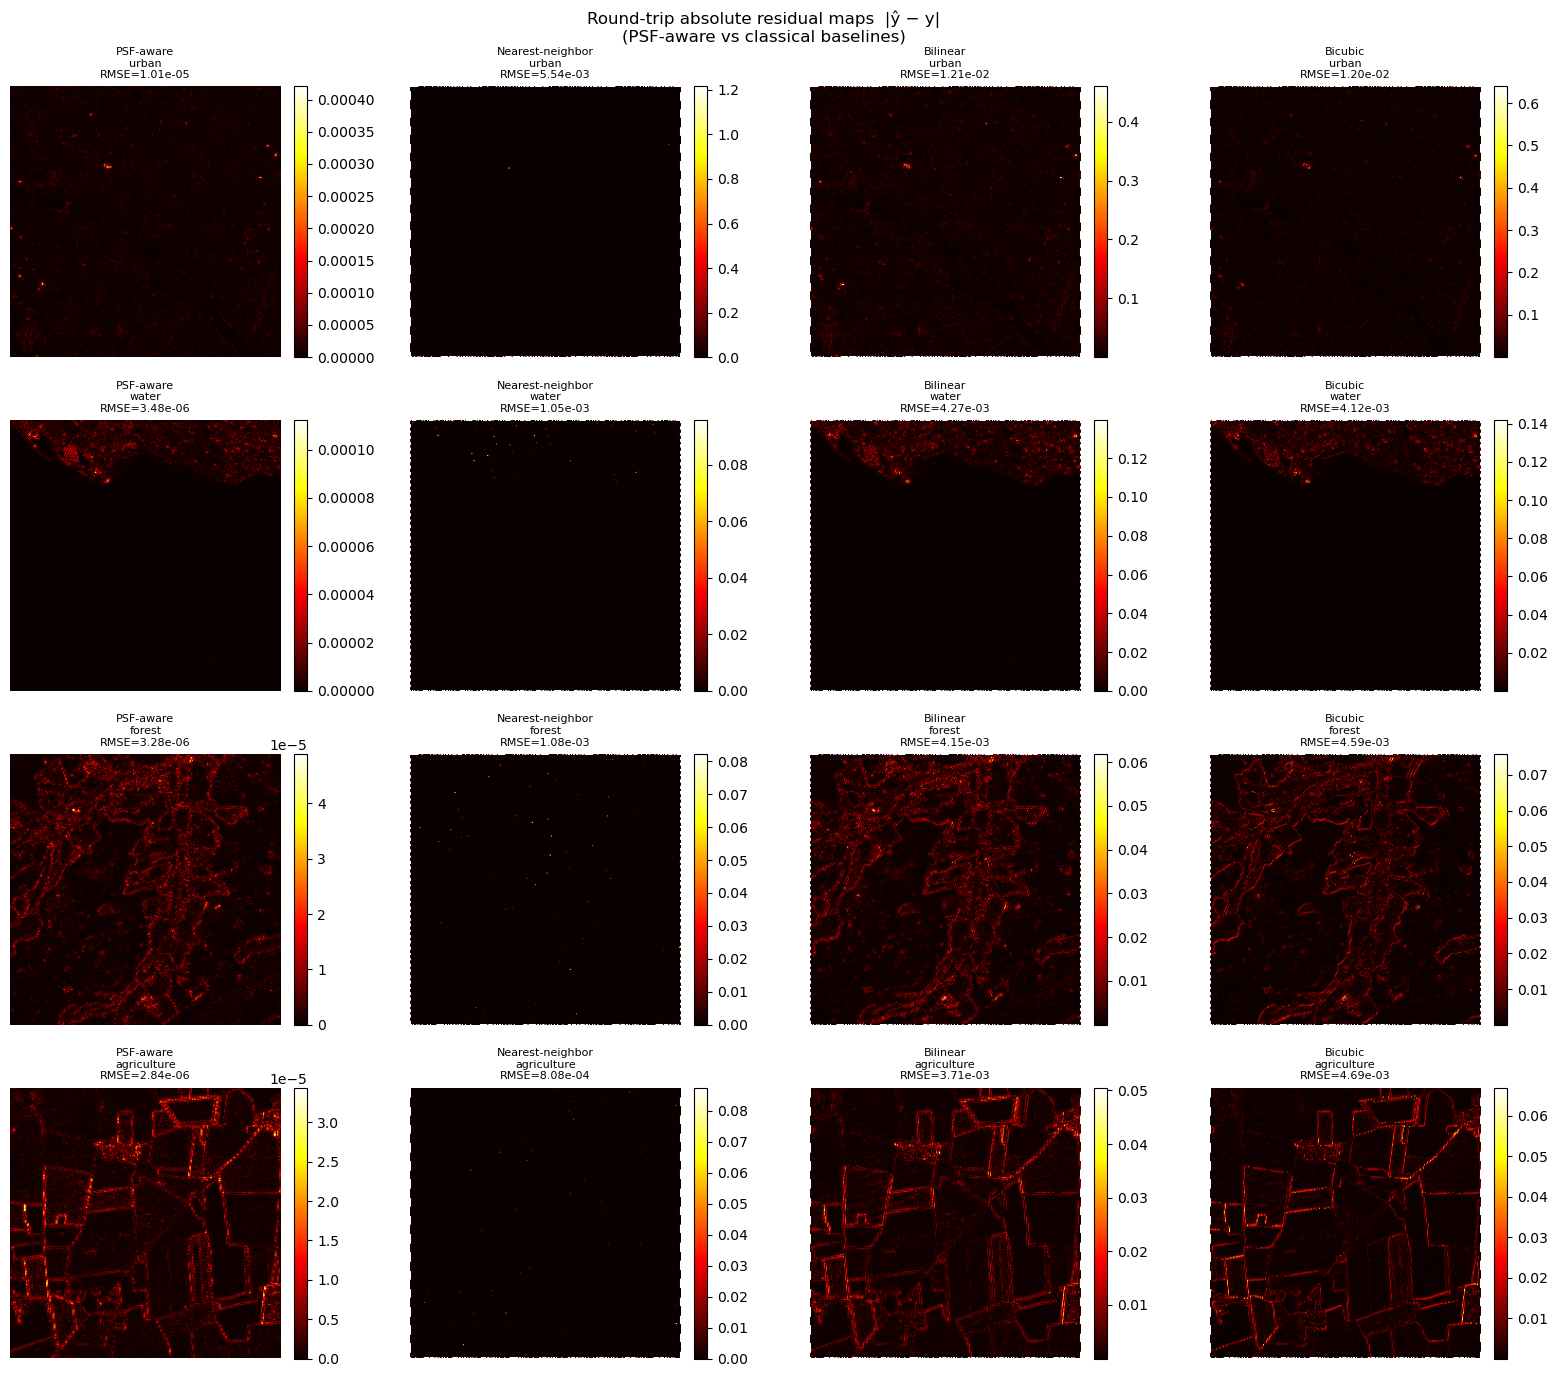

In [14]:
def plot_roundtrip_residuals(force=False):
    methods   = ["psf_aware"] + [f"classical_{m}" for m in CLASSICAL_METHODS]
    col_labels = ["PSF-aware", "Nearest-neighbor", "Bilinear", "Bicubic"]
    scenes    = list(benchmark_coordinates.keys())
    nrows     = len(scenes)
    ncols     = len(methods)

    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows))
    if nrows == 1:
        axes = axes[np.newaxis, :]

    for r, scene in enumerate(scenes):
        for c, (method, label) in enumerate(zip(methods, col_labels)):
            ax = axes[r, c]
            try:
                if method == "psf_aware":
                    data = psf_resample_scene(scene, force=force)
                else:
                    cl_method = method.replace("classical_", "")
                    data = classical_resample_scene(scene, method=cl_method, force=force)

                abs_res = np.abs(data["residual"])
                vmax = np.nanpercentile(abs_res, 100)
                vmin = np.nanpercentile(abs_res, 0.0)
                im = ax.imshow(abs_res, cmap="hot", vmin=vmin, vmax=vmax)
                plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
                rmse = float(np.sqrt(np.nanmean(data["residual"] ** 2)))
                ax.set_title(f"{label}\n{scene}\nRMSE={rmse:.2e}", fontsize=8)
            except Exception as exc:
                ax.text(0.5, 0.5, str(exc), transform=ax.transAxes,
                        ha="center", va="center", fontsize=7)
                ax.set_title(f"{label}\n{scene}", fontsize=8)
            ax.axis("off")

    fig.suptitle("Round-trip absolute residual maps  |ŷ − y|\n"
                 "(PSF-aware vs classical baselines)", fontsize=12)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "roundtrip_residuals_all_methods.pdf", dpi=150, bbox_inches="tight")
    print("Saved to figures/")
    return fig

fig_residuals = plot_roundtrip_residuals()
plt.show()


### Figure — Round-trip PSD comparison (all methods)

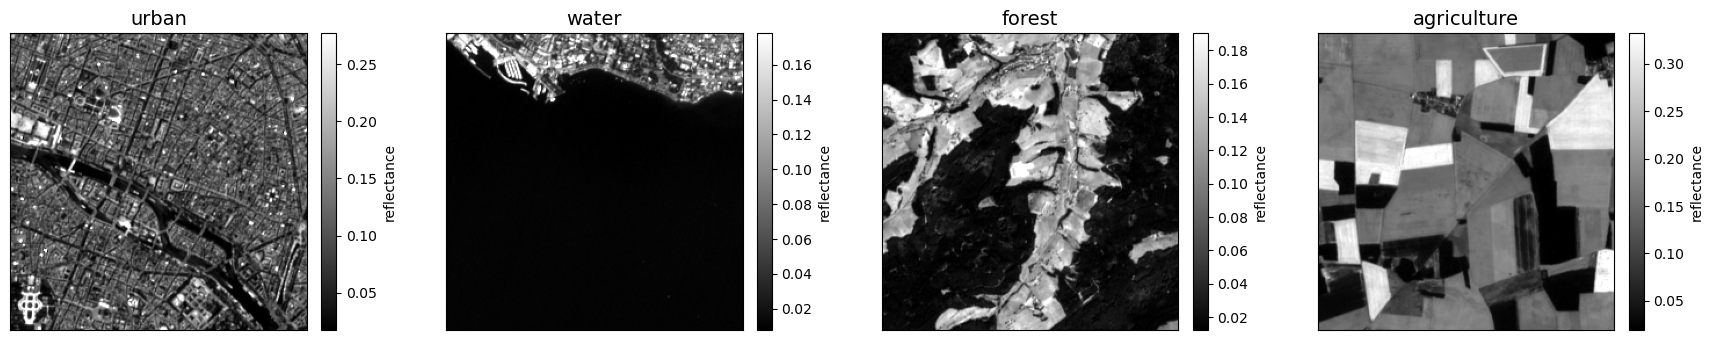

In [15]:
methods   = ["psf_aware"] + [f"classical_{m}" for m in CLASSICAL_METHODS]
col_labels = ["PSF-aware", "Nearest-neighbor", "Bilinear", "Bicubic"]
scenes    = list(benchmark_coordinates.keys())
ncols     = len(scenes)
nrows     = 1

fig, axes = plt.subplots(nrows, ncols, figsize=(4.4 * ncols, 3.5 * nrows))
if nrows == 1:
    axes = axes[np.newaxis, :]

for r, scene in enumerate(scenes):
    c=0
    ax = axes[c,r]
    data = psf_resample_scene(scene, force=False)
    abs_res = data['original']
    vmax = np.nanpercentile(abs_res, 99)
    vmin = np.nanpercentile(abs_res, 1.0)
    im = ax.imshow(abs_res, cmap="grey", vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04,label='reflectance')
    rmse = float(np.sqrt(np.nanmean(data["residual"] ** 2)))
    ax.set_title(f"{scene}", fontsize=14)
    ax.set_xticks([])
    ax.set_yticks([])
fig.tight_layout()
fig.savefig(FIG_DIR / "scene_types.pdf", bbox_inches="tight")


## 11. ESRI World Imagery sampler

Used as the latent spatial texture in the synthetic detector experiment.


In [16]:
import io, math, requests
from PIL import Image

# Pinned Wayback snapshot of World Imagery -- part of the experiment
# definition (see paper_data_guard). The live World_Imagery service is
# deliberately NOT used: its tiles change over time, and the derived
# textures are regenerated locally by every user rather than redistributed.
from paper_data_guard import (
    WAYBACK_RELEASE, WAYBACK_RELEASE_DATE, ESRI_WAYBACK_TILE_URL,
)
ESRI_WORLD_IMAGERY = ESRI_WAYBACK_TILE_URL
ESRI_TILE_CACHE_DIR = DATA_DIR / f"esri_tile_cache_wb{WAYBACK_RELEASE}"
ESRI_TILE_CACHE_DIR.mkdir(parents=True, exist_ok=True)

def latlon_to_xyz_frac(lat, lon, z):
    lat = np.asarray(lat, dtype=np.float64)
    lon = np.asarray(lon, dtype=np.float64)
    lat = np.clip(lat, -85.05112878, 85.05112878)
    n   = 2 ** int(z)
    xf  = (lon + 180.0) / 360.0 * n
    lat_rad = np.radians(lat)
    yf  = (1.0 - np.log(np.tan(lat_rad) + 1.0 / np.cos(lat_rad)) / math.pi) / 2.0 * n
    return xf, yf

def xyz_frac_to_tile_pixel(xf, yf, tile_size=256):
    xt = np.floor(xf).astype(np.int64)
    yt = np.floor(yf).astype(np.int64)
    px = np.clip(np.floor((xf - xt) * tile_size).astype(np.int64), 0, tile_size - 1)
    py = np.clip(np.floor((yf - yt) * tile_size).astype(np.int64), 0, tile_size - 1)
    return xt, yt, px, py

class EsriTileCache:
    def __init__(self, cache_dir=ESRI_TILE_CACHE_DIR, user_agent="research-sampler/1.0"):
        self.cache_dir = Path(cache_dir)
        self.cache_dir.mkdir(parents=True, exist_ok=True)
        self.memory_cache = {}
        self.session = requests.Session()
        self.session.headers.update({"User-Agent": user_agent})

    def _tile_path(self, z, x, y):
        return self.cache_dir / f"z{int(z)}" / f"x{int(x)}" / f"y{int(y)}.jpg"

    def get_tile(self, z, x, y, timeout=20):
        key = (int(z), int(x), int(y))
        if key in self.memory_cache:
            return self.memory_cache[key]
        path = self._tile_path(*key)
        if path.exists():
            img = Image.open(path).convert("RGB")
            self.memory_cache[key] = img
            return img
        if OFFLINE:
            raise FileNotFoundError(
                f"Missing Esri tile {path}; OFFLINE=True forbids downloading it."
            )
        url = ESRI_WORLD_IMAGERY.format(z=key[0], x=key[1], y=key[2])
        resp = self.session.get(url, timeout=timeout)
        resp.raise_for_status()
        # Raw server bytes, never re-encoded: a Pillow re-save (the old
        # quality=95 path) made the cached pixels -- and therefore the
        # regenerated stores' SHA-256 -- depend on the Pillow version.
        path.parent.mkdir(parents=True, exist_ok=True)
        tmp = path.with_name(path.name + ".tmp")
        tmp.write_bytes(resp.content)
        os.replace(tmp, path)
        img = Image.open(io.BytesIO(resp.content)).convert("RGB")
        self.memory_cache[key] = img
        return img


    def prefetch(self, zoom, tiles, max_workers=16, timeout=30):
        """Download missing tiles to the DISK cache in parallel.

        Pure I/O accelerator: only the on-disk JPEG cache is touched, and
        the sequential sampling path then behaves exactly as before
        (decode, memory cache, audit order unchanged). Tiles are
        independent HTTP fetches, so N workers are ~N times faster than
        the historical one-request-at-a-time loop. Raw server bytes are
        written atomically (tmp + os.replace): no re-encode, no partial
        file on interrupt.
        """
        import concurrent.futures, threading, os
        todo = [(int(zoom), int(x), int(y)) for x, y in tiles
                if not self._tile_path(int(zoom), int(x), int(y)).exists()]
        if not todo:
            return 0
        if OFFLINE:
            raise FileNotFoundError(
                f"{len(todo)} Esri tiles missing; OFFLINE=True forbids downloading."
            )
        local = threading.local()
        def fetch(key):
            sess = getattr(local, "session", None)
            if sess is None:
                sess = local.session = requests.Session()
                sess.headers.update(dict(self.session.headers))
            url = ESRI_WORLD_IMAGERY.format(z=key[0], x=key[1], y=key[2])
            for attempt in (1, 2):
                try:
                    resp = sess.get(url, timeout=timeout)
                    resp.raise_for_status()
                    break
                except Exception:
                    if attempt == 2:
                        raise
            path = self._tile_path(*key)
            path.parent.mkdir(parents=True, exist_ok=True)
            tmp = path.with_name(path.name + f".tmp{threading.get_ident()}")
            tmp.write_bytes(resp.content)
            os.replace(tmp, path)
        with concurrent.futures.ThreadPoolExecutor(max_workers=max_workers) as ex:
            list(ex.map(fetch, todo))
        return len(todo)

_ESRI_TILE_CACHE = EsriTileCache()

def rgb_to_luminance(rgb):
    rgb = np.asarray(rgb, dtype=np.float32)
    lum = 0.2989 * rgb[..., 0] + 0.5870 * rgb[..., 1] + 0.1140 * rgb[..., 2]
    return np.clip(lum / 255.0, 0.0, 1.0).astype(np.float32)

def sample_esri_world_imagery(lat, lon, zoom=17, tile_size=256, cache=None):
    if cache is None:
        cache = _ESRI_TILE_CACHE
    lat_arr = np.asarray(lat, dtype=np.float64)
    lon_arr = np.asarray(lon, dtype=np.float64)
    if lat_arr.shape != lon_arr.shape:
        raise ValueError("lat and lon must have the same shape.")
    original_shape = lat_arr.shape
    lat_flat, lon_flat = lat_arr.ravel(), lon_arr.ravel()
    xf, yf  = latlon_to_xyz_frac(lat_flat, lon_flat, zoom)
    xt, yt, px, py = xyz_frac_to_tile_pixel(xf, yf, tile_size=tile_size)
    rgb = np.full((lat_flat.size, 3), np.nan, dtype=np.float32)
    tile_pairs   = np.stack([xt, yt], axis=1)
    unique_tiles, inverse = np.unique(tile_pairs, axis=0, return_inverse=True)
    if not OFFLINE:
        cache.prefetch(zoom, [(int(x), int(y)) for x, y in unique_tiles])
    for tile_index, (x_tile, y_tile) in enumerate(unique_tiles):
        sel = np.where(inverse == tile_index)[0]
        try:
            arr = np.asarray(cache.get_tile(zoom, int(x_tile), int(y_tile)), dtype=np.float32)
            rgb[sel, :] = arr[py[sel], px[sel], :]
        except Exception as exc:
            print(f"[WARN] ESRI tile z={zoom} x={int(x_tile)} y={int(y_tile)}: {exc}")
    return rgb.reshape(original_shape + (3,)).astype(np.float32)

def sample_esri_lonlat(lon, lat, scene_name=None, zoom=17, as_gray=True, chunk_size=1_000_000):
    lon_arr, lat_arr = np.asarray(lon, dtype=np.float64), np.asarray(lat, dtype=np.float64)
    if lon_arr.shape != lat_arr.shape:
        raise ValueError("lon and lat must have the same shape.")
    shape    = lon_arr.shape
    lon_flat = lon_arr.ravel(); lat_flat = lat_arr.ravel(); n = lon_flat.size
    out = np.full(n, np.nan, dtype=np.float32) if as_gray else np.full((n, 3), np.nan, dtype=np.float32)
    for start in range(0, n, chunk_size):
        stop = min(start + chunk_size, n)
        rgb  = sample_esri_world_imagery(lat_flat[start:stop], lon_flat[start:stop], zoom=zoom, cache=_ESRI_TILE_CACHE)
        if as_gray:
            out[start:stop] = rgb_to_luminance(rgb)
        else:
            out[start:stop, :] = rgb.astype(np.float32) / 255.0
    return out.reshape(shape) if as_gray else out.reshape(shape + (3,))


## 12. Synthetic detector experiment — helpers

In [17]:
def fwhm_to_sigma(fwhm):
    return fwhm / (2.0 * np.sqrt(2.0 * np.log(2.0)))

def make_highres_axis(axis, oversample=4):
    axis = np.asarray(axis, dtype=np.float64)
    d = np.nanmedian(np.diff(axis))
    offsets = (np.arange(oversample) + 0.5) / oversample - 0.5
    return (axis[:, None] + offsets[None, :] * d).reshape(axis.size * oversample)

def block_mean_2d(img_hr, oversample=4):
    ny_hr, nx_hr = img_hr.shape
    ny = ny_hr // oversample; nx = nx_hr // oversample
    img_hr = img_hr[:ny * oversample, :nx * oversample]
    return img_hr.reshape(ny, oversample, nx, oversample).mean(axis=(1, 3))

def align_hpx_values(reference_ids, reference_values, estimated_ids, estimated_values):
    ref = pd.DataFrame({"cell_id": reference_ids.astype(np.int64), "reference": reference_values})
    est = pd.DataFrame({"cell_id": estimated_ids.astype(np.int64), "estimate": estimated_values})
    return ref.merge(est, on="cell_id", how="inner")


### 12.1 Build synthetic detector products (ESRI latent field)

In [18]:
ESRI_ZOOM = 17
ESRI_LATENT_CACHE_DIR = DATA_DIR / "esri_latent"
ESRI_LATENT_CACHE_DIR.mkdir(parents=True, exist_ok=True)


def esri_latent_cache_path(scene_name, central_size=CENTRAL_SIZE, oversample=4):
    return ESRI_LATENT_CACHE_DIR / (
        f"{scene_name}__z{ESRI_ZOOM}_n{central_size}_os{oversample}.zarr"
    )


def _write_esri_latent_zarr(path, latent_hr, x_hr, y_hr, metadata):
    """Atomically persist the PSF-independent Esri latent texture."""
    temporary = path.with_name(path.name + ".tmp")
    if temporary.exists():
        shutil.rmtree(temporary)
    group = open_zarr_group_w_v2(temporary)
    arrays = {
        "latent_hr": (np.asarray(latent_hr, dtype=np.float32), (256, 256)),
        "x_hr": (np.asarray(x_hr, dtype=np.float64), (len(x_hr),)),
        "y_hr": (np.asarray(y_hr, dtype=np.float64), (len(y_hr),)),
    }
    for name, (values, chunks) in arrays.items():
        if hasattr(group, "create_array"):
            group.create_array(name, data=values, chunks=chunks, overwrite=True)
        else:
            group.array(name, values, chunks=chunks, overwrite=True)
    group.attrs.update(metadata)
    del group
    if path.exists():
        shutil.rmtree(path)
    temporary.replace(path)


def load_or_create_esri_latent(
    scene_name, lon_hr, lat_hr, x_hr, y_hr,
    central_size=CENTRAL_SIZE, oversample=4,
):
    """Load a frozen Esri texture, or create it only when OFFLINE is false.

    The cached field precedes every imposed PSF convolution, so the same Zarr
    supports new FWHM values, anisotropic forward blurs, and noise experiments.
    """
    path = esri_latent_cache_path(scene_name, central_size, oversample)
    expected_shape = (central_size * oversample, central_size * oversample)
    if path.exists():
        group = zarr.open_group(str(path), mode="r")
        latent_hr = np.asarray(group["latent_hr"][:], dtype=np.float32)
        cached_x = np.asarray(group["x_hr"][:], dtype=np.float64)
        cached_y = np.asarray(group["y_hr"][:], dtype=np.float64)
        attrs = dict(group.attrs)
        del group
        if latent_hr.shape != expected_shape:
            raise ValueError(f"{path}: latent shape {latent_hr.shape} != {expected_shape}")
        if cached_x.shape != np.shape(x_hr) or not np.allclose(cached_x, x_hr, atol=1e-6):
            raise ValueError(f"{path}: x_hr does not match the frozen Sentinel grid")
        if cached_y.shape != np.shape(y_hr) or not np.allclose(cached_y, y_hr, atol=1e-6):
            raise ValueError(f"{path}: y_hr does not match the frozen Sentinel grid")
        if attrs.get("scene_name") != scene_name or int(attrs.get("esri_zoom", -1)) != ESRI_ZOOM:
            raise ValueError(f"{path}: metadata does not match scene/zoom")
        print(f"[Esri latent Zarr] {scene_name}: {path}")
        return latent_hr

    if OFFLINE:
        raise FileNotFoundError(
            f"Missing frozen Esri input: {path}. Download the DOI data archive "
            "and place its data/ directory under notebooks/. OFFLINE=True "
            "forbids a fallback to mutable web tiles."
        )

    latent_hr = sample_esri_lonlat(
        lon_hr, lat_hr, scene_name=scene_name, zoom=ESRI_ZOOM
    ).astype(np.float32)
    metadata = {
        "scene_name": scene_name,
        "esri_zoom": ESRI_ZOOM,
        "central_size": int(central_size),
        "oversample": int(oversample),
        "source": "Esri World Imagery",
        "source_url_template": ESRI_WORLD_IMAGERY,
        "source_sentinel_product_id": benchmark_coordinates.get(
            scene_name, {}
        ).get("product_id", ""),
    }
    _write_esri_latent_zarr(path, latent_hr, x_hr, y_hr, metadata)
    print(f"[Esri latent Zarr] wrote {path}")
    return latent_hr


def build_synthetic_detector_products(
    scene_name, level=HEALPIX_LEVEL, oversample=4,
    fwhm_m=FWHM, central_size=CENTRAL_SIZE, force=True
):
    """
    Build four synthetic products from an ESRI latent field.

    Returns
    -------
    dict with keys: utm_ref_no_psf, utm_det_psf, hpx_parent_ids,
                    hpx_ref_no_psf, hpx_det_psf, metadata.
    """

    out_npz = DATA_DIR / f"{scene_name}_synthetic_detector_level{level}_os{oversample}_fwhm{fwhm_m:.1f}.npz"
    if out_npz.exists() and not force:
        return dict(np.load(out_npz, allow_pickle=True))

    img, lon_coarse, lat_coarse, da = load_scene_patch(scene_name)
    img0 = central_crop(img, central_size)
    lon0 = central_crop(lon_coarse, central_size)
    lat0 = central_crop(lat_coarse, central_size)

    x0 = central_crop(np.tile(da.x.values[None, :], (da.y.size, 1)), central_size)[0, :]
    y0 = central_crop(np.tile(da.y.values[:, None], (1, da.x.size)), central_size)[:, 0]

    x_hr = make_highres_axis(x0, oversample=oversample)
    y_hr = make_highres_axis(y0, oversample=oversample)
    xx_hr, yy_hr = np.meshgrid(x_hr, y_hr, indexing="xy")

    crs_utm = _crs_of(da)
    t_to_wgs   = pyproj.Transformer.from_crs(crs_utm, 4326, always_xy=True)
    t_from_wgs = pyproj.Transformer.from_crs(4326, crs_utm, always_xy=True)
    lon_hr, lat_hr = t_to_wgs.transform(xx_hr, yy_hr)

    esri_hr = load_or_create_esri_latent(
        scene_name, lon_hr, lat_hr, x_hr, y_hr,
        central_size=central_size, oversample=oversample,
    )

    dx_hr = abs(np.nanmedian(np.diff(x_hr)))
    dy_hr = abs(np.nanmedian(np.diff(y_hr)))
    print(dx_hr,dy_hr)
    sigma_m   = fwhm_to_sigma(fwhm_m)
    sigma_pix = sigma_m / np.sqrt(dx_hr * dy_hr)
    esri_psf_hr = gaussian_filter(esri_hr, sigma=sigma_pix, mode="reflect")
    
    utm_ref_no_psf = block_mean_2d(esri_hr,     oversample=oversample)
    utm_det_psf    = block_mean_2d(esri_psf_hr, oversample=oversample)

    nside       = 2 ** level
    nside_child = 2 ** (level + 2)
    parent_ids = np.unique(sph_ang2pix(nside, lon_hr.ravel(), lat_hr.ravel(),
                                      lonlat=True, nest=True)).astype(np.int64)

    child_offsets = np.arange(oversample ** 2, dtype=np.int64)
    child_ids_flat = (parent_ids[:, None] * (oversample ** 2) + child_offsets[None, :]).reshape(-1)

    child_lon, child_lat = sph_pix2ang(nside_child, child_ids_flat, lonlat=True, nest=True)
    child_x, child_y    = t_from_wgs.transform(child_lon, child_lat)

    interp_esri = prepare_regular_interpolator(y_hr, x_hr, esri_hr)
    interp_psf  = prepare_regular_interpolator(y_hr, x_hr, esri_psf_hr)

    pts = np.column_stack([child_y, child_x])
    child_ref = interp_esri(pts).reshape(parent_ids.size, oversample ** 2)
    child_psf = interp_psf(pts).reshape(parent_ids.size, oversample ** 2)

    hpx_ref_no_psf = np.nanmean(child_ref, axis=1).astype(np.float32)
    hpx_det_psf    = np.nanmean(child_psf, axis=1).astype(np.float32)

    np.savez_compressed(
        out_npz,
        scene=scene_name, level=level, oversample=oversample, fwhm_m=fwhm_m,
        x=x0.astype(np.float32), y=y0.astype(np.float32),
        lon=lon0.astype(np.float32), lat=lat0.astype(np.float32),
        utm_ref_no_psf=utm_ref_no_psf.astype(np.float32),
        utm_det_psf=utm_det_psf.astype(np.float32),
        hpx_parent_ids=parent_ids,
        hpx_ref_no_psf=hpx_ref_no_psf,
        hpx_det_psf=hpx_det_psf,
    )
    return dict(np.load(out_npz, allow_pickle=True))


In [19]:
from healpix_geo.nested import healpix_to_lonlat

def heal_local_fft(lon, lat, cell_ids, values, level=20, interpol=None, data=None, ref=None, pixel_size_m=10.0):
    """
    Local (patch-scale) 2-D power-spectrum estimate, used by the spectral
    diagnostic figures (resample-test.pdf / all-spectra.pdf, cited in the
    paper -- see 13.x below). Optionally re-projects HEALPix cell values
    through a chosen UTM-side interpolation method first (`interpol`), to
    compare how different geometric resamplers shape the spectrum of the
    same underlying field.
    """
    lonh, lath = healpix_to_lonlat(cell_ids, level)

    if interpol is not None:
        values = griddata(np.column_stack([lon.flatten(), lat.flatten()]),
                           values.flatten().astype(np.float64),
                           (lonh.flatten(), lath.flatten()),
                           fill_value=0.0,
                           method=interpol)
        if ref is not None:
            values -= ref
    if data is None:
        data = griddata(np.column_stack([lonh, lath]),
                         values.astype(np.float64),
                         (lon.flatten(), lat.flatten()),
                         fill_value=0.0,
                         method="linear").reshape(lon.shape)
    filt = np.hanning(lon.shape[0])
    data = data * np.sqrt(filt[None, :] * filt[:, None])
    data[np.isnan(data)] = 0.0
    fdata = np.fft.fft2(data)
    fdata = np.fft.fftshift(fdata * np.conjugate(fdata)).real

    n = lon.shape[0]
    x = np.arange(n) - n // 2
    r = np.sqrt(x[None, :] ** 2 + x[:, None] ** 2).astype('int')

    r_bin = np.bincount(r.flatten(), r.flatten()) / np.bincount(r.flatten())
    freq = r_bin / (n * pixel_size_m)

    return (freq,
            2 * np.pi ** 2 * np.bincount(r.flatten(), fdata.flatten())
            / (lonh.shape[0] * np.bincount(r.flatten())))

### 12.2 PSF-aware resampler on synthetic observation

In [20]:
def run_synthetic_psf_resampler_test(
    scene_name, level=HEALPIX_LEVEL, oversample=4,
    fwhm_m=FWHM , lam=LAMBDA, max_iter=MAX_ITER,
    threshold=THRESHOLD, force=True, fwhm_resampler=FWHM, Npt=None,
):
    """
    Parameters
    ----------
    fwhm_resampler : float
        Intended FWHM (metres) of the *operator's* assumed response.
        Converted internally to the `s` scale PSFResampler's ``sigma_m``
        actually expects, via ``fwhm_to_scale()`` -- do not pass this value
        straight through as ``sigma_m`` (see ``fwhm_to_scale``'s docstring /
        the review notes in cell 1 for why that silently mis-specifies the
        kernel: it was exactly this bug that made the matched arm run with
        an effective FWHM about 1.18x the intended one, before truncation
        narrowed it back down again).
    Npt : int, optional
        Number of nearest HEALPix cells per sample. If None (default),
        chosen automatically via ``recommend_npt()`` to retain >=99% of the
        kernel's mass at this FWHM/level -- the fixed ``Npt=9`` this
        notebook used previously only does that for kernels about as wide
        as one cell; see ``healpix_resample.diagnostics.kernel_geometry``.
    """
    if PSFResampler is None:
        raise ImportError("PSFResampler is not available.")

    products = build_synthetic_detector_products(scene_name, level=level,
                                                 oversample=oversample, fwhm_m=fwhm_m, 
                                                 force=force)

    scale_m, npt_auto = npt_for_fwhm(fwhm_resampler, level=level)
    npt = int(Npt) if Npt is not None else npt_auto

    out_npz = DATA_DIR / (
        f"{scene_name}_synthetic_psf_resampler_level{level}"
        f"_fwhmop{fwhm_resampler:.2f}_lam{lam:.4g}_npt{npt}.npz"
    )  # fwhm_resampler/lam/npt included so mismatched-PSF and pre-fix cached
       # runs don't collide with these (correctly-converted) results
    if out_npz.exists() and not force:
        return dict(np.load(out_npz, allow_pickle=True))

    y   = products["utm_det_psf"]
    lon = products["lon"]; lat = products["lat"]

    resampler = PSFResampler(
        lon_deg=lon.reshape(-1).astype("float64"),
        lat_deg=lat.reshape(-1).astype("float64"),
        level=level, threshold=threshold, verbose=True,
        ellipsoid="sphere", sigma_m=scale_m, 
        Npt=npt,device=DEVICE,
    )
    result = resampler.resample(y.reshape(-1), lam=lam, max_iter=max_iter)

    aligned_no_psf = align_hpx_values(
        products["hpx_parent_ids"], products["hpx_ref_no_psf"],
        np.asarray(result.cell_ids), np.asarray(result.cell_data),
    )
    aligned_psf = align_hpx_values(
        products["hpx_parent_ids"], products["hpx_det_psf"],
        np.asarray(result.cell_ids), np.asarray(result.cell_data),
    )

    np.savez_compressed(
        out_npz,
        scene=scene_name, level=level,
        estimated_cell_ids=np.asarray(result.cell_ids).astype(np.int64),
        estimated_cell_data=np.asarray(result.cell_data).astype(np.float32),
        aligned_no_psf_cell_ids=aligned_no_psf["cell_id"].to_numpy(dtype=np.int64),
        aligned_no_psf_reference=aligned_no_psf["reference"].to_numpy(dtype=np.float32),
        aligned_no_psf_estimate=aligned_no_psf["estimate"].to_numpy(dtype=np.float32),
        aligned_psf_reference=aligned_psf["reference"].to_numpy(dtype=np.float32),
        aligned_psf_estimate=aligned_psf["estimate"].to_numpy(dtype=np.float32),
    )
    return dict(np.load(out_npz, allow_pickle=True))


### 12.3 Classical resampling on synthetic PSF observation

Apply nearest/bilinear/bicubic interpolation to the PSF-blurred synthetic observation
(`utm_det_psf`) and compare the resulting HEALPix values against the ESRI ground-truth
HEALPix fields (`hpx_ref_no_psf` and `hpx_det_psf`).


In [21]:
def run_classical_synthetic_test(scene_name, method="linear", level=HEALPIX_LEVEL,
                                    oversample=4, fwhm_m=FWHM , force=True):
    """
    Classical (geometric) resampling of the synthetic PSF-blurred observation to HEALPix.

    The PSF-blurred UTM image (utm_det_psf) is interpolated at HEALPix cell centres
    using the specified method. Results are aligned with the ESRI reference fields
    for comparison in Table I.
    """

    products = build_synthetic_detector_products(scene_name, level=level,
                                                 oversample=oversample, fwhm_m=fwhm_m, force=force)

    out_npz = DATA_DIR / f"{scene_name}_synthetic_classical_{method}_level{level}_fwhm{fwhm_m:.2f}.npz"
    if out_npz.exists() and not force:
        return dict(np.load(out_npz, allow_pickle=True))

    # Input: the PSF-blurred observation on the UTM grid
    utm_det = products["utm_det_psf"]
    lon     = products["lon"].astype(np.float64)
    lat     = products["lat"].astype(np.float64)

    # Get HEALPix parent cell IDs from the latent-field reference
    parent_ids = products["hpx_parent_ids"].astype(np.int64)
    nside      = 2 ** level

    # Cell centres in geographic coords
    hpx_lon, hpx_lat = sph_pix2ang(nside, parent_ids, lonlat=True, nest=True)

    # Build a UTM CRS from the first scene DataArray
    _, _, _, da = load_scene_patch(scene_name)
    crs_utm = _crs_of(da)
    t_fwd   = pyproj.Transformer.from_crs(4326, crs_utm, always_xy=True)
    hpx_x, hpx_y = t_fwd.transform(hpx_lon, hpx_lat)

    # Reconstruct 1-D UTM axes from the central crop
    x0, y0 = get_utm_axes(da)

    # Forward: interpolate utm_det at HEALPix cell centres
    if method in ("nearest", "linear"):
        interp_fwd = prepare_regular_interpolator(y0, x0, utm_det, method=method)
        hpx_values = interp_fwd(np.column_stack([hpx_y, hpx_x]))
    else:
        xx_utm, yy_utm = np.meshgrid(x0, y0)
        hpx_values = griddata(
            points=np.column_stack([xx_utm.ravel(), yy_utm.ravel()]),
            values=utm_det.ravel(),
            xi=np.column_stack([hpx_x, hpx_y]),
            method=method,
        )

    # Fill NaN values
    if np.any(~np.isfinite(hpx_values)):
        interp_nn  = prepare_regular_interpolator(y0, x0, utm_det, method="nearest")
        hpx_nn     = interp_nn(np.column_stack([hpx_y, hpx_x]))
        hpx_values = np.where(np.isfinite(hpx_values), hpx_values, hpx_nn)

    # Align with ESRI reference fields
    estimated_ids = parent_ids.copy()
    al_no_psf = align_hpx_values(
        parent_ids, products["hpx_ref_no_psf"], estimated_ids, hpx_values)
    al_psf    = align_hpx_values(
        parent_ids, products["hpx_det_psf"],    estimated_ids, hpx_values)

    np.savez_compressed(
        out_npz,
        scene=scene_name, level=level, method=method,
        estimated_cell_ids=estimated_ids,
        estimated_cell_data=hpx_values.astype(np.float32),
        aligned_no_psf_reference=al_no_psf["reference"].to_numpy(dtype=np.float32),
        aligned_no_psf_estimate=al_no_psf["estimate"].to_numpy(dtype=np.float32),
        aligned_psf_reference=al_psf["reference"].to_numpy(dtype=np.float32),
        aligned_psf_estimate=al_psf["estimate"].to_numpy(dtype=np.float32),
    )
    return dict(np.load(out_npz, allow_pickle=True))


### 12.3b Richardson-Lucy deconvolution (classical PSF-aware baseline)

A second, purely classical PSF-aware baseline: Richardson-Lucy deconvolution
(`skimage.restoration.richardson_lucy`), applied directly on the UTM grid
using the **true, matched** generation PSF (an idealized best case for this
method), followed by bilinear resampling to HEALPix cell centres for a
like-for-like comparison with the other rows of Table I.


In [22]:
def build_gaussian_psf_kernel(fwhm_m, pixel_size_m, radius_sigma=4.0):
    """2-D normalized Gaussian PSF kernel, in pixel units, for richardson_lucy."""
    sigma_pix = fwhm_to_sigma(fwhm_m) / pixel_size_m
    radius = max(1, int(np.ceil(radius_sigma * sigma_pix)))
    ax = np.arange(-radius, radius + 1)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2.0 * sigma_pix**2))
    return kernel / kernel.sum()


def resample_utm_field_to_healpix_children(
    field_utm, x0, y0, parent_ids, level, da,
    gsd_m=RL_REBIN_GSD_M, interp_method="cubic",
):
    """
    Cell-average estimand for a UTM-gridded field: interpolate `field_utm`
    (bicubic by default) onto an oversampled UTM grid at ~`gsd_m` spacing,
    then average the samples falling at each parent HEALPix cell's nested
    children -- the same technique `build_synthetic_detector_products` uses
    to build the ESRI ground-truth hpx_ref_no_psf/hpx_det_psf fields.

    This replaces a single bilinear point sample at the cell centre (the
    previous approach), which is a *different* estimand (point value, not
    cell average) than everything else in Table I is scored against, and
    which additionally smooths the deconvolution result more than
    necessary. Requested per review follow-up: either upgrade the
    point-interpolation to bicubic, or avoid point-sampling altogether by
    sub-sampling to a fine UTM grid and rebinning into HEALPix -- this does
    both (bicubic upsample, then area-average rebin), and reuses the exact
    method already used for the ESRI ground truth so RL is judged on the
    same footing as every other row in Table I. See 17.5,
    compare_point_vs_cell_average_estimand, for the point-vs-cell-average
    estimand check this design choice follows from.

    oversample (children per cell per axis) is derived from `gsd_m` and the
    native pixel spacing of (x0, y0), rounded to the nearest power of two so
    it lines up with a HEALPix level (nside_child = nside * oversample).
    """
    pixel_size_m = abs(np.nanmedian(np.diff(x0)))
    raw_oversample = max(1.0, pixel_size_m / gsd_m)
    log2_os = int(round(np.log2(raw_oversample)))
    oversample = max(1, 2 ** log2_os)
    n_child = oversample ** 2
    nside_child = 2 ** (level + log2_os)

    if oversample > 1:
        x_hr = make_highres_axis(x0, oversample=oversample)
        y_hr = make_highres_axis(y0, oversample=oversample)
        interp = prepare_regular_interpolator(y0, x0, field_utm, method=interp_method)
        xx_hr, yy_hr = np.meshgrid(x_hr, y_hr, indexing="xy")
        field_hr = interp(np.column_stack([yy_hr.ravel(), xx_hr.ravel()])).reshape(xx_hr.shape)
    else:
        x_hr, y_hr, field_hr = x0, y0, field_utm

    child_offsets = np.arange(n_child, dtype=np.int64)
    child_ids_flat = (parent_ids[:, None] * n_child + child_offsets[None, :]).reshape(-1)
    child_lon, child_lat = sph_pix2ang(nside_child, child_ids_flat, lonlat=True, nest=True)

    crs_utm = _crs_of(da)
    t_from_wgs = pyproj.Transformer.from_crs(4326, crs_utm, always_xy=True)
    child_x, child_y = t_from_wgs.transform(child_lon, child_lat)

    interp_fine = prepare_regular_interpolator(y_hr, x_hr, field_hr, method="linear")
    child_vals = interp_fine(np.column_stack([child_y, child_x])).reshape(parent_ids.size, n_child)

    if np.any(~np.isfinite(child_vals)):
        interp_nn = prepare_regular_interpolator(y_hr, x_hr, field_hr, method="nearest")
        nn_vals = interp_nn(np.column_stack([child_y, child_x])).reshape(parent_ids.size, n_child)
        child_vals = np.where(np.isfinite(child_vals), child_vals, nn_vals)

    return np.nanmean(child_vals, axis=1).astype(np.float32)


def run_richardson_lucy_synthetic_test(
    scene_name, level=HEALPIX_LEVEL, oversample=4,
    fwhm_m=FWHM, num_iter=RICHARDSON_LUCY_ITER, force=True,
):
    """
    Richardson-Lucy deconvolution of the synthetic PSF-blurred UTM observation,
    using the *true* generation PSF (matched, idealized case), followed by
    a bicubic-upsample + HEALPix-child-average rebin to cell averages (see
    resample_utm_field_to_healpix_children) -- not a single bilinear point
    sample as before. Results are aligned with the ESRI reference fields for
    comparison in Table I, exactly like the classical geometric baselines.
    """
    if richardson_lucy is None:
        raise ImportError("scikit-image richardson_lucy is not available.")

    products = build_synthetic_detector_products(scene_name, level=level,
                                                 oversample=oversample, fwhm_m=fwhm_m,
                                                 force=force)

    out_npz = DATA_DIR / (
        f"{scene_name}_synthetic_richardson_lucy_level{level}_iter{num_iter}"
        f"_fwhm{fwhm_m:.2f}_rebin{RL_REBIN_GSD_M:.1f}m.npz"
    )
    if out_npz.exists() and not force:
        return dict(np.load(out_npz, allow_pickle=True))

    utm_det = products["utm_det_psf"].astype(np.float64)

    parent_ids = products["hpx_parent_ids"].astype(np.int64)
    nside      = 2 ** level

    _, _, _, da = load_scene_patch(scene_name)
    x0, y0 = get_utm_axes(da)
    pixel_size_m = abs(np.nanmedian(np.diff(x0)))
    psf_kernel = build_gaussian_psf_kernel(fwhm_m, pixel_size_m)

    # richardson_lucy expects a non-negative image; rescale to [0, 1] and back.
    vmin, vmax = float(np.nanmin(utm_det)), float(np.nanmax(utm_det))
    scale = (vmax - vmin) if vmax > vmin else 1.0
    img01 = np.clip((utm_det - vmin) / scale, 0.0, 1.0)
    deconv01 = richardson_lucy(img01, psf_kernel, num_iter=num_iter, clip=False)
    deconv = deconv01 * scale + vmin

    hpx_values = resample_utm_field_to_healpix_children(
        deconv, x0, y0, parent_ids, level, da,
        gsd_m=RL_REBIN_GSD_M, interp_method="cubic",
    )

    al_no_psf = align_hpx_values(parent_ids, products["hpx_ref_no_psf"], parent_ids, hpx_values)
    al_psf    = align_hpx_values(parent_ids, products["hpx_det_psf"],    parent_ids, hpx_values)

    np.savez_compressed(
        out_npz,
        scene=scene_name, level=level, num_iter=num_iter,
        estimated_cell_ids=parent_ids,
        estimated_cell_data=hpx_values.astype(np.float32),
        aligned_no_psf_reference=al_no_psf["reference"].to_numpy(dtype=np.float32),
        aligned_no_psf_estimate=al_no_psf["estimate"].to_numpy(dtype=np.float32),
        aligned_psf_reference=al_psf["reference"].to_numpy(dtype=np.float32),
        aligned_psf_estimate=al_psf["estimate"].to_numpy(dtype=np.float32),
    )
    return dict(np.load(out_npz, allow_pickle=True))


In [23]:
def tikhonov_deconvolve(image, psf_kernel, lam=1e-2):
    """Direct (non-iterative) Tikhonov-regularized deconvolution in the
    Fourier domain: X_hat = conj(H) / (|H|^2 + lam) * Y. `psf_kernel` is
    the same small real-space kernel build_gaussian_psf_kernel() builds for
    Richardson-Lucy (cell 42), just used non-iteratively here.
    """
    ny, nx = image.shape
    kh, kw = psf_kernel.shape
    psf_full = np.zeros((ny, nx), dtype=np.float64)
    psf_full[:kh, :kw] = psf_kernel
    psf_full = np.roll(psf_full, (-(kh // 2), -(kw // 2)), axis=(0, 1))
    H = np.fft.fft2(psf_full)
    Y = np.fft.fft2(image)
    X = (np.conj(H) / (np.abs(H) ** 2 + lam)) * Y
    return np.real(np.fft.ifft2(X))


def run_tikhonov_bicubic_ablation(
    scene_name, level=HEALPIX_LEVEL, oversample=4,
    fwhm_m=FWHM, lam_tikhonov=1e-2, force=True,
):
    """
    Ablation requested in the review (point 5): same two-stage structure as
    Richardson-Lucy (deconvolve on UTM, then resample) but a different,
    non-iterative deconvolution (Tikhonov, closed form), followed by the
    *same* bicubic classical resampling already used elsewhere in this
    notebook -- not RL's specific bilinear step. Comparing PSF-aware against
    this tells you whether the joint formulation earns its complexity;
    comparing this against the existing Richardson-Lucy rows in Table I
    tells you whether RL specifically is a weak deconvolver. Table I alone
    conflates both questions.
    """
    products = build_synthetic_detector_products(scene_name, level=level,
                                                 oversample=oversample, fwhm_m=fwhm_m, force=force)
    out_npz = DATA_DIR / f"{scene_name}_tikhonov_bicubic_level{level}_lam{lam_tikhonov:.4g}.npz"
    if out_npz.exists() and not force:
        return dict(np.load(out_npz, allow_pickle=True))

    utm_det = products["utm_det_psf"].astype(np.float64)
    parent_ids = products["hpx_parent_ids"].astype(np.int64)
    nside = 2 ** level

    _, _, _, da = load_scene_patch(scene_name)
    x0, y0 = get_utm_axes(da)
    pixel_size_m = abs(np.nanmedian(np.diff(x0)))
    psf_kernel = build_gaussian_psf_kernel(fwhm_m, pixel_size_m)

    deconv = tikhonov_deconvolve(utm_det, psf_kernel, lam=lam_tikhonov)

    hpx_lon, hpx_lat = sph_pix2ang(nside, parent_ids, lonlat=True, nest=True)
    crs_utm = _crs_of(da)
    t_fwd = pyproj.Transformer.from_crs(4326, crs_utm, always_xy=True)
    hpx_x, hpx_y = t_fwd.transform(hpx_lon, hpx_lat)

    xx_utm, yy_utm = np.meshgrid(x0, y0)
    hpx_values = griddata(
        points=np.column_stack([xx_utm.ravel(), yy_utm.ravel()]),
        values=deconv.ravel(),
        xi=np.column_stack([hpx_x, hpx_y]),
        method="cubic",
    )
    if np.any(~np.isfinite(hpx_values)):
        interp_nn = prepare_regular_interpolator(y0, x0, deconv, method="nearest")
        hpx_nn = interp_nn(np.column_stack([hpx_y, hpx_x]))
        hpx_values = np.where(np.isfinite(hpx_values), hpx_values, hpx_nn)

    al_no_psf = align_hpx_values(parent_ids, products["hpx_ref_no_psf"], parent_ids, hpx_values)
    al_psf = align_hpx_values(parent_ids, products["hpx_det_psf"], parent_ids, hpx_values)

    np.savez_compressed(
        out_npz, scene=scene_name, level=level, lam_tikhonov=lam_tikhonov,
        estimated_cell_ids=parent_ids,
        estimated_cell_data=hpx_values.astype(np.float32),
        aligned_no_psf_reference=al_no_psf["reference"].to_numpy(dtype=np.float32),
        aligned_no_psf_estimate=al_no_psf["estimate"].to_numpy(dtype=np.float32),
        aligned_psf_reference=al_psf["reference"].to_numpy(dtype=np.float32),
        aligned_psf_estimate=al_psf["estimate"].to_numpy(dtype=np.float32),
    )
    return dict(np.load(out_npz, allow_pickle=True))


def run_richardson_lucy_via_psf_projection(
    scene_name, level=HEALPIX_LEVEL, oversample=4,
    fwhm_m=FWHM, num_iter=RICHARDSON_LUCY_ITER, force=True,
):
    """
    Same Richardson-Lucy deconvolution as run_richardson_lucy_synthetic_test
    (cell 42), but projected onto HEALPix through the *same* PSFResampler
    machinery the PSF-aware method uses (at the package's default,
    cell-width kernel scale -- RL has already deconvolved the detector
    response away, so this projection step should not reintroduce any
    *additional* assumed response), instead of bilinear interpolation.
    Isolates the deconvolution-quality question from the pipeline/
    evaluation asymmetry the review identifies: RL loses to "doing nothing"
    partly because bilinear reconstruction re-imposes close to the blur
    just removed, not necessarily because the deconvolution itself is worse
    than PSF-aware's joint solve.
    """
    if PSFResampler is None:
        raise ImportError("PSFResampler is not available.")
    if richardson_lucy is None:
        raise ImportError("scikit-image richardson_lucy is not available.")

    products = build_synthetic_detector_products(scene_name, level=level,
                                                 oversample=oversample, fwhm_m=fwhm_m, force=force)
    out_npz = DATA_DIR / f"{scene_name}_rl_via_psf_projection_level{level}_iter{num_iter}.npz"
    if out_npz.exists() and not force:
        return dict(np.load(out_npz, allow_pickle=True))

    utm_det = products["utm_det_psf"].astype(np.float64)
    lon = products["lon"]; lat = products["lat"]

    _, _, _, da = load_scene_patch(scene_name)
    x0, y0 = get_utm_axes(da)
    pixel_size_m = abs(np.nanmedian(np.diff(x0)))
    psf_kernel = build_gaussian_psf_kernel(fwhm_m, pixel_size_m)

    vmin, vmax = float(np.nanmin(utm_det)), float(np.nanmax(utm_det))
    scale = (vmax - vmin) if vmax > vmin else 1.0
    img01 = np.clip((utm_det - vmin) / scale, 0.0, 1.0)
    deconv01 = richardson_lucy(img01, psf_kernel, num_iter=num_iter, clip=False)
    deconv = deconv01 * scale + vmin

    resampler = PSFResampler(
        lon_deg=lon.reshape(-1).astype("float64"),
        lat_deg=lat.reshape(-1).astype("float64"),
        level=level, threshold=THRESHOLD, verbose=False, ellipsoid="sphere",device=DEVICE,
    )
    result = resampler.resample(deconv.reshape(-1), lam=0.0, max_iter=MAX_ITER)

    aligned_no_psf = align_hpx_values(
        products["hpx_parent_ids"], products["hpx_ref_no_psf"],
        np.asarray(result.cell_ids), np.asarray(result.cell_data))
    aligned_psf = align_hpx_values(
        products["hpx_parent_ids"], products["hpx_det_psf"],
        np.asarray(result.cell_ids), np.asarray(result.cell_data))

    np.savez_compressed(
        out_npz, scene=scene_name, level=level, num_iter=num_iter,
        estimated_cell_ids=np.asarray(result.cell_ids).astype(np.int64),
        estimated_cell_data=np.asarray(result.cell_data).astype(np.float32),
        aligned_no_psf_cell_ids=aligned_no_psf["cell_id"].to_numpy(dtype=np.int64),
        aligned_no_psf_reference=aligned_no_psf["reference"].to_numpy(dtype=np.float32),
        aligned_no_psf_estimate=aligned_no_psf["estimate"].to_numpy(dtype=np.float32),
        aligned_psf_reference=aligned_psf["reference"].to_numpy(dtype=np.float32),
        aligned_psf_estimate=aligned_psf["estimate"].to_numpy(dtype=np.float32),
    )
    return dict(np.load(out_npz, allow_pickle=True))


### 12.4 Table I — Synthetic detector metrics (all methods)

Rows: scene × comparison pair.
Columns: one per method (PSF-aware + classical baselines).


In [24]:
def run_all_synthetic_metrics(force=True):
    rows = []
    methods_classical = CLASSICAL_METHODS
    fwhm_m = FWHM 

    for scene in benchmark_coordinates:
        print(scene)
        products = build_synthetic_detector_products(scene, fwhm_m=fwhm_m, force=force)

        # ── PSF-aware, matched operator PSF ─────────────────────────────────
        print('PSF')
        try:
            res_psf = run_synthetic_psf_resampler_test(
                scene, fwhm_m=fwhm_m, fwhm_resampler=fwhm_m, lam=LAMBDA, force=force)
            rows.append(scalar_metrics(
                res_psf["aligned_no_psf_reference"], res_psf["aligned_no_psf_estimate"],
                scene, "psf_aware", "estimated_vs_esri_no_psf"))
            rows.append(scalar_metrics(
                res_psf["aligned_psf_reference"], res_psf["aligned_psf_estimate"],
                scene, "psf_aware", "estimated_vs_esri_psf"))
        except Exception as exc:
            print(f"[WARN] PSF-aware synthetic {scene}: {exc}")

        # ── PSF-aware, mis-specified operator PSF: +50% (wider than truth) ──
        print('PSF +50%')
        try:
            res_wide = run_synthetic_psf_resampler_test(
                scene, fwhm_m=fwhm_m, fwhm_resampler=FWHM_PSF_AWARE_WIDE,
                lam=LAMBDA_PSF_AWARE_WIDE, force=force)
            rows.append(scalar_metrics(
                res_wide["aligned_no_psf_reference"], res_wide["aligned_no_psf_estimate"],
                scene, "psf_aware_wide", "estimated_vs_esri_no_psf"))
            rows.append(scalar_metrics(
                res_wide["aligned_psf_reference"], res_wide["aligned_psf_estimate"],
                scene, "psf_aware_wide", "estimated_vs_esri_psf"))
        except Exception as exc:
            print(f"[WARN] PSF-aware (+50% PSF) synthetic {scene}: {exc}")

        # ── PSF-aware, mis-specified operator PSF: -50% (narrower than truth) ─
        print('PSF -50%')
        try:
            res_narrow = run_synthetic_psf_resampler_test(
                scene, fwhm_m=fwhm_m, fwhm_resampler=FWHM_PSF_AWARE_NARROW,
                lam=LAMBDA_PSF_AWARE_NARROW, force=force)
            rows.append(scalar_metrics(
                res_narrow["aligned_no_psf_reference"], res_narrow["aligned_no_psf_estimate"],
                scene, "psf_aware_narrow", "estimated_vs_esri_no_psf"))
            rows.append(scalar_metrics(
                res_narrow["aligned_psf_reference"], res_narrow["aligned_psf_estimate"],
                scene, "psf_aware_narrow", "estimated_vs_esri_psf"))
        except Exception as exc:
            print(f"[WARN] PSF-aware (-50% PSF) synthetic {scene}: {exc}")

        # ── Richardson-Lucy, matched PSF (classical iterative deconvolution) ─
        print('Richardson-Lucy')
        try:
            res_rl = run_richardson_lucy_synthetic_test(scene, fwhm_m=fwhm_m, force=force)
            rows.append(scalar_metrics(
                res_rl["aligned_no_psf_reference"], res_rl["aligned_no_psf_estimate"],
                scene, "richardson_lucy", "estimated_vs_esri_no_psf"))
            rows.append(scalar_metrics(
                res_rl["aligned_psf_reference"], res_rl["aligned_psf_estimate"],
                scene, "richardson_lucy", "estimated_vs_esri_psf"))
        except Exception as exc:
            print(f"[WARN] Richardson-Lucy synthetic {scene}: {exc}")

        # ── Classical ────────────────────────────────────────────────────────
        for m in methods_classical:
            print(m)
            try:
                res_cl = run_classical_synthetic_test(scene, method=m, fwhm_m=fwhm_m, force=force)
                rows.append(scalar_metrics(
                    res_cl["aligned_no_psf_reference"], res_cl["aligned_no_psf_estimate"],
                    scene, f"classical_{m}", "estimated_vs_esri_no_psf"))
                rows.append(scalar_metrics(
                    res_cl["aligned_psf_reference"], res_cl["aligned_psf_estimate"],
                    scene, f"classical_{m}", "estimated_vs_esri_psf"))
            except Exception as exc:
                print(f"[WARN] Classical {m} synthetic {scene}: {exc}")

        # ── ESRI PSF vs ESRI no-PSF (intrinsic degradation, same for all) ───
        rows.append(scalar_metrics(
            products["hpx_ref_no_psf"], products["hpx_det_psf"],
            scene, "esri_psf_degradation", "esri_psf_vs_esri_no_psf"))

    df = pd.DataFrame(rows)
    df.to_csv(TABLE_DIR / "synthetic_metrics_all_methods.csv", index=False)
    return df
    
df_synthetic = run_all_synthetic_metrics(force=True)
df_synthetic

urban
[Esri latent Zarr] urban: data/esri_latent/urban__z17_n256_os4.zarr
2.5 2.5


/tmp/ipykernel_2068/2984758858.py:157: RuntimeWarning: Mean of empty slice
  hpx_ref_no_psf = np.nanmean(child_ref, axis=1).astype(np.float32)
/tmp/ipykernel_2068/2984758858.py:158: RuntimeWarning: Mean of empty slice
  hpx_det_psf    = np.nanmean(child_psf, axis=1).astype(np.float32)


PSF
[Esri latent Zarr] urban: data/esri_latent/urban__z17_n256_os4.zarr
2.5 2.5


/tmp/ipykernel_2068/2984758858.py:157: RuntimeWarning: Mean of empty slice
  hpx_ref_no_psf = np.nanmean(child_ref, axis=1).astype(np.float32)
/tmp/ipykernel_2068/2984758858.py:158: RuntimeWarning: Mean of empty slice
  hpx_det_psf    = np.nanmean(child_psf, axis=1).astype(np.float32)


[PSFResampler] area not provided: auto-estimated from shared-latitude-ring grid structure.
Itt 0 : 8.481e+09
Itt 4 : 4.033e+05
Itt 8 : 5.196e+04
Itt 12 : 4429
Final Itt 13 : 2792
PSF +50%
[Esri latent Zarr] urban: data/esri_latent/urban__z17_n256_os4.zarr
2.5 2.5


...

linear
[Esri latent Zarr] agriculture: data/esri_latent/agriculture__z17_n256_os4.zarr
2.5 2.5


/tmp/ipykernel_2068/2984758858.py:157: RuntimeWarning: Mean of empty slice
  hpx_ref_no_psf = np.nanmean(child_ref, axis=1).astype(np.float32)
/tmp/ipykernel_2068/2984758858.py:158: RuntimeWarning: Mean of empty slice
  hpx_det_psf    = np.nanmean(child_psf, axis=1).astype(np.float32)


cubic
[Esri latent Zarr] agriculture: data/esri_latent/agriculture__z17_n256_os4.zarr
2.5 2.5


/tmp/ipykernel_2068/2984758858.py:157: RuntimeWarning: Mean of empty slice
  hpx_ref_no_psf = np.nanmean(child_ref, axis=1).astype(np.float32)
/tmp/ipykernel_2068/2984758858.py:158: RuntimeWarning: Mean of empty slice
  hpx_det_psf    = np.nanmean(child_psf, axis=1).astype(np.float32)


,scene,method,comparison,n,rmse,mae,bias,corr,r2
0,urban,psf_aware,estimated_vs_esri_no_psf,169675,0.068395,0.050804,1.232984e-05,0.929232,0.862033
1,urban,psf_aware,estimated_vs_esri_psf,169675,0.052519,0.040208,-1.528144e-05,0.959668,0.842675
2,urban,psf_aware_wide,estimated_vs_esri_no_psf,169675,0.142612,0.110597,-1.441224e-05,0.867776,0.400155
3,urban,psf_aware_wide,estimated_vs_esri_psf,169675,0.180107,0.140568,-4.202352e-05,0.807318,-0.850237
4,urban,psf_aware_narrow,estimated_vs_esri_no_psf,169132,0.097990,0.075516,-3.968965e-05,0.858161,0.716520
5,urban,psf_aware_narrow,estimated_vs_esri_psf,169132,0.031089,0.021582,-4.129590e-05,0.972329,0.944802
6,urban,richardson_lucy,estimated_vs_esri_no_psf,168390,0.082234,0.062800,2.529914e-04,0.903030,0.800158
7,urban,richardson_lucy,estimated_vs_esri_psf,168390,0.018929,0.014516,2.526312e-04,0.993833,0.979500
8,urban,classical_nearest,estimated_vs_esri_no_psf,167797,0.105643,0.081998,-1.533849e-04,0.827514,0.670038
9,urban,classical_nearest,estimated_vs_esri_psf,167797,0.042023,0.030343,-1.514282e-04,0.948685,0.898831


In [25]:
def format_table_I(df):
    """
    Pivot synthetic metrics into a wide table matching Table I of the paper.
    One block per scene, showing RMSE for each (comparison, method) pair.
    """
    methods = ["psf_aware", "psf_aware_wide", "psf_aware_narrow", "richardson_lucy"] \
        + [f"classical_{m}" for m in CLASSICAL_METHODS]
    method_labels = {
        "psf_aware":        "PSF-aware",
        "psf_aware_wide":   "PSF-aware +50%",
        "psf_aware_narrow": "PSF-aware -50%",
        "richardson_lucy":  "Richardson-Lucy",
        "classical_nearest": "Nearest",
        "classical_linear":  "Bilinear",
        "classical_cubic":   "Bicubic",
    }
    comparisons = ["estimated_vs_esri_no_psf", "estimated_vs_esri_psf"]
    comp_labels = {
        "estimated_vs_esri_no_psf": "Estimated vs. ESRI no-PSF",
        "estimated_vs_esri_psf":    "Estimated vs. ESRI PSF",
    }

    records = []
    for scene in benchmark_coordinates:
        for comp in comparisons:
            row = {"Scene": scene, "Comparison": comp_labels[comp]}
            for m in methods:
                sub = df[(df["scene"] == scene) & (df["method"] == m)
                         & (df["comparison"] == comp)]
                row[f"{method_labels[m]} RMSE"] = sub.iloc[0]["rmse"] if not sub.empty else np.nan
            records.append(row)
        # Intrinsic PSF degradation
        sub_deg = df[(df["scene"] == scene) & (df["method"] == "esri_psf_degradation")]
        row_deg = {"Scene": scene, "Comparison": "ESRI PSF vs. ESRI no-PSF (degradation)"}
        for m in methods:
            row_deg[f"{method_labels[m]} RMSE"] = np.nan
        if not sub_deg.empty:
            row_deg["PSF-aware RMSE"] = sub_deg.iloc[0]["rmse"]
        records.append(row_deg)

    t1 = pd.DataFrame(records).set_index(["Scene", "Comparison"])
    t1.to_csv(TABLE_DIR / "table_I_synthetic.csv")
    try:
        t1.to_latex(TABLE_DIR / "table_I_synthetic.tex", float_format="{:.4f}".format)
    except Exception:
        pass
    return t1

table_I = format_table_I(df_synthetic)
table_I.style.format("{:.4f}", na_rep="—")


# check the quality of the PSF synthetised data

[Esri latent Zarr] urban: data/esri_latent/urban__z17_n256_os4.zarr
2.5 2.5


/tmp/ipykernel_2068/2984758858.py:157: RuntimeWarning: Mean of empty slice
  hpx_ref_no_psf = np.nanmean(child_ref, axis=1).astype(np.float32)
/tmp/ipykernel_2068/2984758858.py:158: RuntimeWarning: Mean of empty slice
  hpx_det_psf    = np.nanmean(child_psf, axis=1).astype(np.float32)


[Esri latent Zarr] urban: data/esri_latent/urban__z17_n256_os4.zarr
2.5 2.5


/tmp/ipykernel_2068/2984758858.py:157: RuntimeWarning: Mean of empty slice
  hpx_ref_no_psf = np.nanmean(child_ref, axis=1).astype(np.float32)
/tmp/ipykernel_2068/2984758858.py:158: RuntimeWarning: Mean of empty slice
  hpx_det_psf    = np.nanmean(child_psf, axis=1).astype(np.float32)


[Esri latent Zarr] urban: data/esri_latent/urban__z17_n256_os4.zarr
2.5 2.5


...

/tmp/ipykernel_2068/2984758858.py:157: RuntimeWarning: Mean of empty slice
  hpx_ref_no_psf = np.nanmean(child_ref, axis=1).astype(np.float32)
/tmp/ipykernel_2068/2984758858.py:158: RuntimeWarning: Mean of empty slice
  hpx_det_psf    = np.nanmean(child_psf, axis=1).astype(np.float32)


[Esri latent Zarr] agriculture: data/esri_latent/agriculture__z17_n256_os4.zarr
2.5 2.5


/tmp/ipykernel_2068/2984758858.py:157: RuntimeWarning: Mean of empty slice
  hpx_ref_no_psf = np.nanmean(child_ref, axis=1).astype(np.float32)
/tmp/ipykernel_2068/2984758858.py:158: RuntimeWarning: Mean of empty slice
  hpx_det_psf    = np.nanmean(child_psf, axis=1).astype(np.float32)


[Esri latent Zarr] agriculture: data/esri_latent/agriculture__z17_n256_os4.zarr
2.5 2.5


/tmp/ipykernel_2068/2984758858.py:157: RuntimeWarning: Mean of empty slice
  hpx_ref_no_psf = np.nanmean(child_ref, axis=1).astype(np.float32)
/tmp/ipykernel_2068/2984758858.py:158: RuntimeWarning: Mean of empty slice
  hpx_det_psf    = np.nanmean(child_psf, axis=1).astype(np.float32)


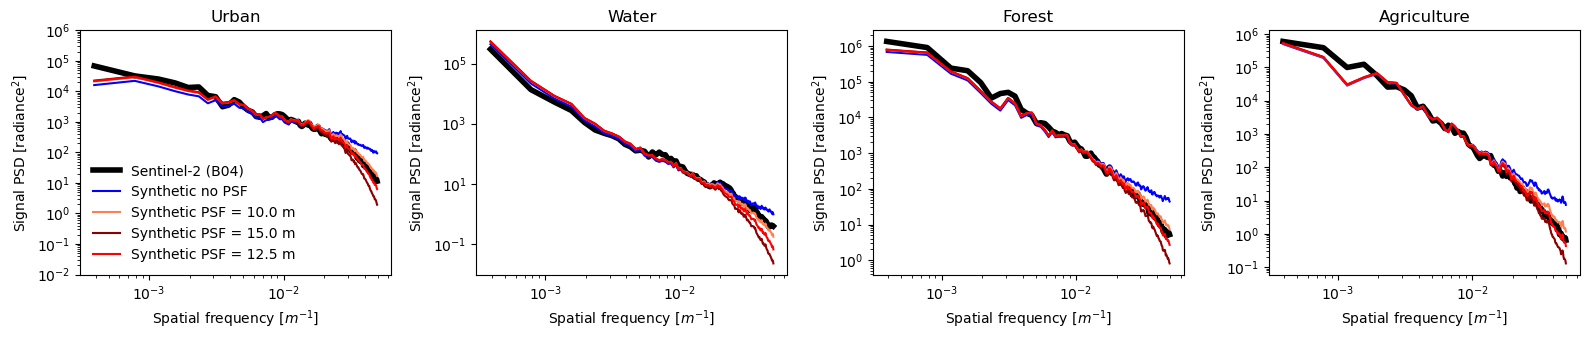

In [26]:
tab=[FWHM*0.8,FWHM*1.2,FWHM]
colortab=['coral','darkred','red']
fig=plt.figure(figsize=(16,3.5))
for c, scene in enumerate(['urban', 'water', 'forest', 'agriculture']):
    for k in range(len(tab)):
        fwhm_m = tab[k]
        prod = build_synthetic_detector_products(scene, fwhm_m=fwhm_m, force=True)
        s2_data, _, _, _ = load_scene_patch(scene)
        k_n, p_no_psf = psd1d_numpy(prod['utm_ref_no_psf'])
        k_n, p_psf = psd1d_numpy(prod['utm_det_psf'])
        k_n, p_data = psd1d_numpy(s2_data)
        ratio=np.mean(p_data[10:50]*p_psf[10:50])/np.mean(p_psf[10:50]**2)
        plt.subplot(1,4,1+c)
        if k==0:
            plt.title(scene.capitalize())
            plt.loglog(k_n,p_data,color='black',lw=4,label='Sentinel-2 (B04)')
            plt.xlabel(r"Spatial frequency [$m^{-1}$]")
            plt.ylabel(r"Signal PSD [radiance$^2$]")
            plt.loglog(k_n,ratio*p_no_psf,color='b',label='Synthetic no PSF')
        plt.loglog(k_n,ratio*p_psf,color=colortab[k],label='Synthetic PSF = %.1f m' % fwhm_m)
        if c==0:
            plt.legend(frameon=0,fontsize=10,loc='lower left')
            plt.ylim(1e-2,1e6)
fig.tight_layout()
fig.savefig(FIG_DIR / "synthetic_vs_sentinel2.pdf", bbox_inches="tight")

## 13. Figure 2 — Synthetic detector visual comparison

Rows: ESRI no-PSF | ESRI PSF | PSF-aware estimated | Nearest | Bilinear | Bicubic.
Columns: four benchmark scenes.


[Esri latent Zarr] urban: data/esri_latent/urban__z17_n256_os4.zarr
2.5 2.5


/tmp/ipykernel_2068/2984758858.py:157: RuntimeWarning: Mean of empty slice
  hpx_ref_no_psf = np.nanmean(child_ref, axis=1).astype(np.float32)
/tmp/ipykernel_2068/2984758858.py:158: RuntimeWarning: Mean of empty slice
  hpx_det_psf    = np.nanmean(child_psf, axis=1).astype(np.float32)


(65536,) (65536,) (65536,)
(65536,) (65536,) (65536,)
[Esri latent Zarr] urban: data/esri_latent/urban__z17_n256_os4.zarr
2.5 2.5


/tmp/ipykernel_2068/2984758858.py:157: RuntimeWarning: Mean of empty slice
  hpx_ref_no_psf = np.nanmean(child_ref, axis=1).astype(np.float32)
/tmp/ipykernel_2068/2984758858.py:158: RuntimeWarning: Mean of empty slice
  hpx_det_psf    = np.nanmean(child_psf, axis=1).astype(np.float32)


[PSFResampler] area not provided: auto-estimated from shared-latitude-ring grid structure.
Itt 0 : 2.384e+10
Itt 4 : 1.32e+09
Itt 8 : 1.939e+08
Itt 12 : 1.129e+06
Final Itt 13 : 4.868e+05
(175033,) (175033,) (175033,)
(175033,) (175033,) (175033,)
(175033,) (175033,) (175033,)
(175033,) (175033,) (175033,)
[Esri latent Zarr] water: data/esri_latent/water__z17_n256_os4.zarr
2.5 2.5


...

[PSFResampler] area not provided: auto-estimated from shared-latitude-ring grid structure.
Itt 0 : 7.084e+09
Itt 4 : 4.067e+07
Itt 8 : 9.706e+04
Itt 12 : 6.148e+04
Final Itt 13 : 3.464e+04
(175049,) (175049,) (175049,)
(175049,) (175049,) (175049,)
(175049,) (175049,) (175049,)
(175049,) (175049,) (175049,)
[Esri latent Zarr] agriculture: data/esri_latent/agriculture__z17_n256_os4.zarr
2.5 2.5


/tmp/ipykernel_2068/2984758858.py:157: RuntimeWarning: Mean of empty slice
  hpx_ref_no_psf = np.nanmean(child_ref, axis=1).astype(np.float32)
/tmp/ipykernel_2068/2984758858.py:158: RuntimeWarning: Mean of empty slice
  hpx_det_psf    = np.nanmean(child_psf, axis=1).astype(np.float32)


(65536,) (65536,) (65536,)
(65536,) (65536,) (65536,)
[Esri latent Zarr] agriculture: data/esri_latent/agriculture__z17_n256_os4.zarr
2.5 2.5


/tmp/ipykernel_2068/2984758858.py:157: RuntimeWarning: Mean of empty slice
  hpx_ref_no_psf = np.nanmean(child_ref, axis=1).astype(np.float32)
/tmp/ipykernel_2068/2984758858.py:158: RuntimeWarning: Mean of empty slice
  hpx_det_psf    = np.nanmean(child_psf, axis=1).astype(np.float32)


[PSFResampler] area not provided: auto-estimated from shared-latitude-ring grid structure.
Itt 0 : 8.738e+08
Itt 4 : 3.753e+05
Itt 8 : 6.536e+04
Itt 12 : 1.796e+04
Final Itt 13 : 1.282e+04
(175010,) (175010,) (175010,)
(175010,) (175010,) (175010,)
(175010,) (175010,) (175010,)
(175010,) (175010,) (175010,)
Saved.


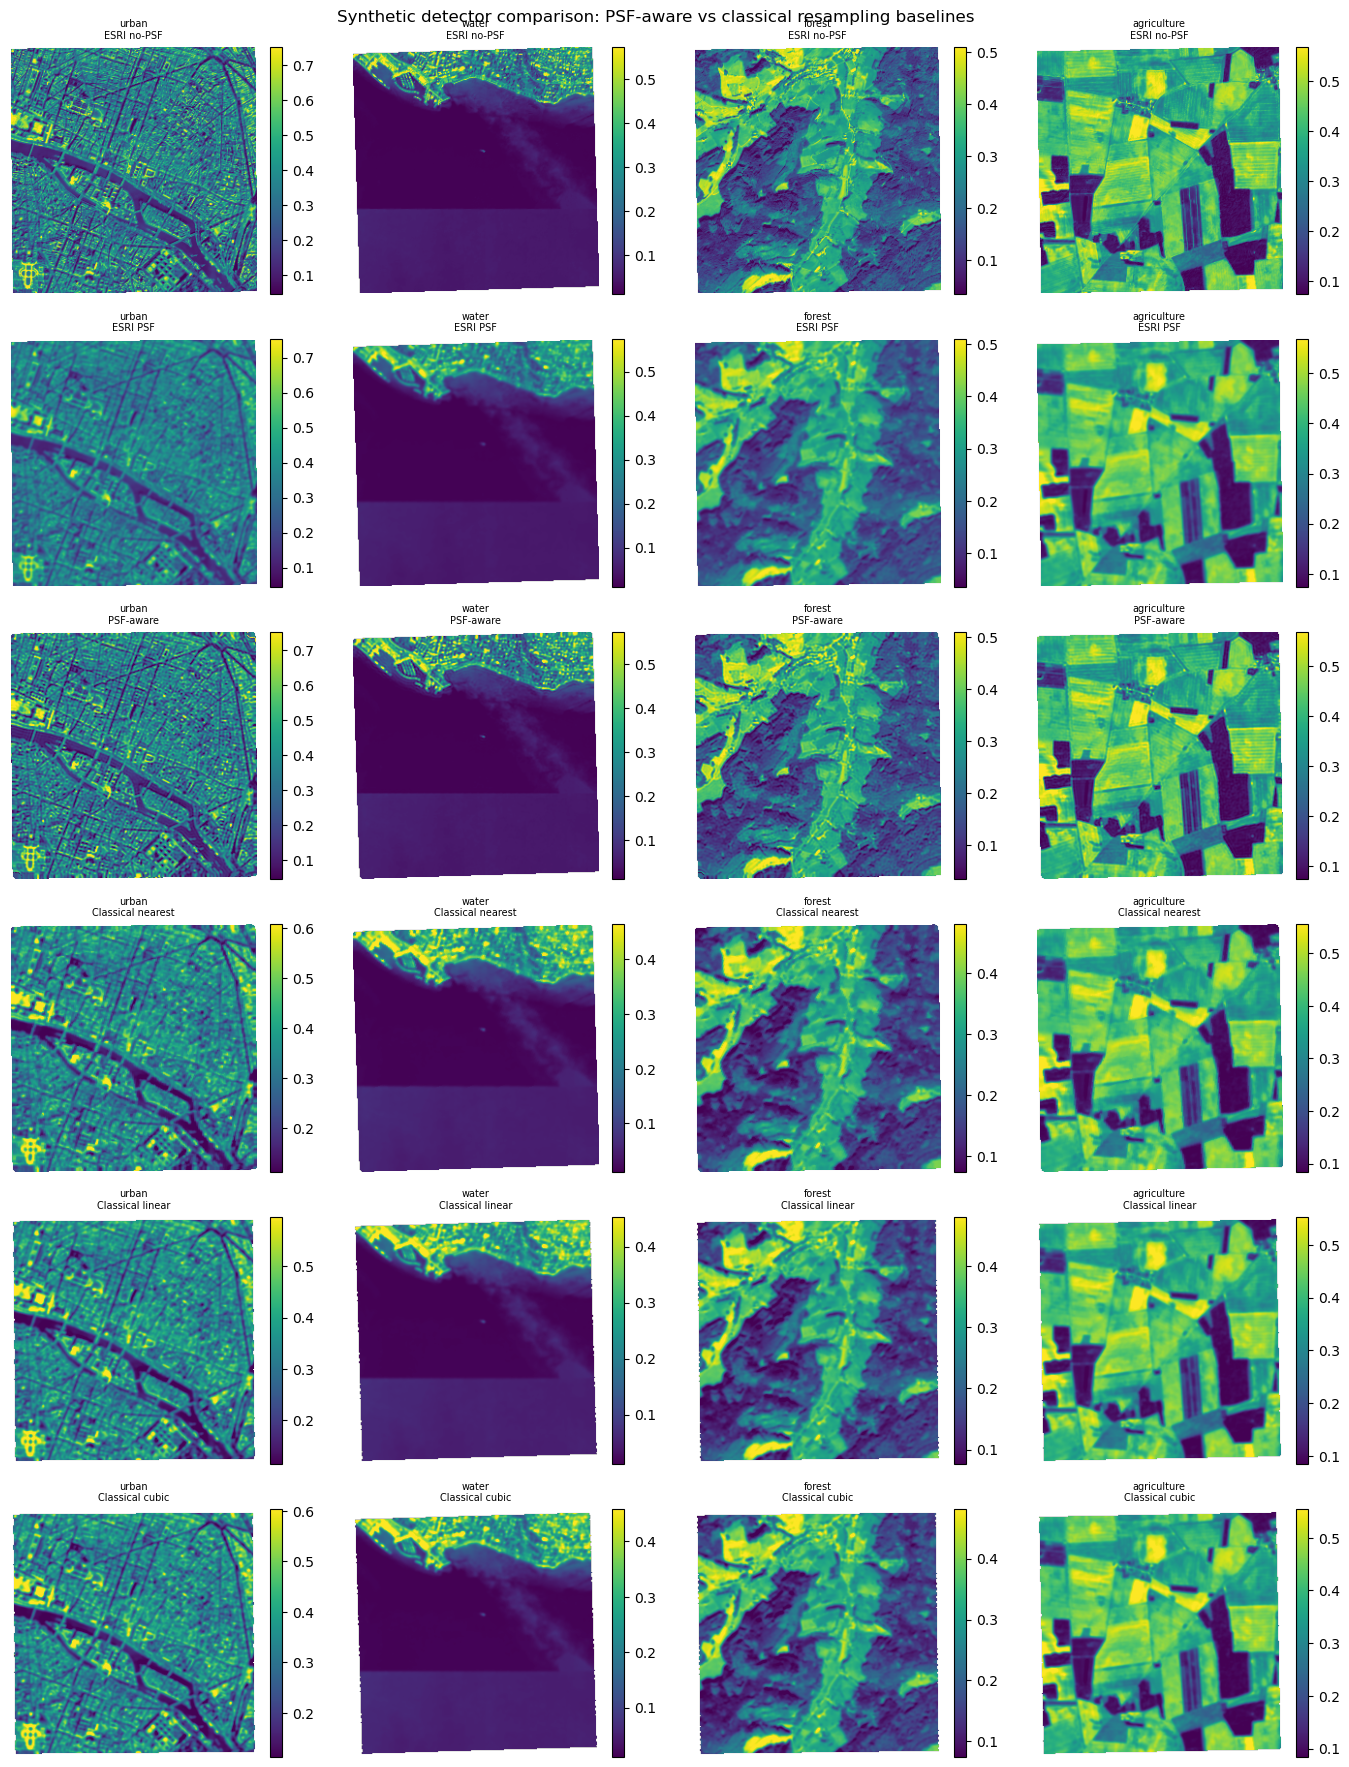

In [27]:
from healpix_geo.nested import healpix_to_lonlat

def plot_synthetic_comparison(force=True):
    scenes     = list(benchmark_coordinates.keys())
    row_keys   = ["esri_no_psf", "esri_psf", "psf_aware",
                  "nearest", "linear", "cubic"]
    row_labels = ["ESRI no-PSF (latent)", "ESRI PSF (synthetic obs.)",
                  "PSF-aware HEALPix est.",
                  "Classical nearest", "Classical bilinear", "Classical bicubic"]
    nrows = len(row_keys); ncols = len(scenes)
    fwhm_m = FWHM * 2

    fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 3 * nrows))
    if ncols == 1:
        axes = axes[:, np.newaxis]

    def show_img(ax, img, title, vmin=None, vmax=None,origin='lower'):
        if img is None:
            ax.text(0.5, 0.5, "N/A", transform=ax.transAxes,
                    ha="center", va="center")
        else:
            im = ax.imshow(img, cmap="viridis",
                           vmin=vmin if vmin is not None else np.nanpercentile(img, 1),
                           vmax=vmax if vmax is not None else np.nanpercentile(img, 99),
                           origin=origin)
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_title(title, fontsize=7)
        ax.axis("off")

    for c, scene in enumerate(scenes):
        try:
            prod = build_synthetic_detector_products(scene, fwhm_m=fwhm_m, force=force)
            esri_no_psf = prod["utm_ref_no_psf"]
            esri_psf    = prod["utm_det_psf"]
            vmin = float(np.nanpercentile(esri_no_psf, 1))
            vmax = float(np.nanpercentile(esri_no_psf, 99))

            # Common HEALPix square for visualisation
            parent_ids = prod["hpx_parent_ids"]
            nside = 2 ** HEALPIX_LEVEL
            hpx_lon, hpx_lat = sph_pix2ang(nside, parent_ids, lonlat=True, nest=True)
            img, lon, lat, da = load_scene_patch(scene)

            # Helper: render HEALPix values on a square grid
            def hpx_to_img(cell_values,cell_ids=None, npix=256,lon=None,lat=None):
                if cell_ids is not None:
                    lon,lat = healpix_to_lonlat(cell_ids,20, ellipsoid="WGS84")

                print(lon.shape,lat.shape,cell_values.shape)
                xg = np.linspace(lon.min(), lon.max(), npix)
                yg = np.linspace(lat.min(), lat.max(), npix)
                xx, yy = np.meshgrid(xg, yg)

                return griddata(np.column_stack([lon, lat]),
                        cell_values.astype(np.float64),
                        (xx, yy), method="linear")

            # Row 0: ESRI no-PSF (UTM)
            show_img(axes[0, c], hpx_to_img(esri_no_psf.flatten(),
                                            lon=lon.flatten(),
                                            lat=lat.flatten()), f"{scene}\nESRI no-PSF", vmin, vmax)
            # Row 1: ESRI PSF (UTM)
            show_img(axes[1, c], hpx_to_img(esri_psf.flatten(),
                                            lon=lon.flatten(),
                                            lat=lat.flatten()),    f"{scene}\nESRI PSF",    vmin, vmax)

            # Row 2: PSF-aware
            try:
                # fwhm_resampler=fwhm_m: match the operator to the FWHM this
                # figure actually generated the scene with (FWHM*2), not the
                # global FWHM default -- see review notes (this was a real
                # mismatch previously).
                res_psf = run_synthetic_psf_resampler_test(scene, fwhm_m=fwhm_m,
                                                            fwhm_resampler=fwhm_m, force=force)
                est_ids  = res_psf["estimated_cell_ids"]
                est_vals = res_psf["estimated_cell_data"]
                # Render on same square as reference
                show_img(axes[2, c], hpx_to_img(est_vals,cell_ids=est_ids), f"{scene}\nPSF-aware", vmin, vmax,origin='lower')
            except Exception as exc:
                show_img(axes[2, c], None, f"{scene}\nPSF-aware\n{exc}")

            # Rows 3-5: Classical
            lonh,lath = healpix_to_lonlat(est_ids,20) #, ellipsoid="WGS84")
            for r_off, method in enumerate(["nearest", "linear", "cubic"]):
                row = 3 + r_off
                try:
                    res_cl = griddata( np.column_stack([lon.flatten(), lat.flatten()]),
                                esri_psf.astype(np.float64).flatten(),
                                (lonh, lath), method=method)
                    img = hpx_to_img(res_cl,cell_ids=est_ids)
                    vmin = float(np.nanpercentile(img, 1))
                    vmax = float(np.nanpercentile(img, 99))
                    show_img(axes[row, c],
                             img,
                             f"{scene}\nClassical {method}", vmin, vmax,origin='lower')
                except Exception as exc:
                    show_img(axes[row, c], None, f"{scene}\n{method}\n{exc}")

        except Exception as exc:
            for r in range(nrows):
                axes[r, c].text(0.5, 0.5, f"Error:\n{exc}",
                                transform=axes[r, c].transAxes,
                                ha="center", va="center", fontsize=7)

    for r, label in enumerate(row_labels):
        axes[r, 0].set_ylabel(label, fontsize=8, rotation=90, labelpad=5)

    fig.suptitle("Synthetic detector comparison: PSF-aware vs classical resampling baselines",
                 fontsize=12)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "fig2_synthetic_comparison_all_methods.pdf", bbox_inches="tight")
    print("Saved.")
    return fig

fig_synthetic = plot_synthetic_comparison()  # force=True by default now -- see review notes: this figure previously (silently) reused a stale/broken cache from before the ring_search_max fix
plt.show()


### Figure — Synthetic detector PSD: all methods

[Esri latent Zarr] urban: data/esri_latent/urban__z17_n256_os4.zarr
2.5 2.5


/tmp/ipykernel_2068/2984758858.py:157: RuntimeWarning: Mean of empty slice
  hpx_ref_no_psf = np.nanmean(child_ref, axis=1).astype(np.float32)
/tmp/ipykernel_2068/2984758858.py:158: RuntimeWarning: Mean of empty slice
  hpx_det_psf    = np.nanmean(child_psf, axis=1).astype(np.float32)


[Esri latent Zarr] urban: data/esri_latent/urban__z17_n256_os4.zarr
2.5 2.5


/tmp/ipykernel_2068/2984758858.py:157: RuntimeWarning: Mean of empty slice
  hpx_ref_no_psf = np.nanmean(child_ref, axis=1).astype(np.float32)
/tmp/ipykernel_2068/2984758858.py:158: RuntimeWarning: Mean of empty slice
  hpx_det_psf    = np.nanmean(child_psf, axis=1).astype(np.float32)


[PSFResampler] area not provided: auto-estimated from shared-latitude-ring grid structure.
Itt 0 : 2.384e+10
Itt 4 : 1.32e+09
Itt 8 : 1.939e+08
Itt 12 : 1.129e+06
Itt 16 : 7.754e+04
Itt 20 : 6.619e+04
Itt 24 : 3.704e+04
Itt 28 : 1.533e+04
Itt 32 : 7152
Itt 36 : 5686
Itt 40 : 2914
Itt 44 : 1295
Itt 48 : 1058
Itt 52 : 522.8
Itt 56 : 291.9
Itt 60 : 174.1
Itt 64 : 120.4
Itt 68 : 54.55
Itt 72 : 39.3
Itt 76 : 24.89
Itt 80 : 13.02
Itt 84 : 8.258
Itt 88 : 5.522
Itt 92 : 3.26
Itt 96 : 1.761
Final Itt 99 : 1.434
(256, 256)
[[0.20755508 0.31544497 0.45468152 ... 0.32772693 0.36669256 0.37745589]
 [0.25455516 0.38610389 0.52570239 ... 0.36796667 0.44007005 0.47537138]
 [0.33198736 0.47768217 0.60433497 ... 0.44879377 0.50708582 0.53711665]
 ...
 [0.17606397 0.1715862  0.17719854 ... 0.16691361 0.16317849 0.16050662]
 [0.18714676 0.18478275 0.19183544 ... 0.1645692  0.19601028 0.20755166]
 [0.21681303 0.21447493 0.22128803 ... 0.20116621 0.2602937  0.29242519]]
[Esri latent Zarr] urban: data/esri_l

/tmp/ipykernel_2068/2984758858.py:157: RuntimeWarning: Mean of empty slice
  hpx_ref_no_psf = np.nanmean(child_ref, axis=1).astype(np.float32)
/tmp/ipykernel_2068/2984758858.py:158: RuntimeWarning: Mean of empty slice
  hpx_det_psf    = np.nanmean(child_psf, axis=1).astype(np.float32)


[Esri latent Zarr] urban: data/esri_latent/urban__z17_n256_os4.zarr
2.5 2.5


/tmp/ipykernel_2068/2984758858.py:157: RuntimeWarning: Mean of empty slice
  hpx_ref_no_psf = np.nanmean(child_ref, axis=1).astype(np.float32)
/tmp/ipykernel_2068/2984758858.py:158: RuntimeWarning: Mean of empty slice
  hpx_det_psf    = np.nanmean(child_psf, axis=1).astype(np.float32)


[Esri latent Zarr] urban: data/esri_latent/urban__z17_n256_os4.zarr
2.5 2.5


/tmp/ipykernel_2068/2984758858.py:157: RuntimeWarning: Mean of empty slice
  hpx_ref_no_psf = np.nanmean(child_ref, axis=1).astype(np.float32)
/tmp/ipykernel_2068/2984758858.py:158: RuntimeWarning: Mean of empty slice
  hpx_det_psf    = np.nanmean(child_psf, axis=1).astype(np.float32)


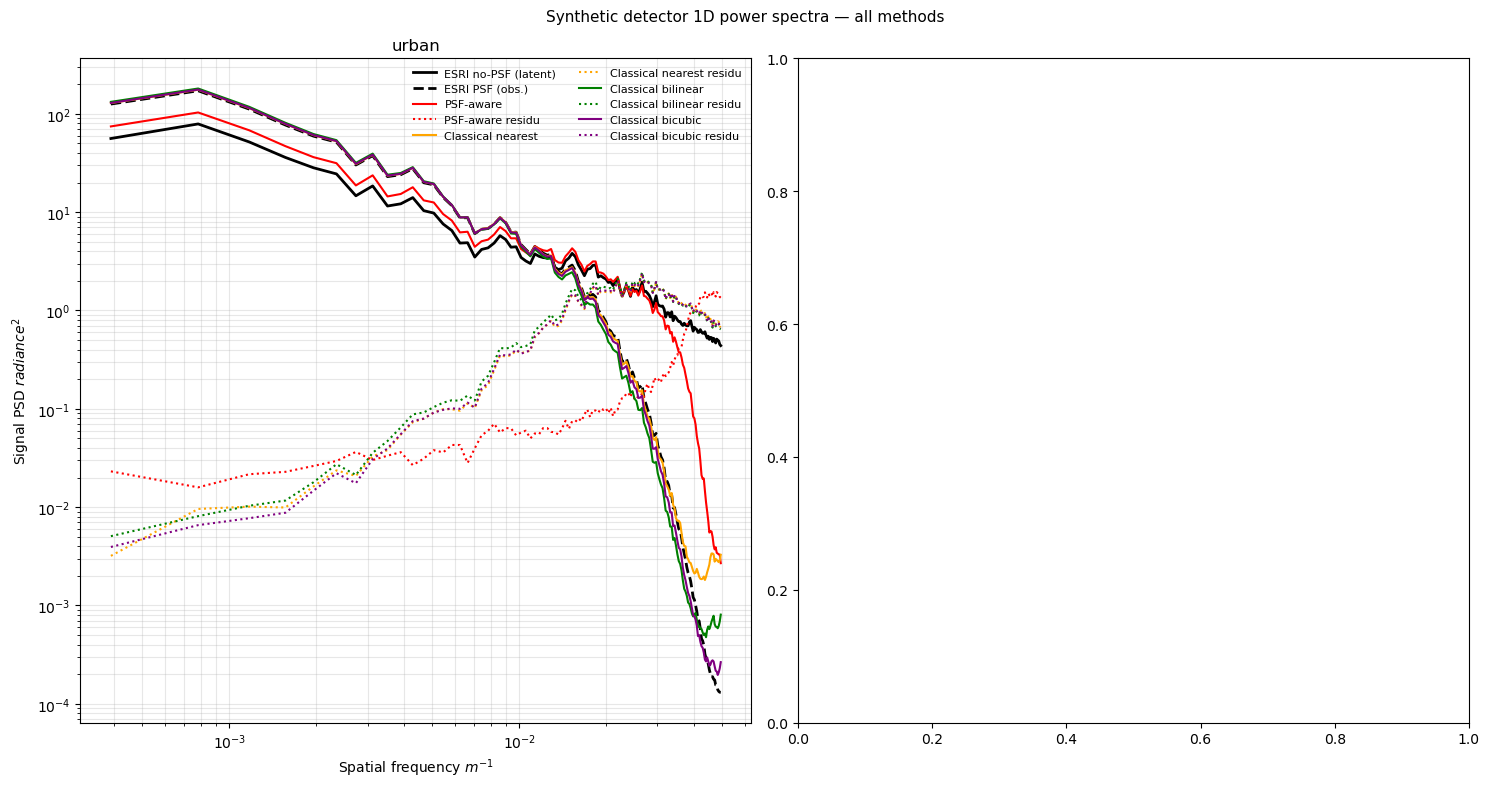

In [28]:
def plot_synthetic_psd(force=True):
    scenes   = list(benchmark_coordinates.keys())
    fwhm_m   = FWHM * 2
    methods  = ["psf_aware", "nearest", "linear", "cubic"]
    labels   = ["PSF-aware", "Classical nearest", "Classical bilinear", "Classical bicubic"]
    colors   = ["red", "orange", "green", "purple"]

    fig, axes = plt.subplots(1, 2, figsize=(15, 8))
    if len(scenes) == 1:
        axes = [axes]

    for ax, scene in zip(axes[0:1], scenes[0:1]):
        prod = build_synthetic_detector_products(scene, fwhm_m=fwhm_m, force=force)
        npix=prod["utm_ref_no_psf"].shape[0]
        nu=(np.arange(npix//2-1)+1)/(6.3*npix/2)
        regul=1/(np.pi*npix//2)
        #
        # plots
        #

        # PSF-aware
        try:
            # fwhm_resampler=fwhm_m: match the operator to this figure's own
            # generation FWHM (FWHM*2 here) -- see review notes.
            res = run_synthetic_psf_resampler_test(scene, fwhm_m=fwhm_m,lam=LAMBDA,max_iter=100,
                                                    fwhm_resampler=fwhm_m, force=force)
            parent_ids = res['aligned_no_psf_cell_ids']
            idx = np.where(np.isfinite(res["aligned_psf_reference"]))
            
            nside = 2 ** HEALPIX_LEVEL
            hpx_lon, hpx_lat = sph_pix2ang(nside, parent_ids[idx], lonlat=True, nest=True)
            _, _, _, da = load_scene_patch(scene)
            t_fwd = pyproj.Transformer.from_crs(4326, _crs_of(da), always_xy=True)
            hpx_x, hpx_y = t_fwd.transform(hpx_lon, hpx_lat)
            x0, y0 = get_utm_axes(da)

            # align estimated values to parent_ids order
            est_df = pd.DataFrame({"cell_id": res["aligned_no_psf_cell_ids"],
                                   "val": res["aligned_no_psf_estimate"]})
            ref_df = pd.DataFrame({"cell_id": parent_ids})
            merged = ref_df.merge(est_df, on="cell_id", how="left")
            hpx_vals = merged["val"].values

            xx, yy = np.meshgrid(x0, y0)
            img_est = griddata(np.column_stack([hpx_x, hpx_y]), hpx_vals[idx],
                               (xx, yy), method="linear")
            if np.any(~np.isfinite(img_est)):
                img_nn = griddata(np.column_stack([hpx_x, hpx_y]), hpx_vals[idx],
                                  (xx, yy), method="nearest")
                img_est = np.where(np.isfinite(img_est), img_est, img_nn)
        
            img_residu=  griddata(np.column_stack([hpx_x, hpx_y]), res["aligned_no_psf_estimate"][idx] - res["aligned_no_psf_reference"][idx],
                               (xx, yy), method="cubic")
            img_no_psf=  griddata(np.column_stack([hpx_x, hpx_y]), res["aligned_no_psf_reference"][idx],
                               (xx, yy), method="cubic")
            img_psf=  griddata(np.column_stack([hpx_x, hpx_y]), res["aligned_psf_reference"][idx],
                               (xx, yy), method="cubic")
            print(img_psf.shape)
            print(img_psf)
            k_noP, p_noP = psd1d_numpy(img_no_psf)
            k_psf, p_psf = psd1d_numpy(img_psf)
            k_e, p_e        = psd1d_numpy(img_est)
            k_e, p_e_residu = psd1d_numpy(img_residu)
            #
            # plots
            #
            ax.loglog(k_noP, p_noP*regul, "k-",  lw=2, label="ESRI no-PSF (latent)")
            ax.loglog(k_psf, p_psf*regul, "k--", lw=2, label="ESRI PSF (obs.)")
            ax.loglog(k_e, p_e*regul, color="red", label="PSF-aware")
            ax.loglog(k_e, p_e_residu*regul, ':',color="red", label="PSF-aware residu")
            
        except Exception as exc:
            print(f"[WARN] PSF-aware PSD {scene}: {exc}")

        # Classical
        for method, label, color in zip(["nearest", "linear", "cubic"],
                                        ["Classical nearest", "Classical bilinear", "Classical bicubic"],
                                        ["orange", "green", "purple"]):
            try:
                res_cl = run_classical_synthetic_test(scene, method=method,
                                                       fwhm_m=fwhm_m, force=force)
                hpx_vals_cl = res_cl["estimated_cell_data"]
                img_cl = griddata(np.column_stack([hpx_x, hpx_y]), hpx_vals_cl[idx],
                                  (xx, yy), method="linear")
                if np.any(~np.isfinite(img_cl)):
                    img_cl_nn = griddata(np.column_stack([hpx_x, hpx_y]), hpx_vals_cl[idx],
                                         (xx, yy), method="nearest")
                    img_cl = np.where(np.isfinite(img_cl), img_cl, img_cl_nn)
                k_cl, p_cl        = psd1d_numpy(img_cl) 
                k_cl, p_cl_residu = psd1d_numpy(img_cl-prod["utm_ref_no_psf"]) 
                #
                # plots
                #
                ax.loglog(k_cl, p_cl*regul, color=color, label=label)
                ax.loglog(k_cl, abs(p_cl_residu*regul),':', color=color, label=label+" residu")
                
            except Exception as exc:
                print(f"[WARN] Classical {method} PSD {scene}: {exc}")
        ax.set_title(scene)
        ax.set_xlabel("Spatial frequency $m^{-1}$")
        ax.set_ylabel("Signal PSD $radiance^2$")
        if scene=='urban':
            ax.legend(fontsize=8,frameon=0,ncol=2)
        ax.grid(True, which="both", alpha=0.3)

    fig.suptitle("Synthetic detector 1D power spectra — all methods", fontsize=11)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "synthetic_psd_all_methods.pdf", bbox_inches="tight")
    return fig

fig_psd_synth = plot_synthetic_psd()  # force=True by default now -- same stale-cache issue as plot_synthetic_comparison above


In [29]:
# Spectral diagnostics, urban scene (feeds figures/resample-test.pdf, cited
# in the paper). Computes local 2-D power spectra / spectral residuals for
# the matched PSF-aware estimate, the +/-50% mis-specified arms,
# Richardson-Lucy, and the classical nearest/bilinear/bicubic baselines, so
# they can all be plotted together in the next cell.
scene    = 'urban'
fwhm_m   = FWHM
prod     = build_synthetic_detector_products(scene, fwhm_m=fwhm_m, force=True)
res      = run_synthetic_psf_resampler_test(scene, fwhm_m=fwhm_m, fwhm_resampler=fwhm_m,
                                             force=True, max_iter=MAX_ITER, lam=LAMBDA)
res_rl   = run_richardson_lucy_synthetic_test(scene, fwhm_m=fwhm_m, force=True)
res_tik  = run_tikhonov_bicubic_ablation(scene, fwhm_m=fwhm_m, force=True)  # "fair" ablation (review point 5)
res_wide = run_synthetic_psf_resampler_test(
                scene, fwhm_m=fwhm_m, fwhm_resampler=FWHM_PSF_AWARE_WIDE,
                lam=LAMBDA_PSF_AWARE_WIDE, force=True)
res_narrow = run_synthetic_psf_resampler_test(
                scene, fwhm_m=fwhm_m, fwhm_resampler=FWHM_PSF_AWARE_NARROW,
                lam=LAMBDA_PSF_AWARE_NARROW, force=True)

img, _, _, _ = load_scene_patch(scene)

nu1, cl0 = heal_local_fft(prod['lon'], prod['lat'], res['aligned_no_psf_cell_ids'],
                          res['aligned_no_psf_reference'], data=img * 2)
nu1, cl1 = heal_local_fft(prod['lon'], prod['lat'], res['aligned_no_psf_cell_ids'],
                          res['aligned_no_psf_reference'])
nu2, cl2 = heal_local_fft(prod['lon'], prod['lat'], res['aligned_no_psf_cell_ids'],
                          res['aligned_psf_reference'])
nu2, cl3 = heal_local_fft(prod['lon'], prod['lat'], res['aligned_no_psf_cell_ids'],
                          res['aligned_psf_estimate'])
nu2, cl3rl = heal_local_fft(prod['lon'], prod['lat'], res_rl['estimated_cell_ids'],
                            res_rl['aligned_psf_estimate'])
nu2, cl3tik = heal_local_fft(prod['lon'], prod['lat'], res_tik['estimated_cell_ids'],
                             res_tik['aligned_psf_estimate'])
nu2, cl3w = heal_local_fft(prod['lon'], prod['lat'], res_wide['aligned_no_psf_cell_ids'],
                           res_wide['aligned_psf_estimate'])
nu2, cl3n = heal_local_fft(prod['lon'], prod['lat'], res_narrow['aligned_no_psf_cell_ids'],
                           res_narrow['aligned_psf_estimate'])

cl4    = np.abs(cl3    - cl1)
cl4rl  = np.abs(cl3rl  - cl1)
cl4tik = np.abs(cl3tik - cl1)
cl4w   = np.abs(cl3w   - cl1)
cl4n   = np.abs(cl3n   - cl1)

cl5 = np.abs(cl2 - cl1)

nu2, cl6 = heal_local_fft(prod['lon'], prod['lat'], res['aligned_no_psf_cell_ids'],
                          prod['utm_det_psf'], interpol='nearest')
nu2, cl7 = heal_local_fft(prod['lon'], prod['lat'], res['aligned_no_psf_cell_ids'],
                          prod['utm_det_psf'], interpol='linear')
nu2, cl8 = heal_local_fft(prod['lon'], prod['lat'], res['aligned_no_psf_cell_ids'],
                          prod['utm_det_psf'], interpol='cubic')

cl6b = np.abs(cl6 - cl1)
cl7b = np.abs(cl7 - cl1)
cl8b = np.abs(cl8 - cl1)

[Esri latent Zarr] urban: data/esri_latent/urban__z17_n256_os4.zarr
2.5 2.5


/tmp/ipykernel_2068/2984758858.py:157: RuntimeWarning: Mean of empty slice
  hpx_ref_no_psf = np.nanmean(child_ref, axis=1).astype(np.float32)
/tmp/ipykernel_2068/2984758858.py:158: RuntimeWarning: Mean of empty slice
  hpx_det_psf    = np.nanmean(child_psf, axis=1).astype(np.float32)


[Esri latent Zarr] urban: data/esri_latent/urban__z17_n256_os4.zarr
2.5 2.5


/tmp/ipykernel_2068/2984758858.py:157: RuntimeWarning: Mean of empty slice
  hpx_ref_no_psf = np.nanmean(child_ref, axis=1).astype(np.float32)
/tmp/ipykernel_2068/2984758858.py:158: RuntimeWarning: Mean of empty slice
  hpx_det_psf    = np.nanmean(child_psf, axis=1).astype(np.float32)


[PSFResampler] area not provided: auto-estimated from shared-latitude-ring grid structure.
Itt 0 : 8.481e+09
Itt 4 : 4.033e+05
Itt 8 : 5.196e+04
Itt 12 : 4429
Final Itt 13 : 2792
[Esri latent Zarr] urban: data/esri_latent/urban__z17_n256_os4.zarr
2.5 2.5


...

[Esri latent Zarr] urban: data/esri_latent/urban__z17_n256_os4.zarr
2.5 2.5


/tmp/ipykernel_2068/2984758858.py:157: RuntimeWarning: Mean of empty slice
  hpx_ref_no_psf = np.nanmean(child_ref, axis=1).astype(np.float32)
/tmp/ipykernel_2068/2984758858.py:158: RuntimeWarning: Mean of empty slice
  hpx_det_psf    = np.nanmean(child_psf, axis=1).astype(np.float32)


[PSFResampler] area not provided: auto-estimated from shared-latitude-ring grid structure.
Itt 0 : 6.454e+10
Itt 4 : 1.135e+09
Itt 8 : 2.717e+06
Itt 12 : 1.961e+06
Final Itt 13 : 8.568e+05
[Esri latent Zarr] urban: data/esri_latent/urban__z17_n256_os4.zarr
2.5 2.5


/tmp/ipykernel_2068/2984758858.py:157: RuntimeWarning: Mean of empty slice
  hpx_ref_no_psf = np.nanmean(child_ref, axis=1).astype(np.float32)
/tmp/ipykernel_2068/2984758858.py:158: RuntimeWarning: Mean of empty slice
  hpx_det_psf    = np.nanmean(child_psf, axis=1).astype(np.float32)


[PSFResampler] area not provided: auto-estimated from shared-latitude-ring grid structure.
Itt 0 : 1.679e+06
Itt 4 : 7157
Itt 8 : 124.7
Itt 12 : 52.79
Final Itt 13 : 70.25


[Esri latent Zarr] urban: data/esri_latent/urban__z17_n256_os4.zarr
2.5 2.5


/tmp/ipykernel_2068/2984758858.py:157: RuntimeWarning: Mean of empty slice
  hpx_ref_no_psf = np.nanmean(child_ref, axis=1).astype(np.float32)
/tmp/ipykernel_2068/2984758858.py:158: RuntimeWarning: Mean of empty slice
  hpx_det_psf    = np.nanmean(child_psf, axis=1).astype(np.float32)


[Esri latent Zarr] urban: data/esri_latent/urban__z17_n256_os4.zarr
2.5 2.5


/tmp/ipykernel_2068/2984758858.py:157: RuntimeWarning: Mean of empty slice
  hpx_ref_no_psf = np.nanmean(child_ref, axis=1).astype(np.float32)
/tmp/ipykernel_2068/2984758858.py:158: RuntimeWarning: Mean of empty slice
  hpx_det_psf    = np.nanmean(child_psf, axis=1).astype(np.float32)


[PSFResampler] area not provided: auto-estimated from shared-latitude-ring grid structure.
Itt 0 : 8.481e+09
Itt 4 : 4.033e+05
Itt 8 : 5.196e+04
Itt 12 : 4429
Final Itt 13 : 2792
[Esri latent Zarr] urban: data/esri_latent/urban__z17_n256_os4.zarr
2.5 2.5


...

/tmp/ipykernel_2068/2984758858.py:157: RuntimeWarning: Mean of empty slice
  hpx_ref_no_psf = np.nanmean(child_ref, axis=1).astype(np.float32)
/tmp/ipykernel_2068/2984758858.py:158: RuntimeWarning: Mean of empty slice
  hpx_det_psf    = np.nanmean(child_psf, axis=1).astype(np.float32)


[PSFResampler] area not provided: auto-estimated from shared-latitude-ring grid structure.
Itt 0 : 6.454e+10
Itt 4 : 1.135e+09
Itt 8 : 2.717e+06
Itt 12 : 1.961e+06
Final Itt 13 : 8.568e+05
[Esri latent Zarr] urban: data/esri_latent/urban__z17_n256_os4.zarr
2.5 2.5


/tmp/ipykernel_2068/2984758858.py:157: RuntimeWarning: Mean of empty slice
  hpx_ref_no_psf = np.nanmean(child_ref, axis=1).astype(np.float32)
/tmp/ipykernel_2068/2984758858.py:158: RuntimeWarning: Mean of empty slice
  hpx_det_psf    = np.nanmean(child_psf, axis=1).astype(np.float32)


[PSFResampler] area not provided: auto-estimated from shared-latitude-ring grid structure.
Itt 0 : 1.679e+06
Itt 4 : 7157
Itt 8 : 124.7
Itt 12 : 52.79
Final Itt 13 : 70.25


/tmp/ipykernel_2068/1607346377.py:131: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  fig.tight_layout()


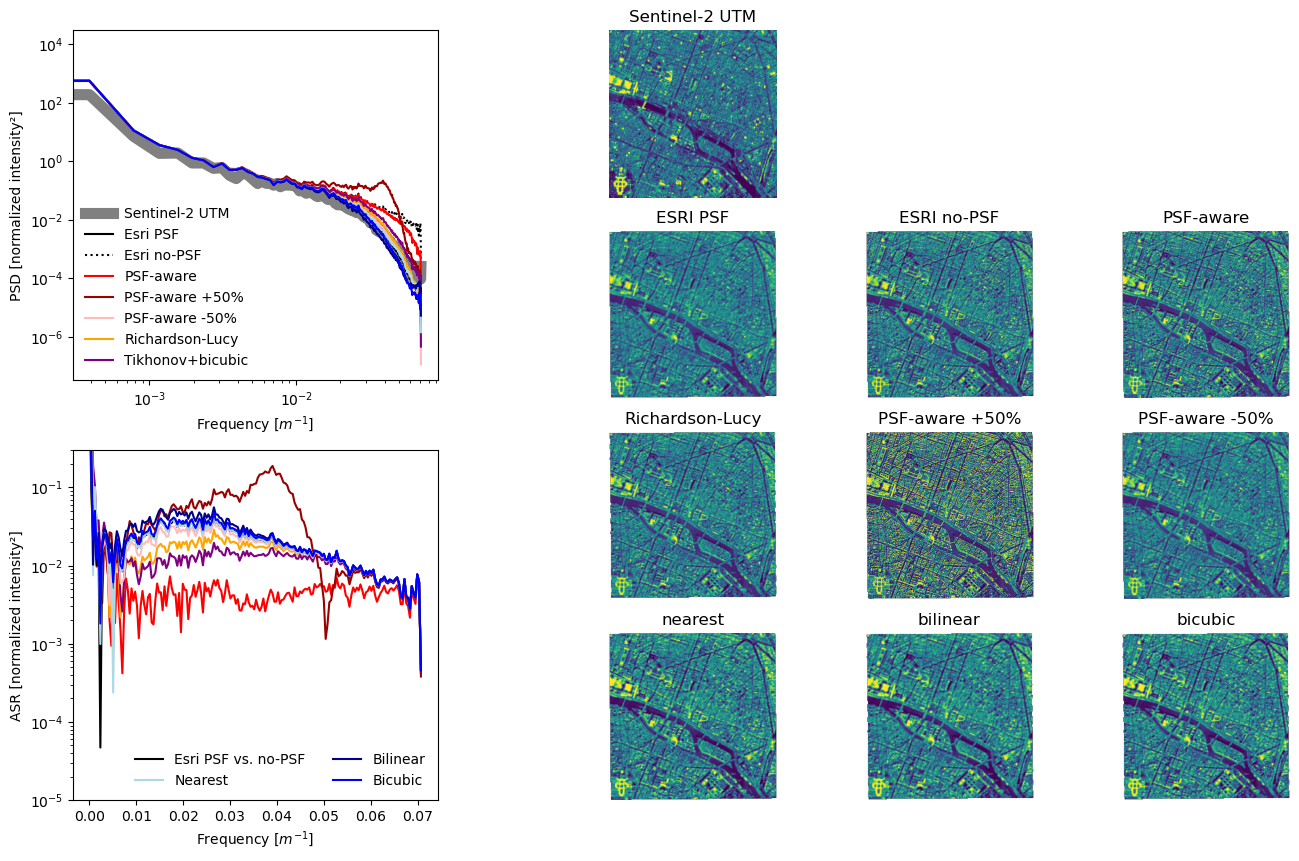

In [30]:
# Figure cited in the paper as figures/resample-test.pdf: spatial panels
# (Sentinel-2, ESRI no-PSF/PSF, PSF-aware matched/+50%/-50%, Richardson-Lucy,
# classical nearest/bilinear/bicubic) plus PSD and spectral-residual (ASR)
# curves for the urban scene, built from the cl0..cl8b spectra computed above.
def show_img(ax, img, title, vmin=None, vmax=None, origin='lower'):
    if img is None:
        ax.text(0.5, 0.5, "N/A", transform=ax.transAxes,
                ha="center", va="center", fontsize="large")
    else:
        im = ax.imshow(img, cmap="viridis",
                        vmin=vmin if vmin is not None else np.nanpercentile(img, 1),
                        vmax=vmax if vmax is not None else np.nanpercentile(img, 99),
                        origin=origin)
        # plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title, fontsize=12)
    ax.axis("off")


def hpx_to_img(cell_values, cell_ids=None, npix=256, lon=None, lat=None):
    if cell_ids is not None:
        lon, lat = healpix_to_lonlat(cell_ids, 20, ellipsoid="WGS84")
    xg = np.linspace(lon.min(), lon.max(), npix)
    yg = np.linspace(lat.min(), lat.max(), npix)
    xx, yy = np.meshgrid(xg, yg)
    return griddata(np.column_stack([lon, lat]),
                    cell_values.astype(np.float64),
                    (xx, yy), method="linear")


scene = 'urban'
prod = build_synthetic_detector_products(scene, fwhm_m=fwhm_m, force=True)
esri_no_psf = prod["utm_ref_no_psf"]
esri_psf    = prod["utm_det_psf"]
vmin = float(np.nanpercentile(esri_no_psf, 1))
vmax = float(np.nanpercentile(esri_no_psf, 99))

# Common HEALPix square for visualisation
parent_ids = prod["hpx_parent_ids"]
nside = 2 ** HEALPIX_LEVEL
hpx_lon, hpx_lat = sph_pix2ang(nside, parent_ids, lonlat=True, nest=True)
img, lon, lat, da = load_scene_patch(scene)

fig = plt.figure(figsize=(16, 10))

# Row 0: Sentinel-2 DATA
show_img(plt.subplot(4, 5, 3), img * 3, "Sentinel-2 UTM", vmin, vmax, origin=None)
# Row 0: ESRI no-PSF (UTM)
show_img(plt.subplot(4, 5, 9), hpx_to_img(esri_no_psf.flatten(), lon=lon.flatten(), lat=lat.flatten()),
         "ESRI no-PSF", vmin, vmax)
# Row 1: ESRI PSF (UTM)
show_img(plt.subplot(4, 5, 8), hpx_to_img(esri_psf.flatten(), lon=lon.flatten(), lat=lat.flatten()),
         "ESRI PSF", vmin, vmax)

# Row 2: PSF-aware
try:
    res_psf = run_synthetic_psf_resampler_test(scene, fwhm_m=fwhm_m, force=True, max_iter=MAX_ITER, lam=LAMBDA)
    est_ids = res_psf["estimated_cell_ids"]
    est_vals = res_psf["estimated_cell_data"]
    show_img(plt.subplot(4, 5, 10), hpx_to_img(est_vals, cell_ids=est_ids), "PSF-aware", vmin, vmax, origin='lower')

    res_rl = run_richardson_lucy_synthetic_test(scene, fwhm_m=fwhm_m, force=True)
    est_ids = res_rl["estimated_cell_ids"]
    est_vals = res_rl["estimated_cell_data"]
    show_img(plt.subplot(4, 5, 13), hpx_to_img(est_vals, cell_ids=est_ids), "Richardson-Lucy", vmin, vmax, origin='lower')

    res_wide = run_synthetic_psf_resampler_test(
                    scene, fwhm_m=fwhm_m, fwhm_resampler=FWHM_PSF_AWARE_WIDE,
                    lam=LAMBDA_PSF_AWARE_WIDE, force=True)
    est_ids = res_wide["estimated_cell_ids"]
    est_vals = res_wide["estimated_cell_data"]
    show_img(plt.subplot(4, 5, 14), hpx_to_img(est_vals, cell_ids=est_ids), "PSF-aware +50%", vmin, vmax, origin='lower')

    res_narrow = run_synthetic_psf_resampler_test(
                    scene, fwhm_m=fwhm_m, fwhm_resampler=FWHM_PSF_AWARE_NARROW,
                    lam=LAMBDA_PSF_AWARE_NARROW, force=True)
    est_ids = res_narrow["estimated_cell_ids"]
    est_vals = res_narrow["estimated_cell_data"]
    show_img(plt.subplot(4, 5, 15), hpx_to_img(est_vals, cell_ids=est_ids), "PSF-aware -50%", vmin, vmax, origin='lower')
except Exception as exc:
    show_img(plt.subplot(4, 5, 8), None, f"{scene}\nPSF-aware\n{exc}")

# Rows 3-5: Classical
lonh, lath = healpix_to_lonlat(est_ids, 20)
for r_off, method in enumerate(["nearest", "linear", "cubic"]):
    row = 3
    col = 2 + (r_off) % 3
    try:
        res_cl = griddata(np.column_stack([lon.flatten(), lat.flatten()]),
                           esri_psf.astype(np.float64).flatten(),
                           (lonh, lath), method=method)
        img_cl = hpx_to_img(res_cl, cell_ids=est_ids)
        vmin_cl = float(np.nanpercentile(img_cl, 1))
        vmax_cl = float(np.nanpercentile(img_cl, 99))
        label = 'bi' + method if method != 'nearest' else method
        show_img(plt.subplot(4, 5, 1 + row * 5 + col), img_cl, label, vmin_cl, vmax_cl, origin='lower')
    except Exception as exc:
        show_img(plt.subplot(4, 5, 1 + row * 5 + col), None, f"{method}\n{exc}")

plt.subplot(2, 3, 1)
plt.loglog(nu2, cl0, color='grey', lw=8, label='Sentinel-2 UTM')
plt.loglog(nu2, cl2, color='black', label="Esri PSF")
plt.loglog(nu2, cl1, ':', color='black', label="Esri no-PSF")
plt.loglog(nu2, cl3, color='r', label='PSF-aware')
plt.loglog(nu2, cl3w, color='#990000', label='PSF-aware +50%')
plt.loglog(nu2, cl3n, color='#FFBBBB', label='PSF-aware -50%')
plt.loglog(nu2, cl3rl, color='orange', label='Richardson-Lucy')
plt.loglog(nu2, cl3tik, color='purple', label='Tikhonov+bicubic')
plt.loglog(nu2, cl6, color='lightblue')
plt.loglog(nu2, cl7, color='darkblue')
plt.loglog(nu2, cl8, color='b')
plt.ylabel('PSD [normalized intensity²]')
plt.xlabel(r'Frequency [$m^{-1}$]')
plt.legend(frameon=0, ncols=1, loc='lower left')

plt.subplot(2, 3, 4)
plt.plot(nu2, cl4, color='r')
plt.plot(nu2, cl4rl, color='orange')
plt.plot(nu2, cl4tik, color='purple')
plt.plot(nu2, cl4w, color='#990000')
plt.plot(nu2, cl4n, color='#FFBBBB')
plt.plot(nu2, cl5, color='black', label='Esri PSF vs. no-PSF')
plt.plot(nu2, cl6b, color='lightblue', label='Nearest')
plt.plot(nu2, cl7b, color='darkblue', label='Bilinear')
plt.plot(nu2, cl8b, color='b', label='Bicubic')
plt.ylabel('ASR [normalized intensity²]')
plt.xlabel(r'Frequency [$m^{-1}$]')
plt.legend(frameon=0, ncols=2)
plt.ylim(1E-5, 3e-1)
plt.yscale('log')

fig.tight_layout()
fig.savefig(FIG_DIR / "resample-test.pdf", bbox_inches="tight")

[Esri latent Zarr] water: data/esri_latent/water__z17_n256_os4.zarr
2.5 2.5


/tmp/ipykernel_2068/2984758858.py:157: RuntimeWarning: Mean of empty slice
  hpx_ref_no_psf = np.nanmean(child_ref, axis=1).astype(np.float32)
/tmp/ipykernel_2068/2984758858.py:158: RuntimeWarning: Mean of empty slice
  hpx_det_psf    = np.nanmean(child_psf, axis=1).astype(np.float32)


[Esri latent Zarr] water: data/esri_latent/water__z17_n256_os4.zarr
2.5 2.5


/tmp/ipykernel_2068/2984758858.py:157: RuntimeWarning: Mean of empty slice
  hpx_ref_no_psf = np.nanmean(child_ref, axis=1).astype(np.float32)
/tmp/ipykernel_2068/2984758858.py:158: RuntimeWarning: Mean of empty slice
  hpx_det_psf    = np.nanmean(child_psf, axis=1).astype(np.float32)


[PSFResampler] area not provided: auto-estimated from shared-latitude-ring grid structure.
Itt 0 : 4.419e+06
Itt 4 : 4.23e+04
Itt 8 : 2977
Itt 12 : 379
Final Itt 13 : 228.3
[Esri latent Zarr] water: data/esri_latent/water__z17_n256_os4.zarr
2.5 2.5


...

[Esri latent Zarr] agriculture: data/esri_latent/agriculture__z17_n256_os4.zarr
2.5 2.5


/tmp/ipykernel_2068/2984758858.py:157: RuntimeWarning: Mean of empty slice
  hpx_ref_no_psf = np.nanmean(child_ref, axis=1).astype(np.float32)
/tmp/ipykernel_2068/2984758858.py:158: RuntimeWarning: Mean of empty slice
  hpx_det_psf    = np.nanmean(child_psf, axis=1).astype(np.float32)


[PSFResampler] area not provided: auto-estimated from shared-latitude-ring grid structure.
Itt 0 : 1.24e+08
Itt 4 : 8.297e+05
Itt 8 : 2.099e+05
Itt 12 : 8.676e+04
Final Itt 13 : 8.016e+04
[Esri latent Zarr] agriculture: data/esri_latent/agriculture__z17_n256_os4.zarr
2.5 2.5


/tmp/ipykernel_2068/2984758858.py:157: RuntimeWarning: Mean of empty slice
  hpx_ref_no_psf = np.nanmean(child_ref, axis=1).astype(np.float32)
/tmp/ipykernel_2068/2984758858.py:158: RuntimeWarning: Mean of empty slice
  hpx_det_psf    = np.nanmean(child_psf, axis=1).astype(np.float32)


[PSFResampler] area not provided: auto-estimated from shared-latitude-ring grid structure.
Itt 0 : 1.238e+04
Itt 4 : 0.788
Itt 8 : 7.913
Itt 12 : 0.4871
Final Itt 13 : 0.1753


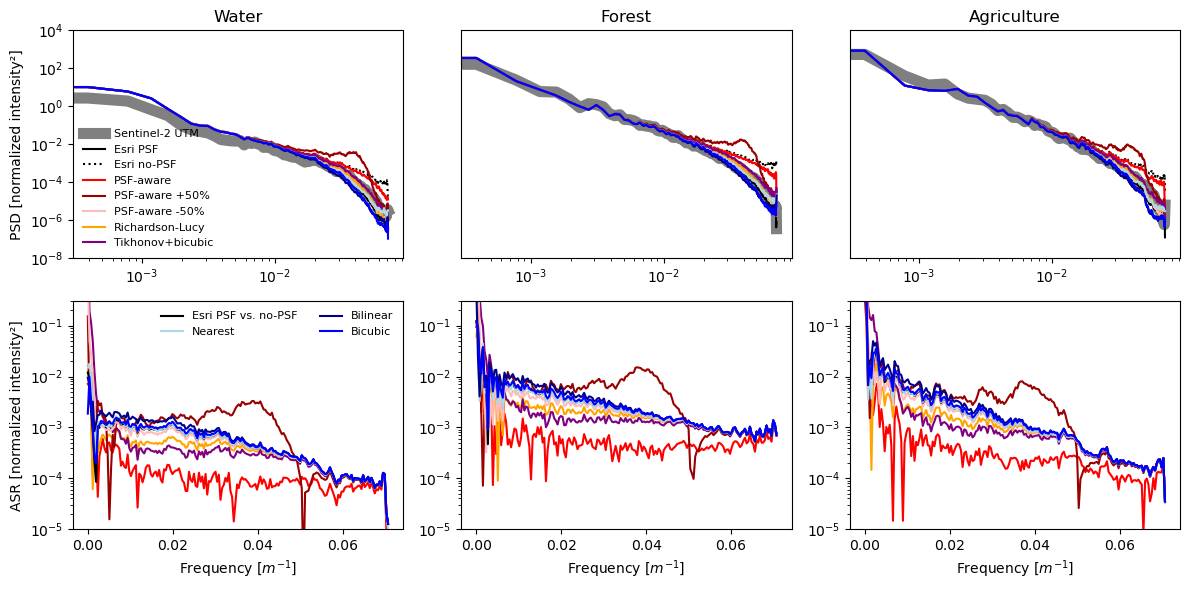

In [31]:
# Figure cited in the paper as figures/all-spectra.pdf: PSD and spectral
# residual (ASR) curves for the water, forest, and agriculture scenes
# (urban is handled separately above, in figures/resample-test.pdf).
fig2 = plt.figure(figsize=(12, 6))
for c, scene in enumerate(['water', 'forest', 'agriculture']):
    fwhm_m = FWHM
    prod = build_synthetic_detector_products(scene, fwhm_m=fwhm_m, force=True)
    res = run_synthetic_psf_resampler_test(scene, fwhm_m=fwhm_m, fwhm_resampler=fwhm_m,
                                            force=True, max_iter=MAX_ITER, lam=LAMBDA)
    res_rl = run_richardson_lucy_synthetic_test(scene, fwhm_m=fwhm_m, force=True)
    res_tik = run_tikhonov_bicubic_ablation(scene, fwhm_m=fwhm_m, force=True)  # "fair" ablation (review point 5)
    res_wide = run_synthetic_psf_resampler_test(
                    scene, fwhm_m=fwhm_m, fwhm_resampler=FWHM_PSF_AWARE_WIDE,
                    lam=LAMBDA_PSF_AWARE_WIDE, force=True)
    res_narrow = run_synthetic_psf_resampler_test(
                    scene, fwhm_m=fwhm_m, fwhm_resampler=FWHM_PSF_AWARE_NARROW,
                    lam=LAMBDA_PSF_AWARE_NARROW, force=True)
    img, _, _, _ = load_scene_patch(scene)

    nu1, cl0 = heal_local_fft(prod['lon'], prod['lat'], res['aligned_no_psf_cell_ids'],
                              res['aligned_no_psf_reference'], data=img * 2)
    nu1, cl1 = heal_local_fft(prod['lon'], prod['lat'], res['aligned_no_psf_cell_ids'],
                              res['aligned_no_psf_reference'])
    nu2, cl2 = heal_local_fft(prod['lon'], prod['lat'], res['aligned_no_psf_cell_ids'],
                              res['aligned_psf_reference'])
    nu2, cl3 = heal_local_fft(prod['lon'], prod['lat'], res['aligned_no_psf_cell_ids'],
                              res['aligned_psf_estimate'])
    nu2, cl3rl = heal_local_fft(prod['lon'], prod['lat'], res_rl['estimated_cell_ids'],
                                res_rl['aligned_psf_estimate'])
    nu2, cl3tik = heal_local_fft(prod['lon'], prod['lat'], res_tik['estimated_cell_ids'],
                                 res_tik['aligned_psf_estimate'])
    nu2, cl3w = heal_local_fft(prod['lon'], prod['lat'], res_wide['aligned_no_psf_cell_ids'],
                               res_wide['aligned_psf_estimate'])
    nu2, cl3n = heal_local_fft(prod['lon'], prod['lat'], res_narrow['aligned_no_psf_cell_ids'],
                               res_narrow['aligned_psf_estimate'])

    cl4    = np.abs(cl3    - cl1)
    cl4rl  = np.abs(cl3rl  - cl1)
    cl4tik = np.abs(cl3tik - cl1)
    cl4w   = np.abs(cl3w   - cl1)
    cl4n   = np.abs(cl3n   - cl1)

    cl5 = np.abs(cl2 - cl1)

    nu2, cl6 = heal_local_fft(prod['lon'], prod['lat'], res['aligned_no_psf_cell_ids'],
                              prod['utm_det_psf'], interpol='nearest')
    nu2, cl7 = heal_local_fft(prod['lon'], prod['lat'], res['aligned_no_psf_cell_ids'],
                              prod['utm_det_psf'], interpol='linear')
    nu2, cl8 = heal_local_fft(prod['lon'], prod['lat'], res['aligned_no_psf_cell_ids'],
                              prod['utm_det_psf'], interpol='cubic')

    cl6b = np.abs(cl6 - cl1)
    cl7b = np.abs(cl7 - cl1)
    cl8b = np.abs(cl8 - cl1)

    plt.subplot(2, 3, 1 + c)
    plt.title(scene.capitalize())
    plt.loglog(nu2, cl0, color='grey', lw=8, label='Sentinel-2 UTM')
    plt.loglog(nu2, cl2, color='black', label="Esri PSF")
    plt.loglog(nu2, cl1, ':', color='black', label="Esri no-PSF")
    plt.loglog(nu2, cl3, color='r', label='PSF-aware')
    plt.loglog(nu2, cl3w, color='#990000', label='PSF-aware +50%')
    plt.loglog(nu2, cl3n, color='#FFBBBB', label='PSF-aware -50%')
    plt.loglog(nu2, cl3rl, color='orange', label='Richardson-Lucy')
    plt.loglog(nu2, cl3tik, color='purple', label='Tikhonov+bicubic')
    plt.loglog(nu2, cl6, color='lightblue')
    plt.loglog(nu2, cl7, color='darkblue')
    plt.loglog(nu2, cl8, color='b')
    if c == 0:
        plt.ylabel('PSD [normalized intensity²]')
    else:
        plt.yticks([])
    plt.ylim(1E-8, 1E4)
    if c == 0:
        plt.legend(frameon=0, ncols=1, loc='lower left', fontsize=8)

    plt.subplot(2, 3, 4 + c)
    plt.plot(nu2, cl4, color='r')
    plt.plot(nu2, cl4rl, color='orange')
    plt.plot(nu2, cl4tik, color='purple')
    plt.plot(nu2, cl4w, color='#990000')
    plt.plot(nu2, cl4n, color='#FFBBBB')
    plt.plot(nu2, cl5, color='black', label='Esri PSF vs. no-PSF')
    plt.plot(nu2, cl6b, color='lightblue', label='Nearest')
    plt.plot(nu2, cl7b, color='darkblue', label='Bilinear')
    plt.plot(nu2, cl8b, color='b', label='Bicubic')
    plt.xlabel(r'Frequency [$m^{-1}$]')
    if c == 0:
        plt.ylabel('ASR [normalized intensity²]')
        plt.legend(frameon=0, ncols=2, fontsize=8)
    else:
        plt.yticks([])
    plt.ylim(1E-5, 3e-1)
    plt.yscale('log')

fig2.tight_layout()
fig2.savefig(FIG_DIR / "all-spectra.pdf", bbox_inches="tight")

## 14. Figure 4 — UTM PSD: Sentinel-2 vs ESRI synthetic

## 15. Runtime comparison

In [32]:
def collect_runtime_table(force=False):
    rows = []
    for scene in benchmark_coordinates:
        # PSF-aware
        try:
            t0 = time.time()
            psf = psf_resample_scene(scene, force=True)
            t_psf = time.time() - t0
            rows.append({"scene": scene, "method": "psf_aware",
                         "total_s": t_psf,
                         "build_s": float(psf.get("build_time", np.nan)),
                         "invert_s": float(psf.get("inversion_time", np.nan)),
                         "project_s": float(psf.get("projection_time", np.nan))})
        except Exception as exc:
            print(f"[WARN] runtime PSF-aware {scene}: {exc}")

        # Classical
        for method in CLASSICAL_METHODS:
            try:
                t0 = time.time()
                classical_resample_scene(scene, method=method, force=True )
                t_cl = time.time() - t0
                rows.append({"scene": scene, "method": f"classical_{method}",
                             "total_s": t_cl,
                             "build_s": np.nan, "invert_s": np.nan, "project_s": np.nan})
            except Exception as exc:
                print(f"[WARN] runtime classical {method} {scene}: {exc}")

    df = pd.DataFrame(rows)
    df.to_csv(TABLE_DIR / "runtime_table.csv", index=False)
    return df

df_runtime = collect_runtime_table(force=False)
df_runtime


[PSFResampler] area not provided and no shared-latitude-ring structure detected: falling back to a uniform weight of 1.0 per sample.
Itt 0 : 0.08549
Itt 4 : 2.887e-07
Itt 8 : 9.27e-13
Itt 12 : 1.356e-12
Final Itt 13 : 8.821e-13
[PSFResampler] area not provided and no shared-latitude-ring structure detected: falling back to a uniform weight of 1.0 per sample.
Itt 0 : 0.01037
Itt 4 : 2.657e-08
Itt 8 : 7.648e-14
Itt 12 : 1.299e-13
Final Itt 13 : 6.793e-14
[PSFResampler] area not provided and no shared-latitude-ring structure detected: falling back to a uniform weight of 1.0 per sample.
Itt 0 : 0.01084
Itt 4 : 3.297e-08
Itt 8 : 1.026e-13
Itt 12 : 1.016e-13
Final Itt 13 : 8.721e-14
[PSFResampler] area not provided and no shared-latitude-ring structure detected: falling back to a uniform weight of 1.0 per sample.
Itt 0 : 0.007886
Itt 4 : 2.25e-08
Itt 8 : 6.831e-14
Itt 12 : 9.182e-14
Final Itt 13 : 6.814e-14


,scene,method,total_s,build_s,invert_s,project_s
0,urban,psf_aware,0.512572,0.226318,0.036729,0.001004
1,urban,classical_nearest,0.234695,NaN,NaN,NaN
2,urban,classical_linear,0.750132,NaN,NaN,NaN
3,urban,classical_cubic,1.660975,NaN,NaN,NaN
4,water,psf_aware,0.504835,0.213692,0.037819,0.001040
5,water,classical_nearest,0.245097,NaN,NaN,NaN
6,water,classical_linear,0.747039,NaN,NaN,NaN
7,water,classical_cubic,1.642143,NaN,NaN,NaN
8,forest,psf_aware,0.484723,0.213905,0.036444,0.001007
9,forest,classical_nearest,0.246303,NaN,NaN,NaN


## 16. Summary

This notebook produced the following outputs in `figures/` and `tables/`:

| File | Content |
|------|---------|
| `table_I_synthetic.csv` / `.tex` | Synthetic detector metrics — all methods (paper Table I) |
| `table_II_roundtrip.csv` / `.tex` | Round-trip metrics — all methods (paper Table II) |
| `roundtrip_metrics_all_methods.csv` | Full long-format round-trip metrics |
| `synthetic_metrics_all_methods.csv` | Full long-format synthetic metrics |
| `runtime_table.csv` | Runtime measurements per method and scene |
| `fig2_synthetic_comparison_all_methods.pdf` | Figure 2 with all methods |
| `roundtrip_residuals_all_methods.pdf` | Round-trip residual maps |
| `roundtrip_psd_all_methods.pdf` | Round-trip 1D PSD comparison |
| `synthetic_psd_all_methods.pdf` | Synthetic detector PSD comparison |
| `resample-test.pdf` | **Cited in paper.** Urban scene: spatial panels + PSD/ASR spectral diagnostics, all methods |
| `all-spectra.pdf` | **Cited in paper.** Water/forest/agriculture: PSD/ASR spectral diagnostics, all methods |
| `fig4_utm_psd_s2_esri.pdf` | Figure 4 — UTM PSD Sentinel-2 vs ESRI |
| `healpix_to_utm_only.csv` | RMSE/MAE/corr, inverse-only HEALPix→UTM check (see Sec. 18) |
| `healpix_to_utm_only.pdf` | Figure — inverse-only HEALPix→UTM reconstruction (Sec. 18) |

### Key interpretation notes

- **PSF-aware RMSE** in Table II should be orders of magnitude lower than classical baselines (e.g. ≈ 10⁻⁵ vs. 10⁻² for bilinear), confirming that the proposed method better preserves round-trip fidelity.
- In Table I (synthetic), classical methods are expected to be closer to `esri_psf` (they do not deconvolve the PSF); PSF-aware should sit between the PSF and no-PSF references.
- The spectral plots quantify where each method attenuates or amplifies spatial frequencies relative to the original.


## 17. Additional experiments (per Thomas Davison's review)

Everything below is new -- added to act on the parts of the review that are not the FWHM/scale/Npt bug fixed above, and that need actual new experiments rather than a code correction. Each function documents which review point it addresses. None of this has been executed in the environment that produced this edit (no GPU, no `torch`/`healpy`/`foscat`/`pystac_client` installed there) -- run and sanity-check every cell here before trusting its numbers, the same way you would for anything else in this notebook.


### 17.1 Point 5 -- a fair ablation: Tikhonov (non-iterative) + bicubic, and Richardson-Lucy projected like PSF-aware

The review's point 5: Richardson-Lucy differs from the PSF-aware method in the likelihood, the constraints, the regularisation, *and* the pipeline structure (RL is bilinearly interpolated onto cell centres; PSF-aware is not) -- four or five differences behind one comparison. Two things below help separate them: a differently-structured but still two-stage baseline (closed-form Tikhonov deconvolution + the *same* bicubic resampling used elsewhere in this notebook), and RL re-evaluated through the same HEALPix-projection machinery PSF-aware uses instead of bilinear interpolation.


*(`tikhonov_deconvolve` / `run_tikhonov_bicubic_ablation` / `run_richardson_lucy_via_psf_projection` are now defined earlier, in 12.3b right after Richardson-Lucy -- Section 13's spectral figures (`resample-test.pdf`, `all-spectra.pdf`) also plot the Tikhonov+bicubic curve, so the definitions had to move ahead of them. `run_fair_ablation_table` below still lives here.)*

In [33]:
def run_fair_ablation_table(force=False):
    rows = []
    for scene in benchmark_coordinates:
        try:
            res_tik = run_tikhonov_bicubic_ablation(scene, force=force)
            rows.append(scalar_metrics(res_tik["aligned_no_psf_reference"], res_tik["aligned_no_psf_estimate"],
                                        scene, "tikhonov_bicubic", "estimated_vs_esri_no_psf"))
            rows.append(scalar_metrics(res_tik["aligned_psf_reference"], res_tik["aligned_psf_estimate"],
                                        scene, "tikhonov_bicubic", "estimated_vs_esri_psf"))
        except Exception as exc:
            print(f"[WARN] Tikhonov+bicubic {scene}: {exc}")

        try:
            res_rlp = run_richardson_lucy_via_psf_projection(scene, force=force)
            rows.append(scalar_metrics(res_rlp["aligned_no_psf_reference"], res_rlp["aligned_no_psf_estimate"],
                                        scene, "richardson_lucy_psf_projection", "estimated_vs_esri_no_psf"))
            rows.append(scalar_metrics(res_rlp["aligned_psf_reference"], res_rlp["aligned_psf_estimate"],
                                        scene, "richardson_lucy_psf_projection", "estimated_vs_esri_psf"))
        except Exception as exc:
            print(f"[WARN] RL-via-PSF-projection {scene}: {exc}")

    df = pd.DataFrame(rows)
    df.to_csv(TABLE_DIR / "table_ablation_rl_fair.csv", index=False)
    return df

df_fair_ablation = run_fair_ablation_table(force=False)
df_fair_ablation


,scene,method,comparison,n,rmse,mae,bias,corr,r2
0,urban,tikhonov_bicubic,estimated_vs_esri_no_psf,167797,0.078334,0.058992,-3.228186e-03,0.910525,0.818583
1,urban,tikhonov_bicubic,estimated_vs_esri_psf,167797,0.028423,0.022305,-3.226229e-03,0.986903,0.953719
2,urban,richardson_lucy_psf_projection,estimated_vs_esri_no_psf,169450,0.080258,0.059388,-4.727770e-05,0.899968,0.809943
3,urban,richardson_lucy_psf_projection,estimated_vs_esri_psf,169450,0.059836,0.045000,-5.880239e-05,0.943796,0.795687
4,water,tikhonov_bicubic,estimated_vs_esri_no_psf,167767,0.024417,0.008125,-8.139626e-04,0.979858,0.959255
5,water,tikhonov_bicubic,estimated_vs_esri_psf,167767,0.009792,0.003504,-8.143407e-04,0.996472,0.992522
6,water,richardson_lucy_psf_projection,estimated_vs_esri_no_psf,169417,0.024042,0.007773,4.262506e-06,0.980227,0.960844
7,water,richardson_lucy_psf_projection,estimated_vs_esri_psf,169417,0.018540,0.006040,7.680188e-07,0.988141,0.973808
8,forest,tikhonov_bicubic,estimated_vs_esri_no_psf,167809,0.027323,0.019456,-2.330714e-03,0.975005,0.949433
9,forest,tikhonov_bicubic,estimated_vs_esri_psf,167809,0.009727,0.006981,-2.330771e-03,0.996711,0.992594


### 17.2 Point 8 -- hold-out validation

The review's point 8: a 256x256 patch retains ~172,000 HEALPix cells against 65,536 source pixels, so with lambda=0 the solver is close to free to drive the round-trip residual (Table II) to whatever its tolerance allows -- comparing that against classical methods (none of which minimise that functional) compounds the effect. This builds the operator from a random 90% of source pixels and scores it against the withheld 10%, a genuine generalisation test that needs no synthetic reference.


In [34]:
from healpix_geo.nested import healpix_to_lonlat as _healpix_to_lonlat_holdout

def run_holdout_validation(scene_name, level=HEALPIX_LEVEL, holdout_frac=0.1,
                            lam=LAMBDA, max_iter=MAX_ITER, threshold=THRESHOLD,
                            interp_method="linear", seed=0, force=True):
    """
    Hold-out generalisation test requested in the review (point 8): builds
    the operator from (1 - holdout_frac) of the source pixels, then predicts
    the withheld holdout_frac by interpolating the *fitted* HEALPix field
    (bilinear over its own cell centres, same pattern as the classical
    HEALPix->UTM step used elsewhere in this notebook) at the withheld
    pixels' locations, and scores against their true measured values.
    """
    if PSFResampler is None:
        raise ImportError("PSFResampler is not available.")

    img, lon, lat, da = load_scene_patch(scene_name)
    img = central_crop(img); lon = central_crop(lon); lat = central_crop(lat)
    lon_flat = lon.reshape(-1).astype(np.float64)
    lat_flat = lat.reshape(-1).astype(np.float64)
    val_flat = img.reshape(-1).astype(np.float64)

    rng = np.random.default_rng(seed)
    n = lon_flat.size
    perm = rng.permutation(n)
    n_holdout = int(round(n * holdout_frac))
    holdout_idx, keep_idx = perm[:n_holdout], perm[n_holdout:]

    resampler = PSFResampler(
        lon_deg=lon_flat[keep_idx], lat_deg=lat_flat[keep_idx],
        level=level, threshold=threshold, verbose=False, device=DEVICE,
    )
    result = resampler.resample(val_flat[keep_idx], lam=lam, max_iter=max_iter)

    fitted_ids = np.asarray(result.cell_ids)
    fitted_vals = np.asarray(result.cell_data)
    fitted_lon, fitted_lat = _healpix_to_lonlat_holdout(fitted_ids.astype(np.uint64), level, ellipsoid="sphere")

    pred = griddata(
        points=np.column_stack([fitted_lon, fitted_lat]),
        values=fitted_vals.astype(np.float64),
        xi=np.column_stack([lon_flat[holdout_idx], lat_flat[holdout_idx]]),
        method=interp_method,
    )
    if np.any(~np.isfinite(pred)):
        pred_nn = griddata(
            points=np.column_stack([fitted_lon, fitted_lat]),
            values=fitted_vals.astype(np.float64),
            xi=np.column_stack([lon_flat[holdout_idx], lat_flat[holdout_idx]]),
            method="nearest",
        )
        pred = np.where(np.isfinite(pred), pred, pred_nn)

    truth = val_flat[holdout_idx]
    err = pred - truth
    rmse = float(np.sqrt(np.nanmean(err ** 2)))
    rng_range = float(np.nanmax(truth) - np.nanmin(truth)) or 1.0
    return {
        "scene": scene_name, "n_holdout": int(n_holdout), "n_kept": int(n - n_holdout),
        "rmse_holdout": rmse, "nrmse_holdout": rmse / rng_range,
    }


def run_all_holdout(force=False):
    rows = [run_holdout_validation(scene, force=force) for scene in benchmark_coordinates]
    df = pd.DataFrame(rows)
    df.to_csv(TABLE_DIR / "holdout_validation.csv", index=False)
    return df

df_holdout = run_all_holdout(force=False)
df_holdout


,scene,n_holdout,n_kept,rmse_holdout,nrmse_holdout
0,urban,6554,58982,0.070710,0.043169
1,water,6554,58982,0.059675,0.146873
2,forest,6554,58982,0.073507,0.214934
3,agriculture,6554,58982,0.100862,0.281345


### 17.3 Point 7 -- statistical power across multiple patches

The review's point 7: one patch per scene type; several differences in Table I sit in the third decimal place, and Thomas's estimate is that 50 patches per scene type costs about two minutes of GPU time. This draws n_patches sub-patches from the *same* already-downloaded scene extent (jittered in pixel space -- no extra STAC downloads) and reports mean +/- std RMSE rather than a single number.


In [35]:
def central_crop_at(img, size, cy, cx):
    h = size // 2
    return img[cy - h:cy + h, cx - h:cx + h]


def run_multi_patch_synthetic_metrics(scene_name, n_patches=20, level=HEALPIX_LEVEL,
                                       fwhm_m=FWHM, lam=LAMBDA, max_iter=MAX_ITER,
                                       threshold=THRESHOLD, patch_size=CENTRAL_SIZE,
                                       margin_px=8, seed=0, force=True):
    """
    Statistical-power scaffold requested in the review (point 7): mean +/-
    std RMSE over n_patches sub-patches instead of one illustrative patch
    per scene type.

    NOTE: sub-patches are drawn from the single, already-fetched scene
    extent per benchmark_coordinates entry (jittered in pixel space), so
    this measures within-scene spatial variability, not cross-date or
    cross-sensor variability. If extract_bench_data's downloaded extent
    (PATCH_SIZE) isn't comfortably larger than patch_size, every draw here
    collapses to the same central crop -- a warning fires in that case.
    Extending this to different acquisition dates would mean widening
    extract_bench_data's STAC query per patch: a real, separate decision
    about download volume, left for you to make.
    """
    if PSFResampler is None:
        raise ImportError("PSFResampler is not available.")
    img_full, lon_full, lat_full, da = load_scene_patch(scene_name)
    ny, nx = img_full.shape
    half = patch_size // 2
    rng = np.random.default_rng(seed)

    max_cy_shift = max(0, ny // 2 - half - margin_px)
    max_cx_shift = max(0, nx // 2 - half - margin_px)
    if max_cy_shift == 0 and max_cx_shift == 0:
        warnings.warn(
            f"{scene_name}: downloaded extent is only {ny}x{nx}, no room to "
            f"jitter a {patch_size}x{patch_size} patch -- every draw below "
            f"will be the same central crop. Fetch a larger extent to get "
            f"genuinely different sub-patches."
        )

    scale_m, npt = npt_for_fwhm(fwhm_m, level=level)
    rows = []
    for p in range(n_patches):
        cy = ny // 2 + (int(rng.integers(-max_cy_shift, max_cy_shift + 1)) if max_cy_shift else 0)
        cx = nx // 2 + (int(rng.integers(-max_cx_shift, max_cx_shift + 1)) if max_cx_shift else 0)

        img = central_crop_at(img_full, patch_size, cy, cx)
        lon = central_crop_at(lon_full, patch_size, cy, cx)
        lat = central_crop_at(lat_full, patch_size, cy, cx)

        resampler = PSFResampler(
            lon_deg=lon.reshape(-1).astype("float64"),
            lat_deg=lat.reshape(-1).astype("float64"),
            level=level, threshold=threshold, verbose=False,
            ellipsoid="sphere", sigma_m=scale_m, Npt=npt,device=DEVICE,
        )
        result = resampler.resample(img.reshape(-1), lam=lam, max_iter=max_iter)
        rec = np.asarray(resampler.invert(result.cell_data)).reshape(img.shape)
        rmse = float(np.sqrt(np.nanmean((rec - img) ** 2)))
        rows.append({"scene": scene_name, "patch": p, "cy": int(cy), "cx": int(cx), "rmse": rmse})

    return pd.DataFrame(rows)


def run_all_multi_patch(n_patches=20, force=False):
    df = pd.concat([run_multi_patch_synthetic_metrics(scene, n_patches=n_patches, force=force)
                    for scene in benchmark_coordinates], ignore_index=True)
    df.to_csv(TABLE_DIR / "multi_patch_metrics.csv", index=False)
    summary = df.groupby("scene")["rmse"].agg(["mean", "std", "count"])
    return df, summary

df_multi_patch, multi_patch_summary = run_all_multi_patch(n_patches=20, force=False)
multi_patch_summary


/tmp/ipykernel_2068/3037901472.py:35: UserWarning: urban: downloaded extent is only 256x256, no room to jitter a 256x256 patch -- every draw below will be the same central crop. Fetch a larger extent to get genuinely different sub-patches.
  warnings.warn(
/tmp/ipykernel_2068/3037901472.py:35: UserWarning: water: downloaded extent is only 256x256, no room to jitter a 256x256 patch -- every draw below will be the same central crop. Fetch a larger extent to get genuinely different sub-patches.
  warnings.warn(
/tmp/ipykernel_2068/3037901472.py:35: UserWarning: forest: downloaded extent is only 256x256, no room to jitter a 256x256 patch -- every draw below will be the same central crop. Fetch a larger extent to get genuinely different sub-patches.
  warnings.warn(
/tmp/ipykernel_2068/3037901472.py:35: UserWarning: agriculture: downloaded extent is only 256x256, no room to jitter a 256x256 patch -- every draw below will be the same central crop. Fetch a larger extent to get genuinely diffe

,mean,std,count
scene,,,
agriculture,0.000043,4.205306e-11,20
forest,0.000057,2.531152e-11,20
urban,0.000185,1.073997e-10,20
water,0.000057,3.619310e-11,20


### 17.4 Point 9 -- point-sample vs. cell-average estimand

The review's point 9: it is not stated whether the reconstructed HEALPix value represents a point sample at the cell centre or an average over the cell's footprint. PSFResampler's operator treats cells as points; `hpx_ref_no_psf`/`hpx_det_psf` (already used throughout Table I) are cell averages (mean of 16 nested level+2 children). This adds the missing third quantity -- a genuine point sample of the latent field exactly at each cell centre -- to show how much of the reported RMSE is this definitional mismatch rather than reconstruction error.


In [36]:
def compare_point_vs_cell_average_estimand(scene_name, level=HEALPIX_LEVEL, fwhm_m=FWHM, force=True):
    """
    Estimand check requested in the review (point 9). Compares the
    PSF-aware estimate against both the cell-average reference already used
    elsewhere (hpx_ref_no_psf) and a genuine point sample of the latent
    field at each cell's own centre.
    """
    products = build_synthetic_detector_products(scene_name, level=level, fwhm_m=fwhm_m, force=force)
    res = run_synthetic_psf_resampler_test(scene_name, fwhm_m=fwhm_m, fwhm_resampler=fwhm_m, force=force)

    parent_ids = products["hpx_parent_ids"].astype(np.int64)
    nside = 2 ** level
    hpx_lon, hpx_lat = sph_pix2ang(nside, parent_ids, lonlat=True, nest=True)

    point_sample = sample_esri_lonlat(hpx_lon, hpx_lat, scene_name=scene_name).astype(np.float32)

    est_df = pd.DataFrame({"cell_id": np.asarray(res["estimated_cell_ids"]),
                           "estimate": np.asarray(res["estimated_cell_data"])})
    ref_df = pd.DataFrame({"cell_id": parent_ids,
                           "cell_average": products["hpx_ref_no_psf"],
                           "point_sample": point_sample})
    merged = ref_df.merge(est_df, on="cell_id", how="inner")

    err_avg = merged["estimate"] - merged["cell_average"]
    err_pt  = merged["estimate"] - merged["point_sample"]
    return {
        "scene": scene_name,
        "rmse_vs_cell_average": float(np.sqrt(np.mean(err_avg ** 2))),
        "rmse_vs_point_sample": float(np.sqrt(np.mean(err_pt ** 2))),
        "n_cells_compared": int(len(merged)),
    }


def run_all_estimand_check(force=False):
    rows = [compare_point_vs_cell_average_estimand(scene, force=force) for scene in benchmark_coordinates]
    df = pd.DataFrame(rows)
    df.to_csv(TABLE_DIR / "estimand_point_vs_average.csv", index=False)
    return df

df_estimand = run_all_estimand_check(force=False)
df_estimand


,scene,rmse_vs_cell_average,rmse_vs_point_sample,n_cells_compared
0,urban,0.068395,0.165872,169853
1,water,0.021127,0.049865,169818
2,forest,0.024161,0.060851,169852
3,agriculture,0.015508,0.036761,169833


### 17.5 Summary of additions

New output files in `tables/`, alongside the ones from Section 16:

| File | Review point | Content |
|------|------|------|
| `table_ablation_rl_fair.csv` | 5 | Tikhonov+bicubic and RL-via-PSF-projection, same comparison basis as Table I |
| `holdout_validation.csv` | 8 | RMSE on withheld source pixels (90/10 split), not the full round trip |
| `multi_patch_metrics.csv` | 7 | Per-patch RMSE, n_patches draws per scene -- see `multi_patch_summary` for mean/std |
| `estimand_point_vs_average.csv` | 9 | RMSE against cell-average vs. point-sample references |

None of these numbers have been run in the environment that produced this edit -- there was no GPU, and `torch`/`healpy`/`foscat`/`pystac_client` were not installed there (only the FWHM/scale/Npt conversion logic itself was checked, against `healpix_resample.psf_geometry`, `healpix_resample.diagnostics.kernel_geometry`, and Thomas's own reported figures -- see the review summary). Please run Section 17 end to end and sanity-check the outputs before using them in the paper.


## 18. HEALPix → UTM only (inverse-step sanity check)

Every round-trip test elsewhere in this notebook (Table II, `classical_resample_scene`, `psf_resample_scene`) goes UTM → HEALPix → UTM, so a round-trip residual always conflates two different error sources: the forward binning/resampling step, and the inverse geometric reconstruction step. This section isolates the second one on its own: it starts from `hpx_ref_no_psf`, the *exact* per-cell HEALPix ground truth already built in `build_synthetic_detector_products` directly from the oversampled ESRI field (not derived through any resampler's forward step), and reconstructs the UTM grid using only geometric HEALPix → UTM interpolation. If we really do have the right information at HEALPix resolution, this should recover the UTM field closely -- confirming the inverse step itself is not the source of any round-trip error seen elsewhere.

In [37]:
def run_healpix_to_utm_only(scene_name, level=HEALPIX_LEVEL, fwhm_m=FWHM,
                             method="cubic", force=True):
    """
    Inverse-only sanity check (requested as a follow-up to the review):
    start from the *exact* per-cell HEALPix ground truth
    (products["hpx_ref_no_psf"], built directly from the oversampled ESRI
    field -- NOT derived through any lossy UTM -> HEALPix forward
    resampling step), and reconstruct the UTM grid using *only* the
    HEALPix -> UTM geometric interpolation (the same griddata-based
    technique as Step 3 of classical_resample_scene's round trip).

    This isolates whether the inverse step alone, given perfect
    information at the cell centres, faithfully recovers the UTM field --
    as opposed to the round-trip tests elsewhere in this notebook (Table
    II, classical_resample_scene, psf_resample_scene), which always
    conflate forward-binning error with inverse-interpolation error and
    so cannot tell you, on their own, which direction a given error comes
    from.
    """

    products = build_synthetic_detector_products(scene_name, level=level,
                                                  fwhm_m=fwhm_m, force=force)

    out_npz = DATA_DIR / (
        f"{scene_name}_healpix_to_utm_only_level{level}_fwhm{fwhm_m:.2f}_{method}.npz"
    )
    if out_npz.exists() and not force:
        return dict(np.load(out_npz, allow_pickle=True))

    parent_ids = products["hpx_parent_ids"].astype(np.int64)
    hpx_truth  = products["hpx_ref_no_psf"].astype(np.float64)   # exact per-cell ground truth
    utm_truth  = products["utm_ref_no_psf"].astype(np.float64)   # exact UTM ground truth, same source

    nside = 2 ** level
    hpx_lon, hpx_lat = sph_pix2ang(nside, parent_ids, lonlat=True, nest=True)

    _, _, _, da = load_scene_patch(scene_name)
    x0, y0 = get_utm_axes(da)
    crs_utm = _crs_of(da)
    t_fwd = pyproj.Transformer.from_crs(4326, crs_utm, always_xy=True)
    hpx_x, hpx_y = t_fwd.transform(hpx_lon, hpx_lat)

    ny, nx = utm_truth.shape
    xx_utm, yy_utm = np.meshgrid(x0, y0)
    query_pts  = np.column_stack([hpx_x, hpx_y])
    target_pts = np.column_stack([xx_utm.ravel(), yy_utm.ravel()])

    # A small fraction of hpx_truth cells are NaN (patch-boundary cells whose
    # HEALPix children all fall outside the oversampled interpolation bounds
    # in build_synthetic_detector_products -- the "Mean of empty slice"
    # warning printed above). griddata(method="cubic") builds a
    # CloughTocher2DInterpolator, which estimates gradients with one
    # *global* least-squares solve over all input points -- a handful of
    # NaN values anywhere in `hpx_truth` poisons that solve and silently
    # returns NaN for the *entire* output grid (nearest/linear are purely
    # local and are not affected this way; confirmed by reproducing it
    # standalone -- injecting <1% NaN into an otherwise well-posed
    # griddata(cubic) call turned 100% of the output NaN). Drop the NaN
    # cells before interpolating, for all three methods, rather than
    # papering over an all-NaN cubic result with a silent nearest-neighbour
    # fallback (which is what let "cubic" quietly come out identical to
    # "nearest" the first time this was run).
    finite = np.isfinite(hpx_truth)
    query_pts_f = query_pts[finite]
    hpx_truth_f = hpx_truth[finite]

    # HEALPix -> UTM only: no forward step, no PSFResampler, no binning --
    # purely a scattered-point interpolation from known HEALPix cell values
    # back onto the regular UTM grid.
    rec = griddata(query_pts_f, hpx_truth_f, target_pts, method=method).reshape(ny, nx)
    if np.any(~np.isfinite(rec)):
        rec_nn = griddata(query_pts_f, hpx_truth_f, target_pts, method="nearest").reshape(ny, nx)
        rec = np.where(np.isfinite(rec), rec, rec_nn)

    residual = rec.astype(np.float32) - utm_truth.astype(np.float32)
    mask = np.isfinite(residual)
    rmse = float(np.sqrt(np.nanmean(residual[mask] ** 2))) if mask.any() else np.nan
    mae  = float(np.nanmean(np.abs(residual[mask]))) if mask.any() else np.nan
    corr = float(np.corrcoef(rec[mask], utm_truth[mask])[0, 1]) if mask.sum() > 1 else np.nan

    np.savez_compressed(
        out_npz,
        scene=scene_name, level=level, method=method, fwhm_m=fwhm_m,
        utm_truth=utm_truth.astype(np.float32),
        reconstructed=rec.astype(np.float32),
        residual=residual,
        rmse=rmse, mae=mae, corr=corr,
        hpx_cell_ids=parent_ids, hpx_values=hpx_truth.astype(np.float32),
    )
    return dict(np.load(out_npz, allow_pickle=True))


def run_all_healpix_to_utm_only(methods=("nearest", "linear", "cubic"), force=True):
    rows = []
    for scene in benchmark_coordinates:
        for method in methods:
            res = run_healpix_to_utm_only(scene, method=method, force=force)
            rows.append({
                "scene": scene, "method": method,
                "rmse": float(res["rmse"]), "mae": float(res["mae"]),
                "corr": float(res["corr"]),
            })
    df = pd.DataFrame(rows)
    df.to_csv(TABLE_DIR / "healpix_to_utm_only.csv", index=False)
    return df

df_healpix_to_utm_only = run_all_healpix_to_utm_only()
df_healpix_to_utm_only


[Esri latent Zarr] urban: data/esri_latent/urban__z17_n256_os4.zarr
2.5 2.5


/tmp/ipykernel_2068/2984758858.py:157: RuntimeWarning: Mean of empty slice
  hpx_ref_no_psf = np.nanmean(child_ref, axis=1).astype(np.float32)
/tmp/ipykernel_2068/2984758858.py:158: RuntimeWarning: Mean of empty slice
  hpx_det_psf    = np.nanmean(child_psf, axis=1).astype(np.float32)


[Esri latent Zarr] urban: data/esri_latent/urban__z17_n256_os4.zarr
2.5 2.5


/tmp/ipykernel_2068/2984758858.py:157: RuntimeWarning: Mean of empty slice
  hpx_ref_no_psf = np.nanmean(child_ref, axis=1).astype(np.float32)
/tmp/ipykernel_2068/2984758858.py:158: RuntimeWarning: Mean of empty slice
  hpx_det_psf    = np.nanmean(child_psf, axis=1).astype(np.float32)


[Esri latent Zarr] urban: data/esri_latent/urban__z17_n256_os4.zarr
2.5 2.5


...

[Esri latent Zarr] agriculture: data/esri_latent/agriculture__z17_n256_os4.zarr
2.5 2.5


/tmp/ipykernel_2068/2984758858.py:157: RuntimeWarning: Mean of empty slice
  hpx_ref_no_psf = np.nanmean(child_ref, axis=1).astype(np.float32)
/tmp/ipykernel_2068/2984758858.py:158: RuntimeWarning: Mean of empty slice
  hpx_det_psf    = np.nanmean(child_psf, axis=1).astype(np.float32)


[Esri latent Zarr] agriculture: data/esri_latent/agriculture__z17_n256_os4.zarr
2.5 2.5


/tmp/ipykernel_2068/2984758858.py:157: RuntimeWarning: Mean of empty slice
  hpx_ref_no_psf = np.nanmean(child_ref, axis=1).astype(np.float32)
/tmp/ipykernel_2068/2984758858.py:158: RuntimeWarning: Mean of empty slice
  hpx_det_psf    = np.nanmean(child_psf, axis=1).astype(np.float32)


,scene,method,rmse,mae,corr
0,urban,nearest,0.071144,0.051430,0.922383
1,urban,linear,0.036024,0.026226,0.977827
2,urban,cubic,0.035535,0.026385,0.980592
3,water,nearest,0.022780,0.006976,0.982257
4,water,linear,0.010654,0.003357,0.996017
5,water,cubic,0.010484,0.003394,0.996256
6,forest,nearest,0.024783,0.016598,0.978976
7,forest,linear,0.012554,0.008750,0.994456
8,forest,cubic,0.012508,0.008863,0.994620
9,agriculture,nearest,0.017214,0.009894,0.991972


[Esri latent Zarr] urban: data/esri_latent/urban__z17_n256_os4.zarr
2.5 2.5


/tmp/ipykernel_2068/2984758858.py:157: RuntimeWarning: Mean of empty slice
  hpx_ref_no_psf = np.nanmean(child_ref, axis=1).astype(np.float32)
/tmp/ipykernel_2068/2984758858.py:158: RuntimeWarning: Mean of empty slice
  hpx_det_psf    = np.nanmean(child_psf, axis=1).astype(np.float32)


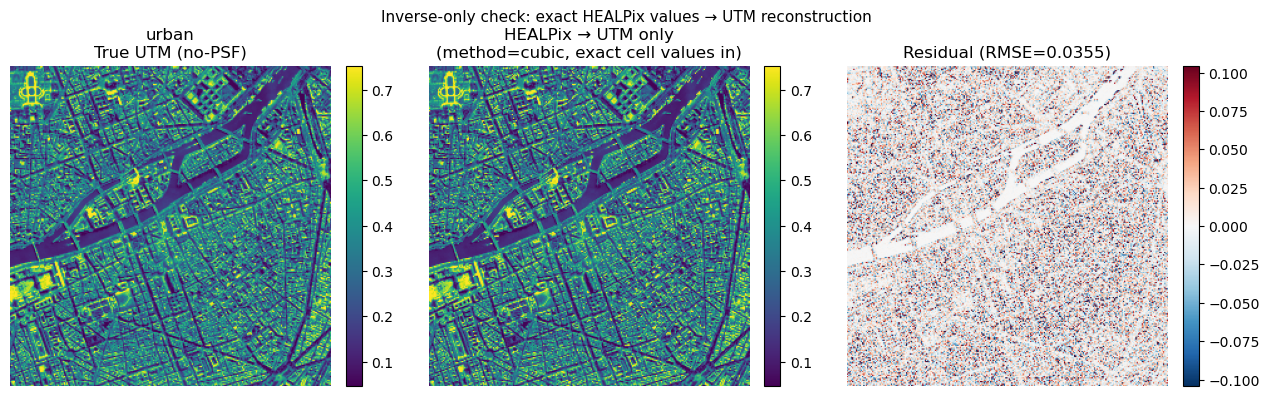

In [38]:
def plot_healpix_to_utm_only(scene_name="urban", method="cubic", force=True):
    res = run_healpix_to_utm_only(scene_name, method=method, force=force)
    truth = res["utm_truth"]
    rec   = res["reconstructed"]
    resid = res["residual"]

    vmin, vmax = np.nanpercentile(truth, [1, 99])
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))

    im0 = axes[0].imshow(truth, cmap="viridis", vmin=vmin, vmax=vmax, origin="lower")
    axes[0].set_title(f"{scene_name}\nTrue UTM (no-PSF)")
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(rec, cmap="viridis", vmin=vmin, vmax=vmax, origin="lower")
    axes[1].set_title(f"HEALPix → UTM only\n(method={method}, exact cell values in)")
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    rmax = float(np.nanpercentile(np.abs(resid), 99))
    im2 = axes[2].imshow(resid, cmap="RdBu_r", vmin=-rmax, vmax=rmax, origin="lower")
    axes[2].set_title(f"Residual (RMSE={float(res['rmse']):.4f})")
    plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    for ax in axes:
        ax.axis("off")

    fig.suptitle("Inverse-only check: exact HEALPix values → UTM reconstruction", fontsize=11)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "healpix_to_utm_only.pdf", bbox_inches="tight")
    return fig

fig_healpix_to_utm_only = plot_healpix_to_utm_only()
plt.show()


## Publish the paper assets

`tex/figures/` and `tex/tables/` are separate copies of what this notebook
writes. Publishing them here keeps the compiled paper in step with the last
run, instead of relying on a manual copy that has silently gone stale before.
Assets whose `tex/` copy is newer (hand-maintained figures) are reported and
left alone.

In [39]:
# Publish notebook outputs into tex/figures and tex/tables.
#
# Loaded by file path rather than by `import`: the module lives in the same
# repository as this notebook, but a checkout that has not been synced yet
# would otherwise fail with a bare ModuleNotFoundError at the very end of a
# long run. Here a missing file says so, and says where it should be.
import importlib.util
from pathlib import Path


def _repo_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for c in (p, *p.parents):
        if (c / "healpix_resample").is_dir() and (c / "notebooks").is_dir():
            return c
    raise RuntimeError(f"healpix-resample checkout not found above {p}")


_pub = _repo_root() / "notebooks" / "publish_paper_assets.py"
if not _pub.exists():
    print(f"publish_paper_assets.py not found at {_pub}\n"
          f"Nothing was published: tex/figures and tex/tables still hold the\n"
          f"previous run's assets. Sync the repository, then re-run this cell,\n"
          f"or from the repository root:\n"
          f"    python notebooks/publish_paper_assets.py")
else:
    _spec = importlib.util.spec_from_file_location("publish_paper_assets", _pub)
    _mod = importlib.util.module_from_spec(_spec)
    _spec.loader.exec_module(_mod)
    _mod.publish()


publish_paper_assets: 13 figures cited by main.tex+supplement.tex, 23 declared table CSVs
  updated        : 9
      figures/scene_types.pdf
      figures/synthetic_vs_sentinel2.pdf
      figures/resample-test.pdf
      figures/all-spectra.pdf
      tables/table_I_synthetic.csv
      tables/table_II_roundtrip.csv
      tables/table_ablation_rl_fair.csv
      tables/estimand_point_vs_average.csv
      tables/holdout_validation.csv
  up-to-date     : 26
  missing-source : 1
      figures/fig01_psf_healpix_workflow.pdf

  NOTE: a missing source means the paper cites an asset no notebook has produced yet (or it lives elsewhere). Re-run the notebook that writes it, then call publish() again.

  tex/ was out of date and has been refreshed -- recompile the paper.
